In [ ]:
# Mounting to google drive. Forced remount allows you to access newly uploaded/updated files and
# folders in the googe drive. If files are stored locally or elsewhere, can comment out
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

!pip install dionysus==2.0.10
import dionysus as d

import networkx as nx # Network structures
import numpy as np # Numpy arrays and operations
import random # Random sampling for network models
from itertools import combinations, product # For getting different simplices and all combinations of lists

import matplotlib.pyplot as plt # Plotting
import time # Timing simulations
from tqdm.notebook import trange, tqdm # Allows for real-time progress bar of simulations

import gc # Memory management
import pickle # Takes environment variables and saves them as is
import gzip # Allows for compression of saved files
from joblib import Parallel, delayed # Parallelization functions
import multiprocessing # Get number of cpu cores
import os
import sys

import collections
import matplotlib as mpl
import seaborn as sns
import matplotlib.colors as mcolors

Mounted at /content/drive


In [ ]:
# ── parameters ────────────────────────────────────────────────────────────────

N            = 5000
M            = 10000
K_vals       = [3, 4]
rho          = 0.4
alphas       = np.linspace(0, 1, 21)
gammas       = np.linspace(0, 1, 21)
voting_rules = ['Majority', 'Proportional']
iterations   = [1, 2, 3, 4, 5]
EXIT         = 100_000_000

data_base = '/content/drive/Othercomputers/My Computer (1)/ER/'
save_base = '/content/drive/Othercomputers/My Computer (1)/ER/'

# ── filename helper ───────────────────────────────────────────────────────────

def make_filename(n, m, k, rho, alpha, gamma, voting, iteration):
    return (
        data_base +
        f'H_rewire_triangle_same_ER_{n}_{m}_{k}_'
        f'{str(rho).replace(".","_")}_'
        f'{str(alpha).replace(".","_")}_'
        f'{str(gamma).replace(".","_")}_'
        f'{voting}_{iteration}.pkl'
    )

# ── load one file ─────────────────────────────────────────────────────────────

def load_one(n, m, k, rho, alpha, gamma, voting, iteration):
    fname = make_filename(n, m, k, rho, alpha, gamma, voting, iteration)
    if not os.path.isfile(fname):
        return (k, voting, alpha, gamma, iteration), None, None
    try:
        with gzip.open(fname, 'rb') as f:
            proportion, _, timer, _ = pickle.load(f)
        term_prop  = float(proportion)
        term_timer = int(timer)
        return (k, voting, alpha, gamma, iteration), min(1-term_prop,term_prop), term_timer
    except Exception as e:
        print(f'  Error {fname}: {e}')
        return (k, voting, alpha, gamma, iteration), None, None

# ── parallel load ─────────────────────────────────────────────────────────────

all_params = list(product(K_vals, voting_rules,
                          range(len(alphas)), range(len(gammas)), iterations))

def _load_wrapper(args):
    k, v, ai, gi, it = args
    _, prop, timer = load_one(N, M, k, rho, alphas[ai], gammas[gi], v, it)
    return (k, v, ai, gi, it), prop, timer

print('Loading data...')
raw_results = Parallel(n_jobs=-1, backend='loky')(
    delayed(_load_wrapper)(p)
    for p in tqdm(all_params, desc='Loading')
)

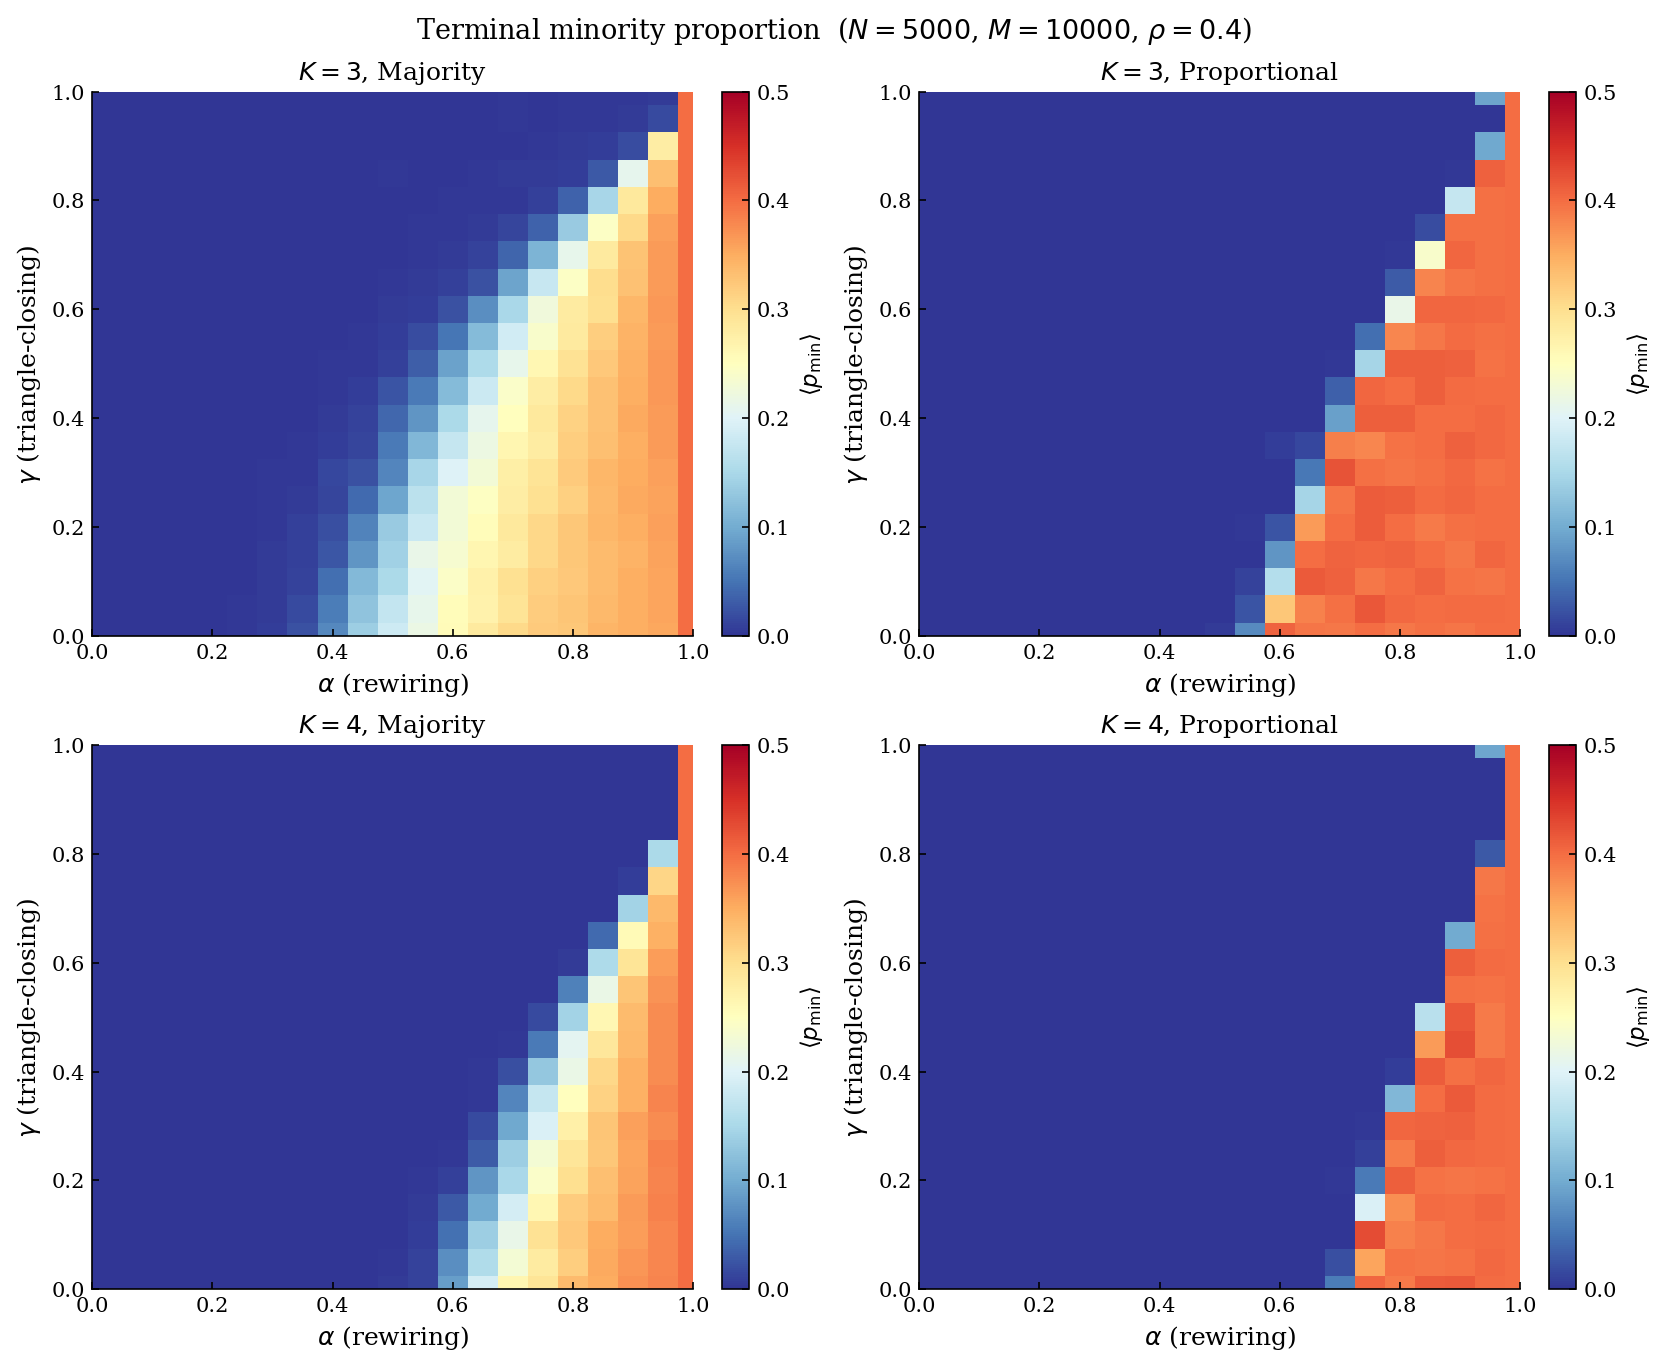

Saved: fig_HG_RTSame_proportion


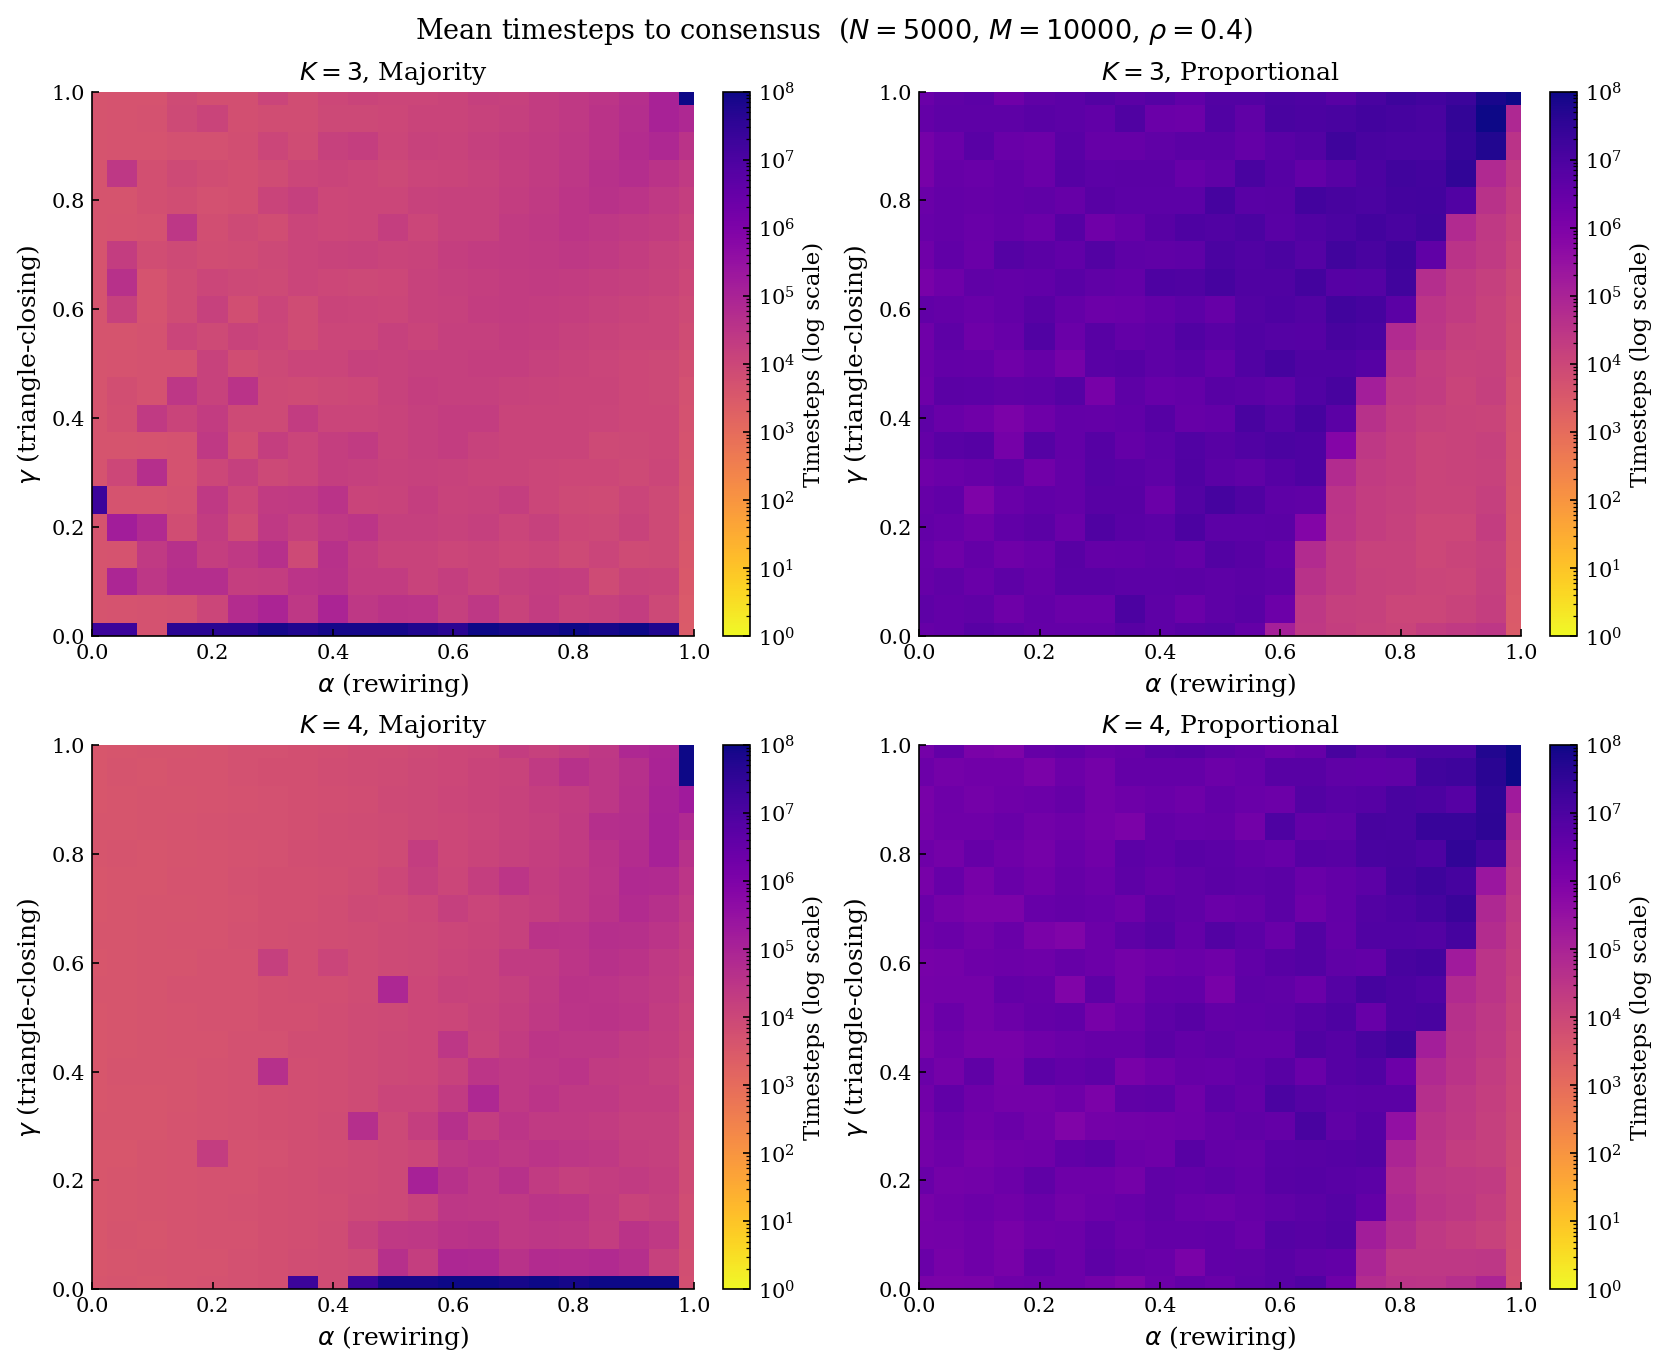

Saved: fig_HG_RTSame_timer


In [ ]:
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         13,
    'axes.labelsize':    14,
    'axes.titlesize':    14,
    'legend.fontsize':   13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
    'axes.grid':         True,
    'grid.linewidth':    0.4
})

# ── assemble into mean arrays: prop_data[k][voting] → (n_gamma, n_alpha) ─────

na, ng = len(alphas), len(gammas)

prop_sum   = {k: {v: np.zeros((ng, na)) for v in voting_rules} for k in K_vals}
timer_sum  = {k: {v: np.zeros((ng, na)) for v in voting_rules} for k in K_vals}
count      = {k: {v: np.zeros((ng, na)) for v in voting_rules} for k in K_vals}
no_consens = {k: {v: np.zeros((ng, na)) for v in voting_rules} for k in K_vals}

for (k, v, ai, gi, it), prop, timer in raw_results:
    if prop is None:
        continue
    prop_sum[k][v][gi, ai]  += prop
    timer_sum[k][v][gi, ai] += timer
    count[k][v][gi, ai]     += 1
    if timer >= EXIT:
        no_consens[k][v][gi, ai] += 1

def safe_mean(s, c):
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(c > 0, s / c, np.nan)

prop_mean  = {k: {v: safe_mean(prop_sum[k][v],  count[k][v]) for v in voting_rules}
              for k in K_vals}
timer_mean = {k: {v: safe_mean(timer_sum[k][v], count[k][v]) for v in voting_rules}
              for k in K_vals}
frac_nc    = {k: {v: safe_mean(no_consens[k][v], count[k][v]) for v in voting_rules}
              for k in K_vals}

# ── heatmap helper ────────────────────────────────────────────────────────────

def heatmap(ax, mat, alphas, gammas, cmap, vmin, vmax, title, cbar_label,
            norm=None):
    im = ax.pcolormesh(
        alphas, gammas, mat,
        cmap=cmap, shading='auto',
        norm=norm if norm is not None else mcolors.Normalize(vmin=vmin, vmax=vmax),
    )
    ax.set_xlabel(r'$\alpha$ (rewiring)')
    ax.set_ylabel(r'$\gamma$ (triangle-closing)')
    ax.set_title(title, pad=6)
    ax.set_xlim(alphas[0], alphas[-1])
    ax.set_ylim(gammas[0], gammas[-1])
    return im

# ── Figure 1: terminal minority proportion ────────────────────────────────────
# Rows: K=3 (top), K=4 (bottom)
# Cols: Majority (left), Proportional (right)

fig1, axes1 = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
fig1.suptitle(
    rf'Terminal minority proportion  ($N={N}$, $M={M}$, $\rho={rho}$)',
    fontsize=13
)

prop_vmin = 0.0
prop_vmax = 0.5

for row, k in enumerate(K_vals):
    for col, v in enumerate(voting_rules):
        ax  = axes1[row, col]
        mat = prop_mean[k][v]
        im  = heatmap(ax, mat, alphas, gammas,
                      cmap='RdYlBu_r',
                      vmin=prop_vmin, vmax=prop_vmax,
                      title=rf'$K={k}$, {v}',
                      cbar_label=r'$\langle p_{\min} \rangle$')
        cbar = fig1.colorbar(im, ax=ax, pad=0.02)
        cbar.set_label(r'$\langle p_{\min} \rangle$', fontsize=11)

fig1.savefig(save_base + 'fig_HG_RTSame_proportion.pdf',
             dpi=300, bbox_inches='tight')
fig1.savefig(save_base + 'fig_HG_RTSame_proportion.png',
             dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_HG_RTSame_proportion')

# ── Figure 2: timer (timesteps to consensus) ──────────────────────────────────
# Use log scale; cells where all runs hit EXIT are hatched

fig2, axes2 = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
fig2.suptitle(
    rf'Mean timesteps to consensus  ($N={N}$, $M={M}$, $\rho={rho}$)',
    fontsize=13
)

log_norm = mcolors.LogNorm(vmin=1, vmax=EXIT)

for row, k in enumerate(K_vals):
    for col, v in enumerate(voting_rules):
        ax   = axes2[row, col]
        mat  = timer_mean[k][v].copy()
        fnc  = frac_nc[k][v]

        im = heatmap(ax, mat, alphas, gammas,
                     cmap='plasma_r',
                     vmin=None, vmax=None,
                     norm=log_norm,
                     title=rf'$K={k}$, {v}',
                     cbar_label='Timesteps')

        # hatch cells where ≥ 50 % of runs did not reach consensus
        nc_mask = np.ma.masked_where(fnc < 0.5, np.ones_like(fnc))
        ax.pcolor(alphas, gammas, nc_mask,
                  hatch='////', alpha=0.0, edgecolor='white', linewidth=0.3)

        cbar = fig2.colorbar(im, ax=ax, pad=0.02)
        cbar.set_label('Timesteps (log scale)', fontsize=11)

fig2.savefig(save_base + 'fig_HG_RTSame_timer.pdf',
             dpi=300, bbox_inches='tight')
fig2.savefig(save_base + 'fig_HG_RTSame_timer.png',
             dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_HG_RTSame_timer')

In [ ]:
# ── parameters ────────────────────────────────────────────────────────────────

N_nodes      = 5000
M            = 10000
K_vals       = [3, 4]
rho          = 0.4
alphas       = np.linspace(0, 1, 21)
gammas       = np.linspace(0, 1, 21)
voting_rules = ['Majority', 'Proportional']
iterations   = [1, 2, 3, 4, 5]
MAX_DIM      = 3    # max simplex dimension → max simplex size = 4

data_base = '/content/drive/Othercomputers/My Computer (1)/ER/'
proc_base = '/content/drive/Othercomputers/My Computer (1)/ER/Processed/'
save_base = '/content/drive/Othercomputers/My Computer (1)/ER/'
os.makedirs(proc_base, exist_ok=True)
os.makedirs(save_base,  exist_ok=True)

# ── filename helpers ──────────────────────────────────────────────────────────

def raw_filename(k, alpha, gamma, voting, iteration):
    return (
        data_base +
        f'H_rewire_triangle_same_ER_{N_nodes}_{M}_{k}_'
        f'{str(rho).replace(".","_")}_'
        f'{str(alpha).replace(".","_")}_'
        f'{str(gamma).replace(".","_")}_'
        f'{voting}_{iteration}.pkl'
    )

def proc_filename(k, alpha, gamma, voting, iteration):
    return (
        proc_base +
        f'TDA_ER_{N_nodes}_{M}_{k}_'
        f'{str(rho).replace(".","_")}_'
        f'{str(alpha).replace(".","_")}_'
        f'{str(gamma).replace(".","_")}_'
        f'{voting}_{iteration}.pkl'
    )

# ── TDA computation ───────────────────────────────────────────────────────────

def downward_closure(H, max_dim):
    """
    Build all simplices in the downward closure of H up to dimension max_dim.
    Returns list of sets, one per dimension 0..max_dim.
    Each element is a set of tuples (sorted vertex lists).
    """
    simplices = [set() for _ in range(max_dim + 1)]
    for nodes in H.values():
        nodes = sorted(nodes)
        # include subsets of size 1..(max_dim+1)
        for size in range(1, min(len(nodes) + 1, max_dim + 2)):
            for subset in combinations(nodes, size):
                simplices[size - 1].add(subset)
    return simplices

def compute_tda(H, max_dim=MAX_DIM):
    """
    Build a dimension-filtered complex from H, compute PH via dionysus2.
    Filtration time = simplex dimension (0-simplices at t=0, etc.).

    Returns dict with:
        b0, b1, b2        : terminal Betti numbers
        N0, N1, N2, N3    : simplex counts per dimension
    """
    simplices = downward_closure(H, max_dim)

    # build dionysus filtration: time = dimension
    f = d.Filtration()
    for dim, sset in enumerate(simplices):
        for s in sset:
            f.append(d.Simplex(list(s), float(dim)))
    f.sort()

    # persistent homology
    m    = d.homology_persistence(f)
    dgms = d.init_diagrams(m, f)

    # terminal Betti numbers = count of infinite bars in each diagram
    inf = float('inf')
    b = [0, 0, 0]
    for dim in range(3):
        if dim < len(dgms):
            b[dim] = sum(1 for pt in dgms[dim] if pt.death == inf)

    counts = [len(s) for s in simplices]   # N0, N1, N2, N3
    while len(counts) < 4:
        counts.append(0)

    return {
        'b0': b[0], 'b1': b[1], 'b2': b[2],
        'N0': counts[0], 'N1': counts[1],
        'N2': counts[2], 'N3': counts[3],
    }

# ── process one (k, alpha, gamma, voting, iteration) ─────────────────────────

def process_one(k, ai, gi, voting, it):
    alpha = alphas[ai]; gamma = gammas[gi]
    pfname = proc_filename(k, alpha, gamma, voting, it)
    if os.path.isfile(pfname):
        return  # already processed

    rfname = raw_filename(k, alpha, gamma, voting, it)
    if not os.path.isfile(rfname):
        return

    try:
        with gzip.open(rfname, 'rb') as f:
            _, _, _, H = pickle.load(f)
        result = compute_tda(H)
        with gzip.open(pfname, 'wb') as f:
            pickle.dump(result, f)
    except Exception as e:
        print(f'  Error [{k}, a={alpha:.2f}, g={gamma:.2f}, {voting}, {it}]: {e}')

# ── parallel processing ───────────────────────────────────────────────────────

all_jobs = list(product(K_vals, range(len(alphas)), range(len(gammas)),
                        voting_rules, iterations))

from joblib import Parallel, delayed

print('Computing TDA...')
Parallel(n_jobs=-1, backend='threading')(
    delayed(process_one)(k, ai, gi, v, it)
    for k, ai, gi, v, it in tqdm(all_jobs, desc='TDA')
)
print('TDA complete.')

Computing TDA...


TDA: 100%|██████████| 8820/8820 [00:31<00:00, 278.83it/s] 

TDA complete.


In [ ]:
# =============================================================================
# LOADING AND PLOTTING
# =============================================================================

na, ng = len(alphas), len(gammas)

fields = ['b0', 'b1', 'b2', 'N0', 'N1', 'N2', 'N3']
sums   = {k: {v: {fld: np.zeros((ng, na)) for fld in fields}
              for v in voting_rules} for k in K_vals}
counts = {k: {v: np.zeros((ng, na)) for v in voting_rules} for k in K_vals}

# ── parallel load ─────────────────────────────────────────────────────────────

def load_one(k, ai, gi, v, it):
    alpha  = alphas[ai]; gamma = gammas[gi]
    pfname = proc_filename(k, alpha, gamma, v, it)
    if not os.path.isfile(pfname):
        return None
    try:
        with gzip.open(pfname, 'rb') as f:
            res = pickle.load(f)
        return (k, ai, gi, v, res)
    except Exception:
        return None

print('Loading processed TDA...')
results = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_one)(k, ai, gi, v, it)
    for k, ai, gi, v, it in tqdm(all_jobs, desc='Submitting')
)

# ── serial accumulation (fast, no contention) ─────────────────────────────────
for out in tqdm(results, desc='Accumulating'):
    if out is None:
        continue
    k, ai, gi, v, res = out
    for fld in fields:
        sums[k][v][fld][gi, ai] += res[fld]
    counts[k][v][gi, ai] += 1

# ── compute means and derived quantities ──────────────────────────────────────

def smean(k, v, fld):
    c = counts[k][v]
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(c > 0, sums[k][v][fld] / c, np.nan)

means = {k: {v: {fld: smean(k, v, fld) for fld in fields}
             for v in voting_rules} for k in K_vals}

# derived quantities
derived = {}
for k in K_vals:
    derived[k] = {}
    for v in voting_rules:
        m = means[k][v]
        b0, b1, b2 = m['b0'], m['b1'], m['b2']
        N0, N1, N2, N3 = m['N0'], m['N1'], m['N2'], m['N3']

        with np.errstate(invalid='ignore', divide='ignore'):
            tb0   = np.where(N0 > 0, b0 / N0, np.nan)
            tb1   = np.where(N1 > 0, b1 / N1, np.nan)
            tb2   = np.where(N2 > 0, b2 / N2, np.nan)
            CR1   = N1 - N0 + b0
            CR1b1 = CR1 - b1
            g1    = np.where(N2 > 0, CR1b1 / N2, np.nan)
            CR2   = N2 - CR1 + b1
            CR2b2 = CR2 - b2
            g2    = np.where(N3 > 0, CR2b2 / N3, np.nan)

        derived[k][v] = {
            r'$\beta_0$ (connected components)':                             b0,
            #r'$\tilde{\beta}_0$':                     tb0,
            r'$\beta_1$ (tunnels)':                             b1,
            #r'$\tilde{\beta}_1$':                     tb1,
            r'$\beta_2$ (voids)':                             b2,
            #r'$\tilde{\beta}_2$':                     tb2,
            r'$N_1$ (inferred edges)':                                 N1,
            r'$N_2$ (triangles)':                                 N2,
            r'$N_3$ (tetrahedra)':                                 N3,
            #r'$\mathcal{CR}_1 - \beta_1$':            CR1b1,
            #r'$\gamma_1$':                            g1,
            #r'$\mathcal{CR}_2 - \beta_2$':            CR2b2,
            #r'$\gamma_2$':                            g2,
        }

Loading processed TDA...


Accumulating: 100%|██████████| 8820/8820 [00:00<00:00, 220829.27it/s]


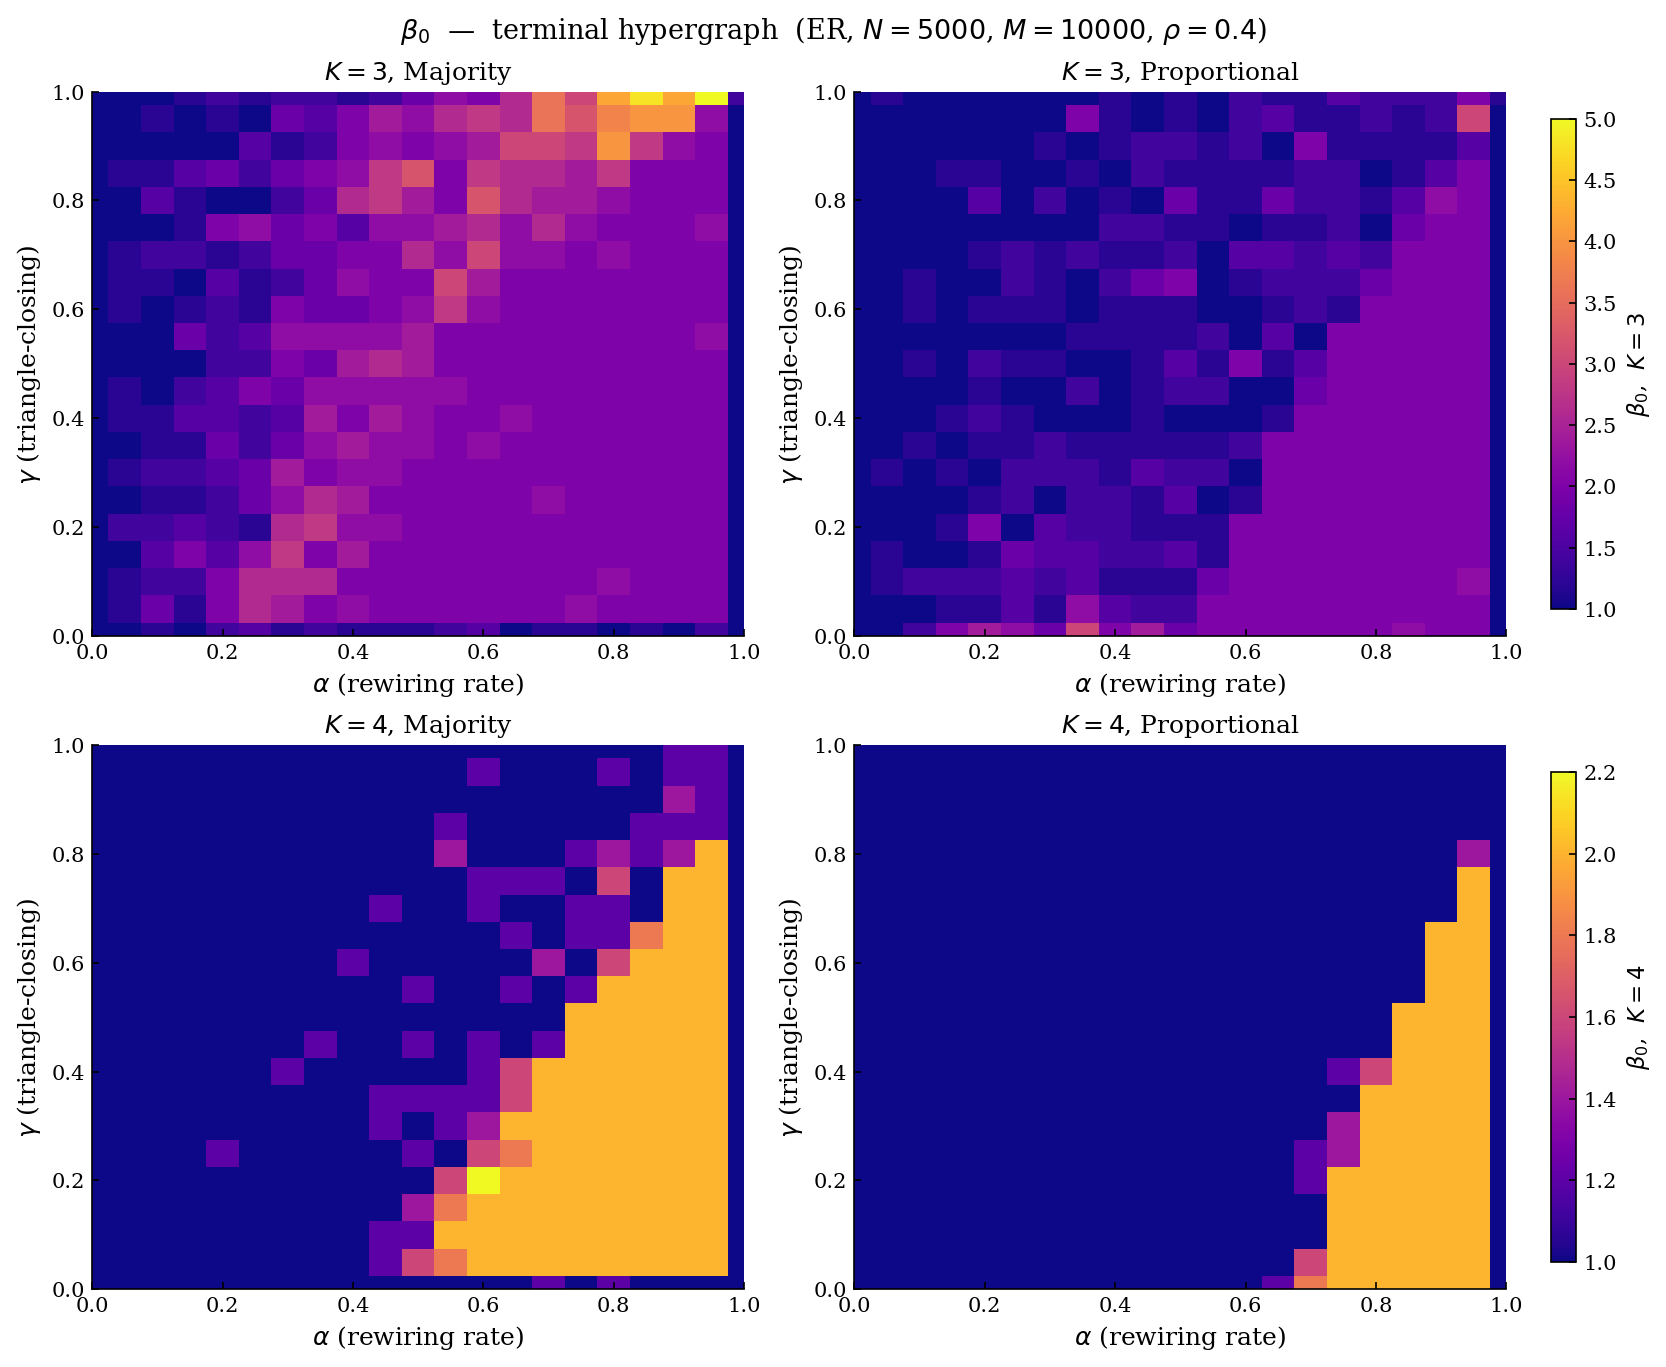

Saved: beta_0


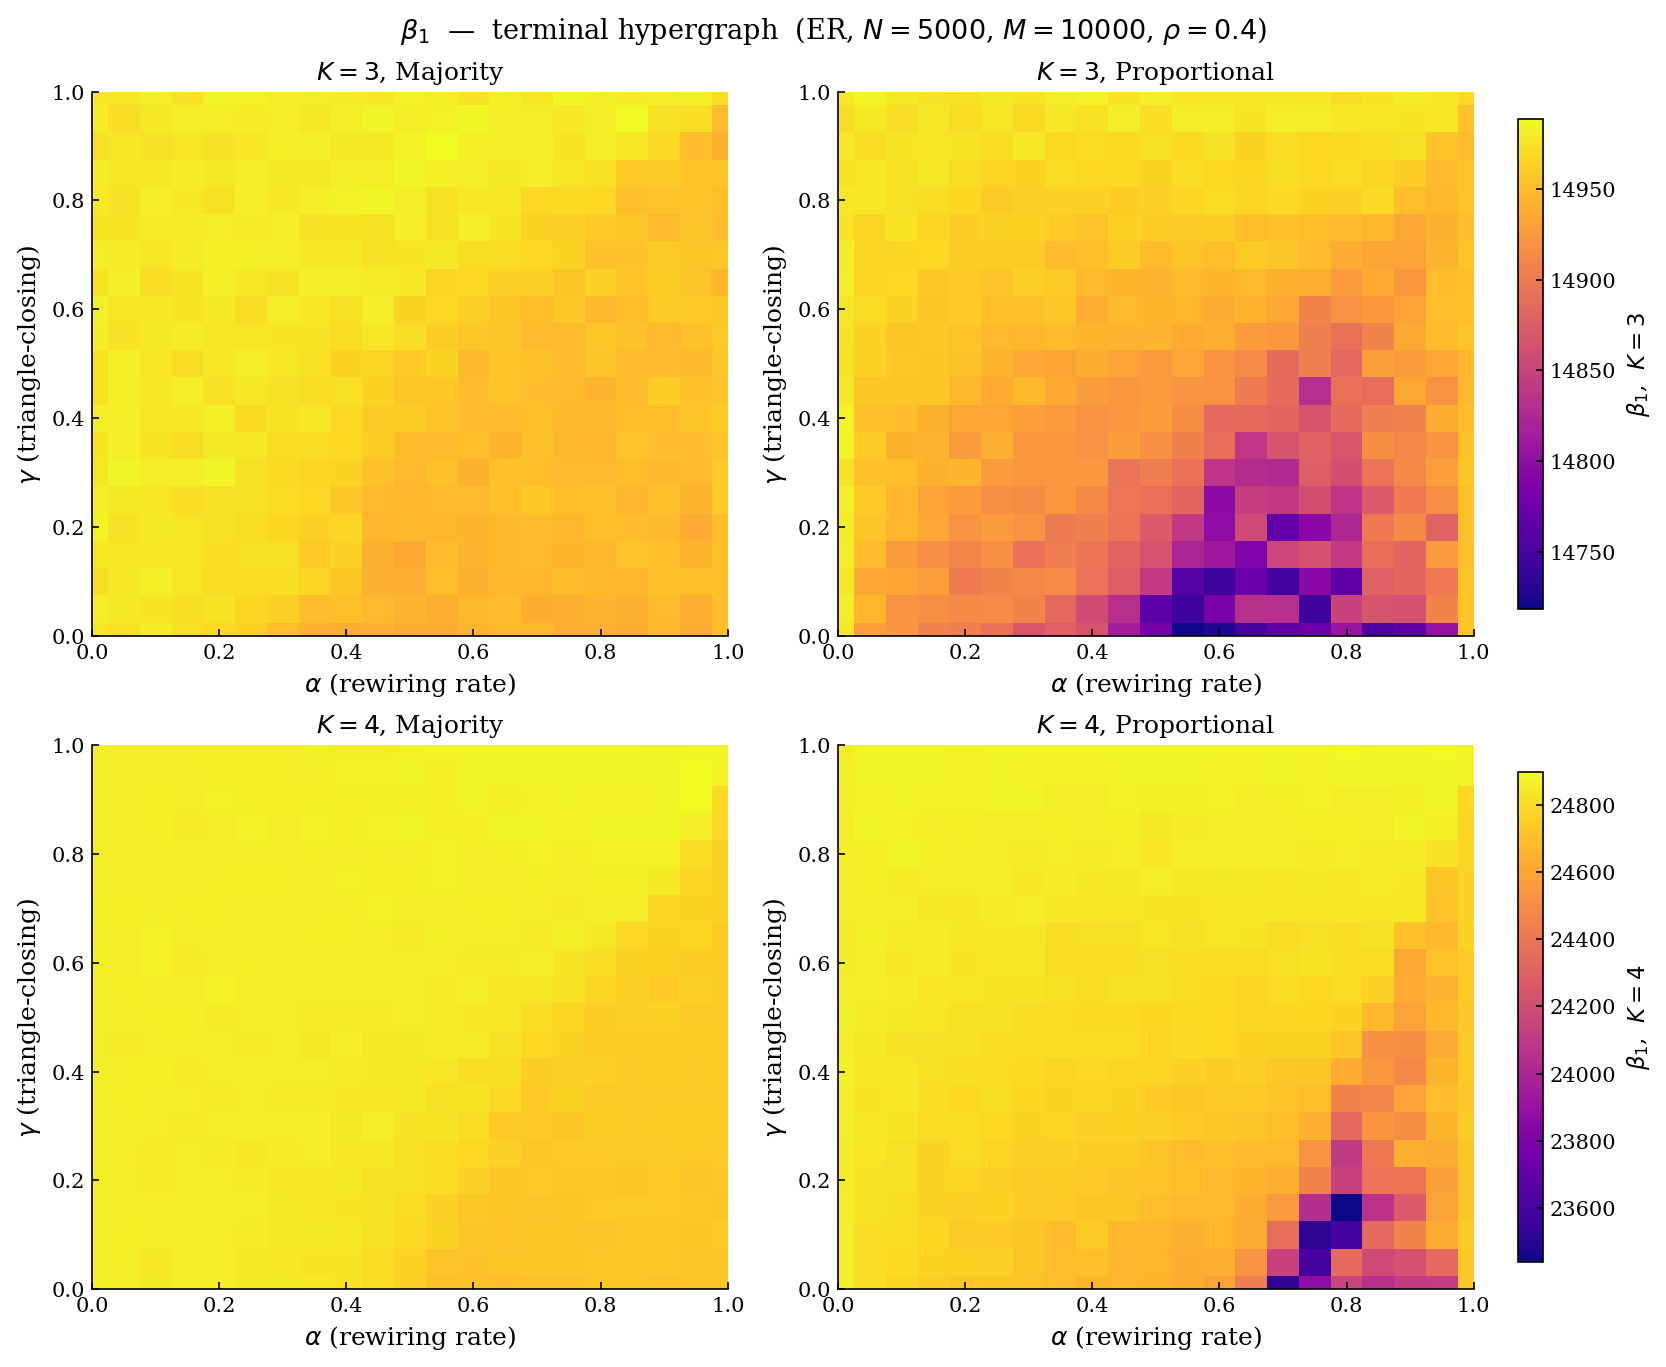

Saved: beta_1


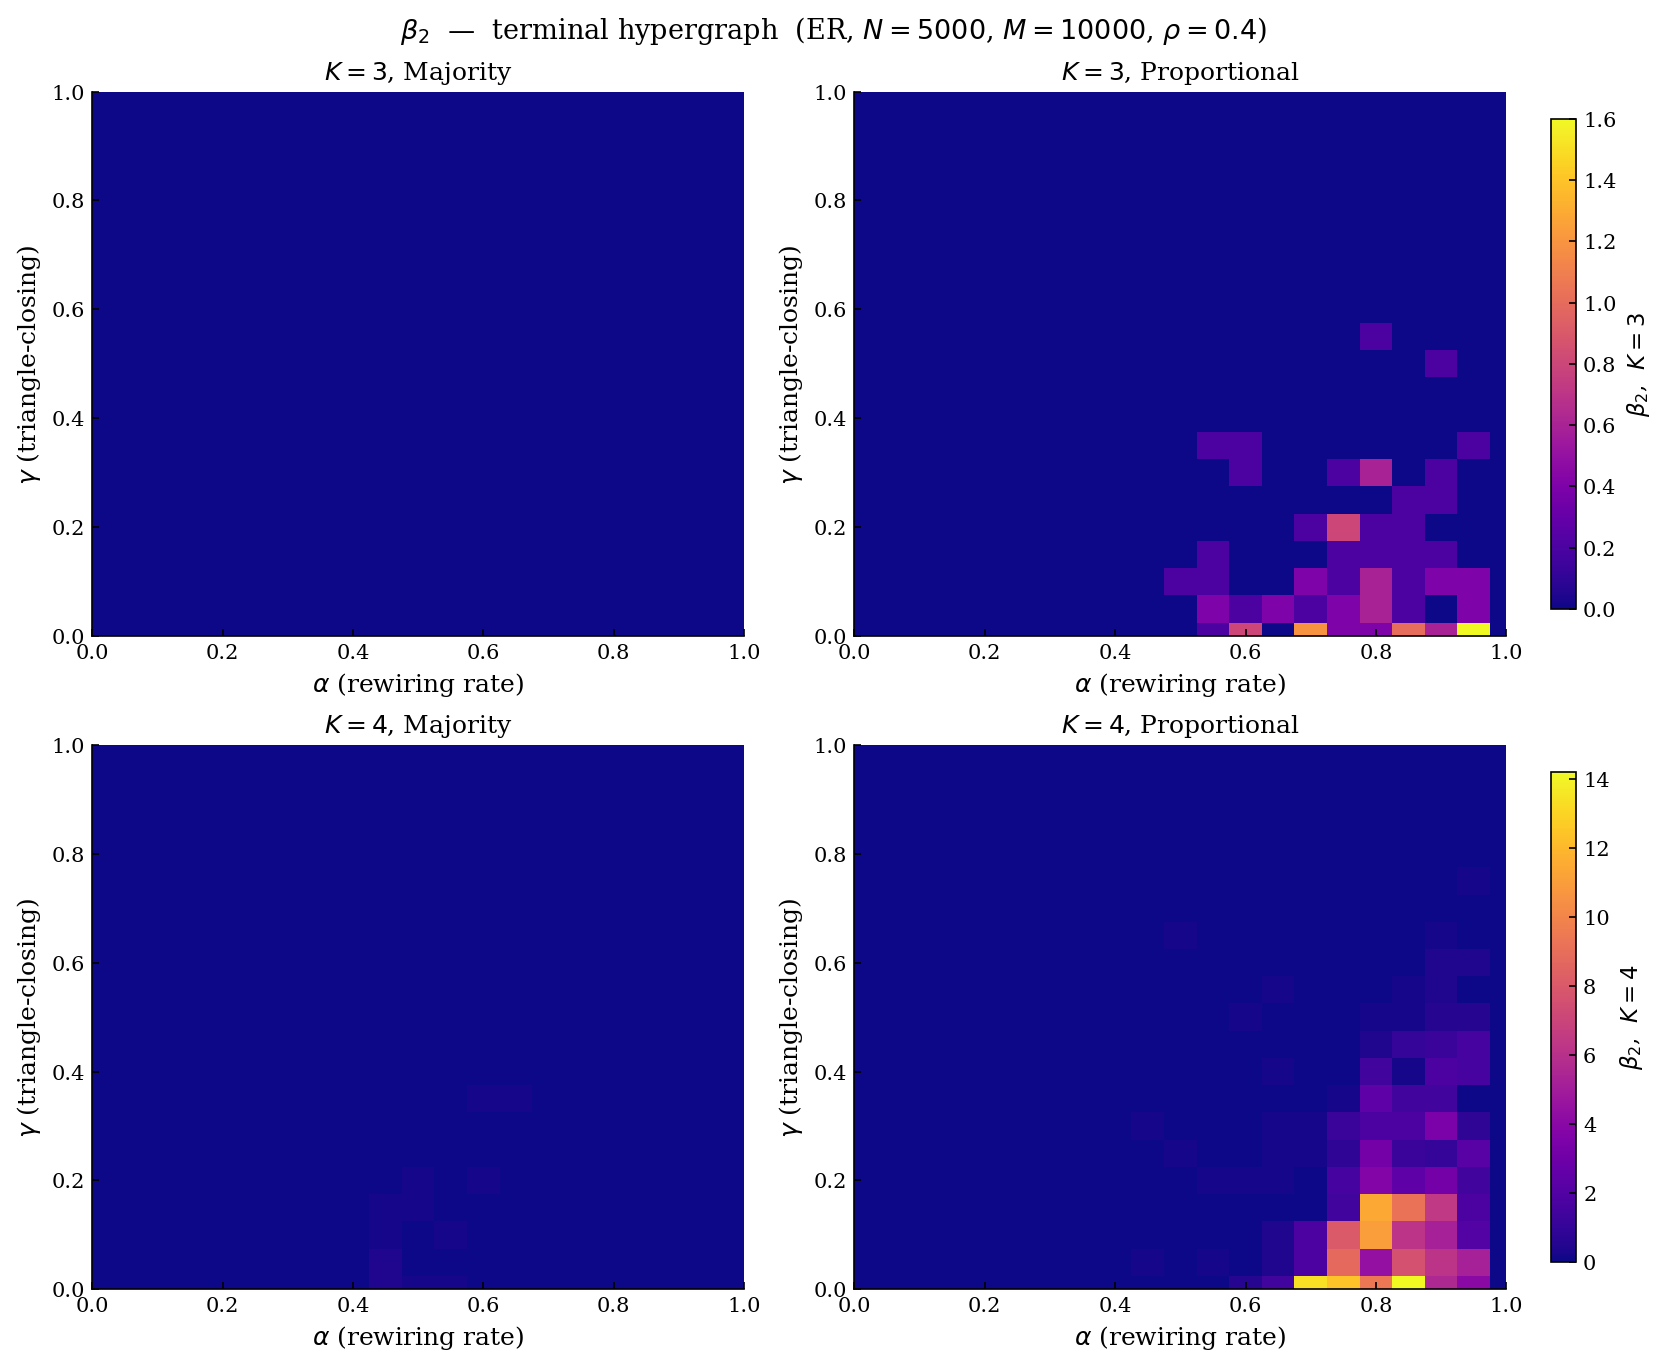

Saved: beta_2


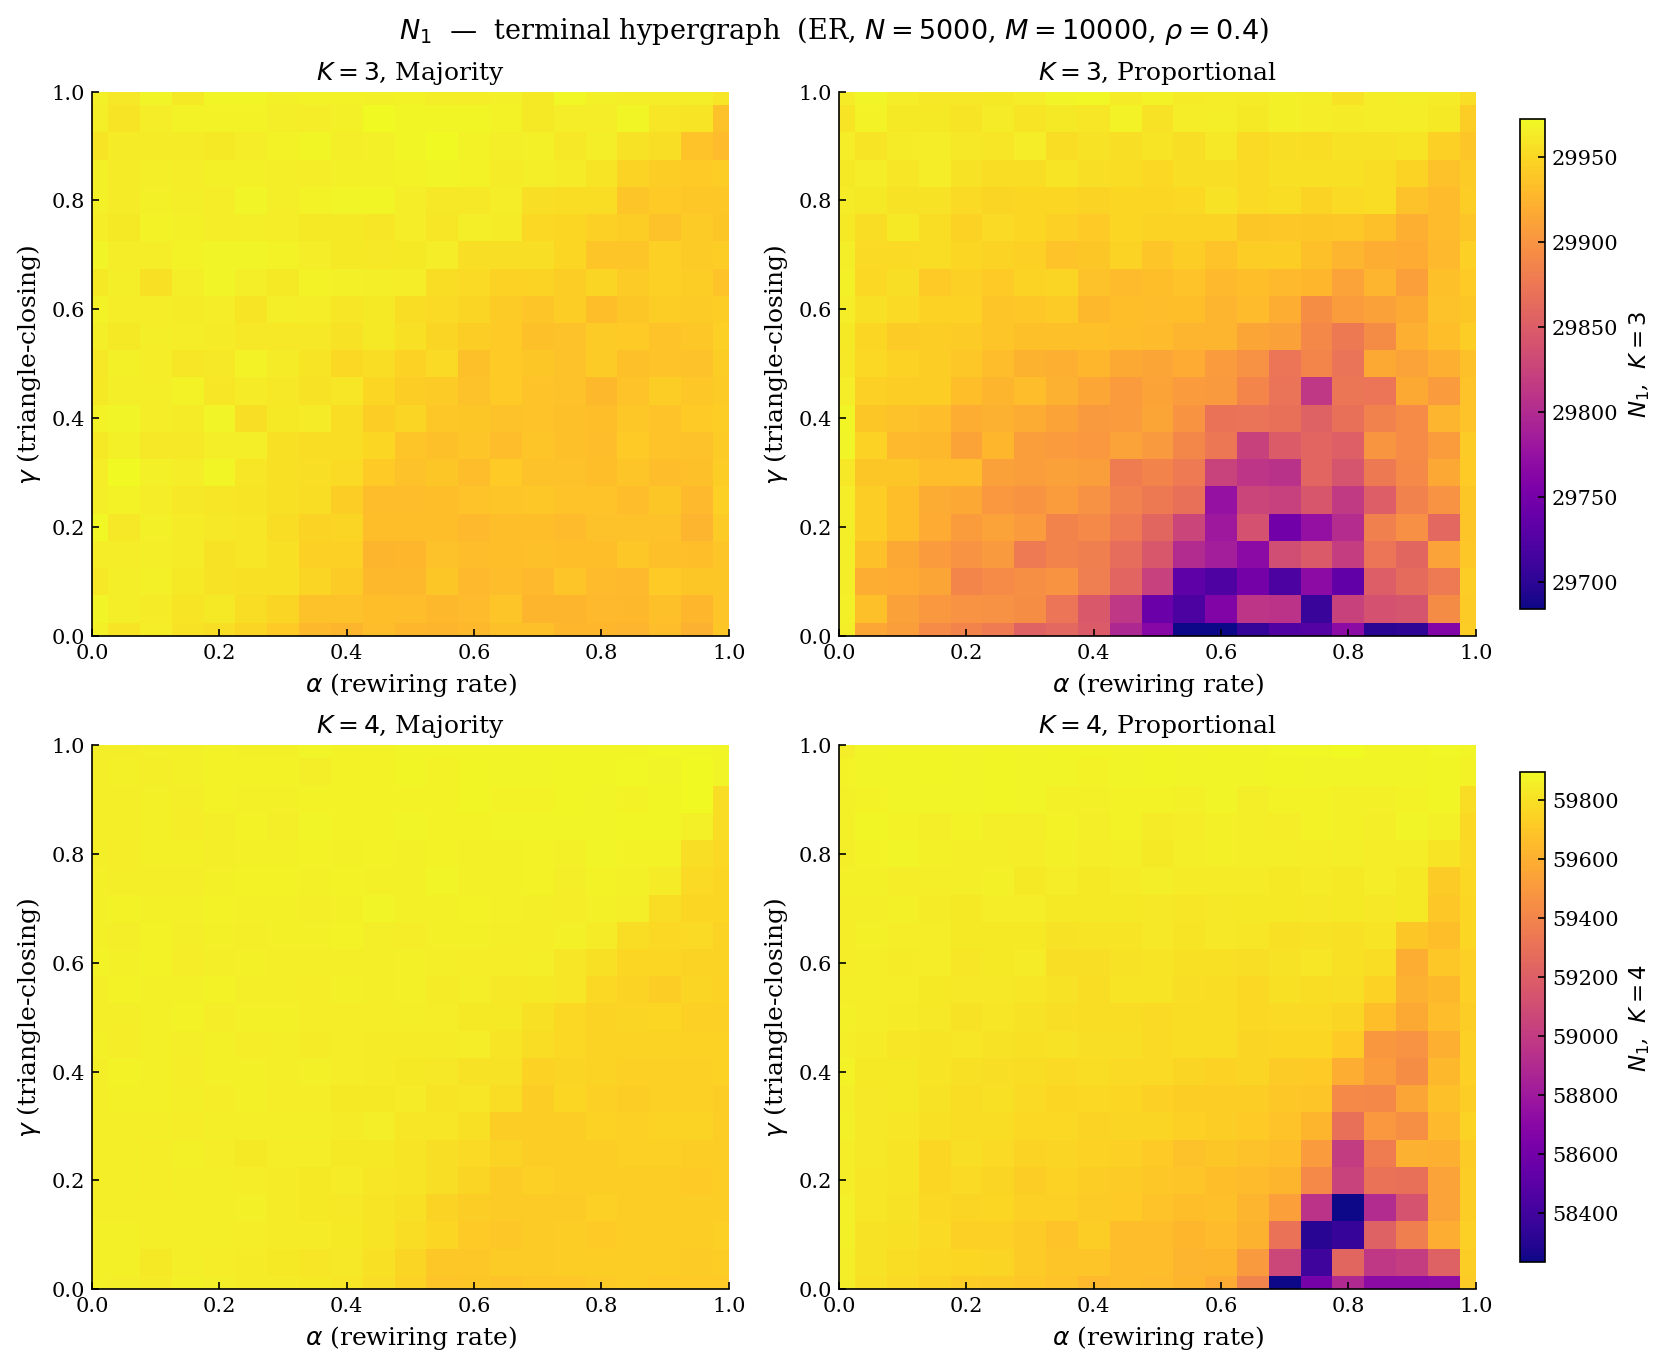

Saved: N_1


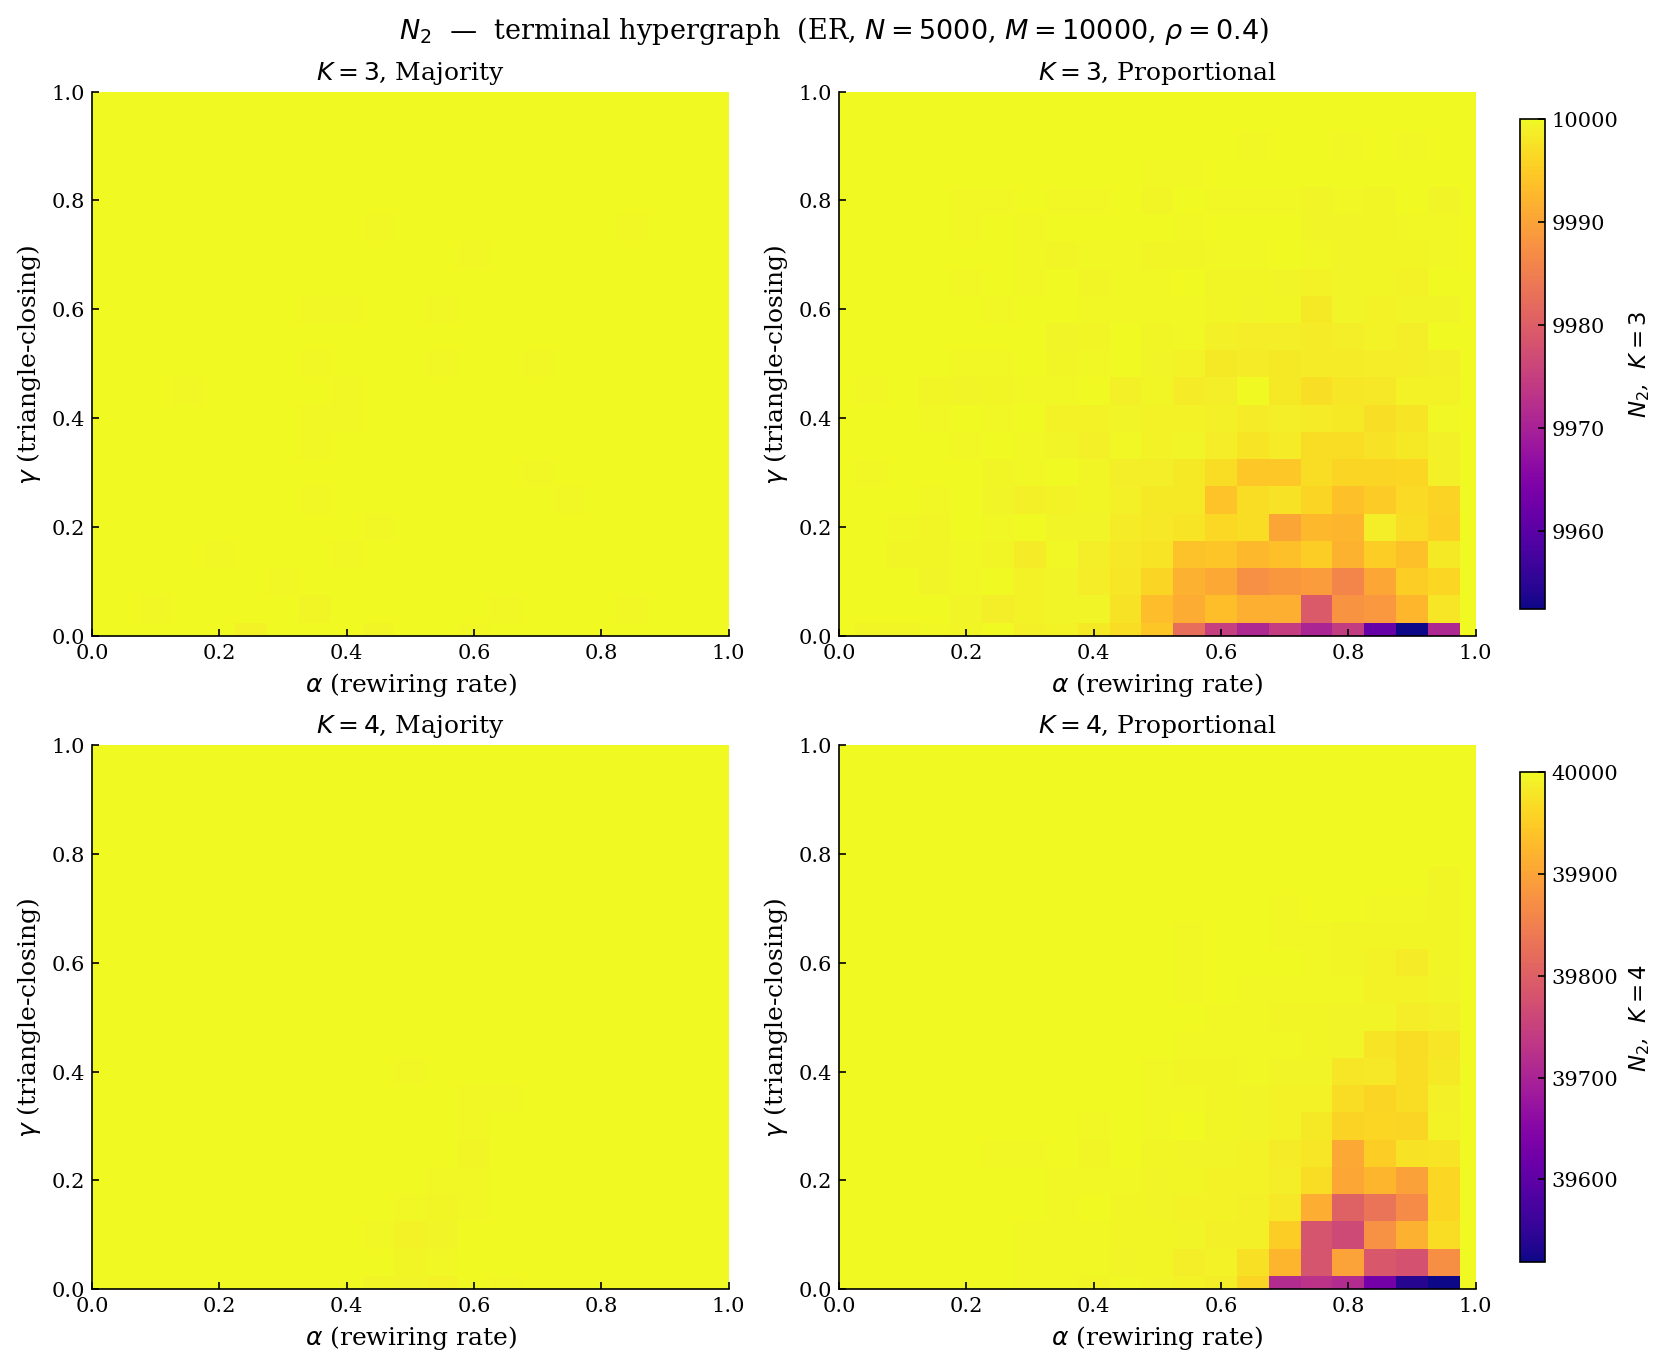

Saved: N_2


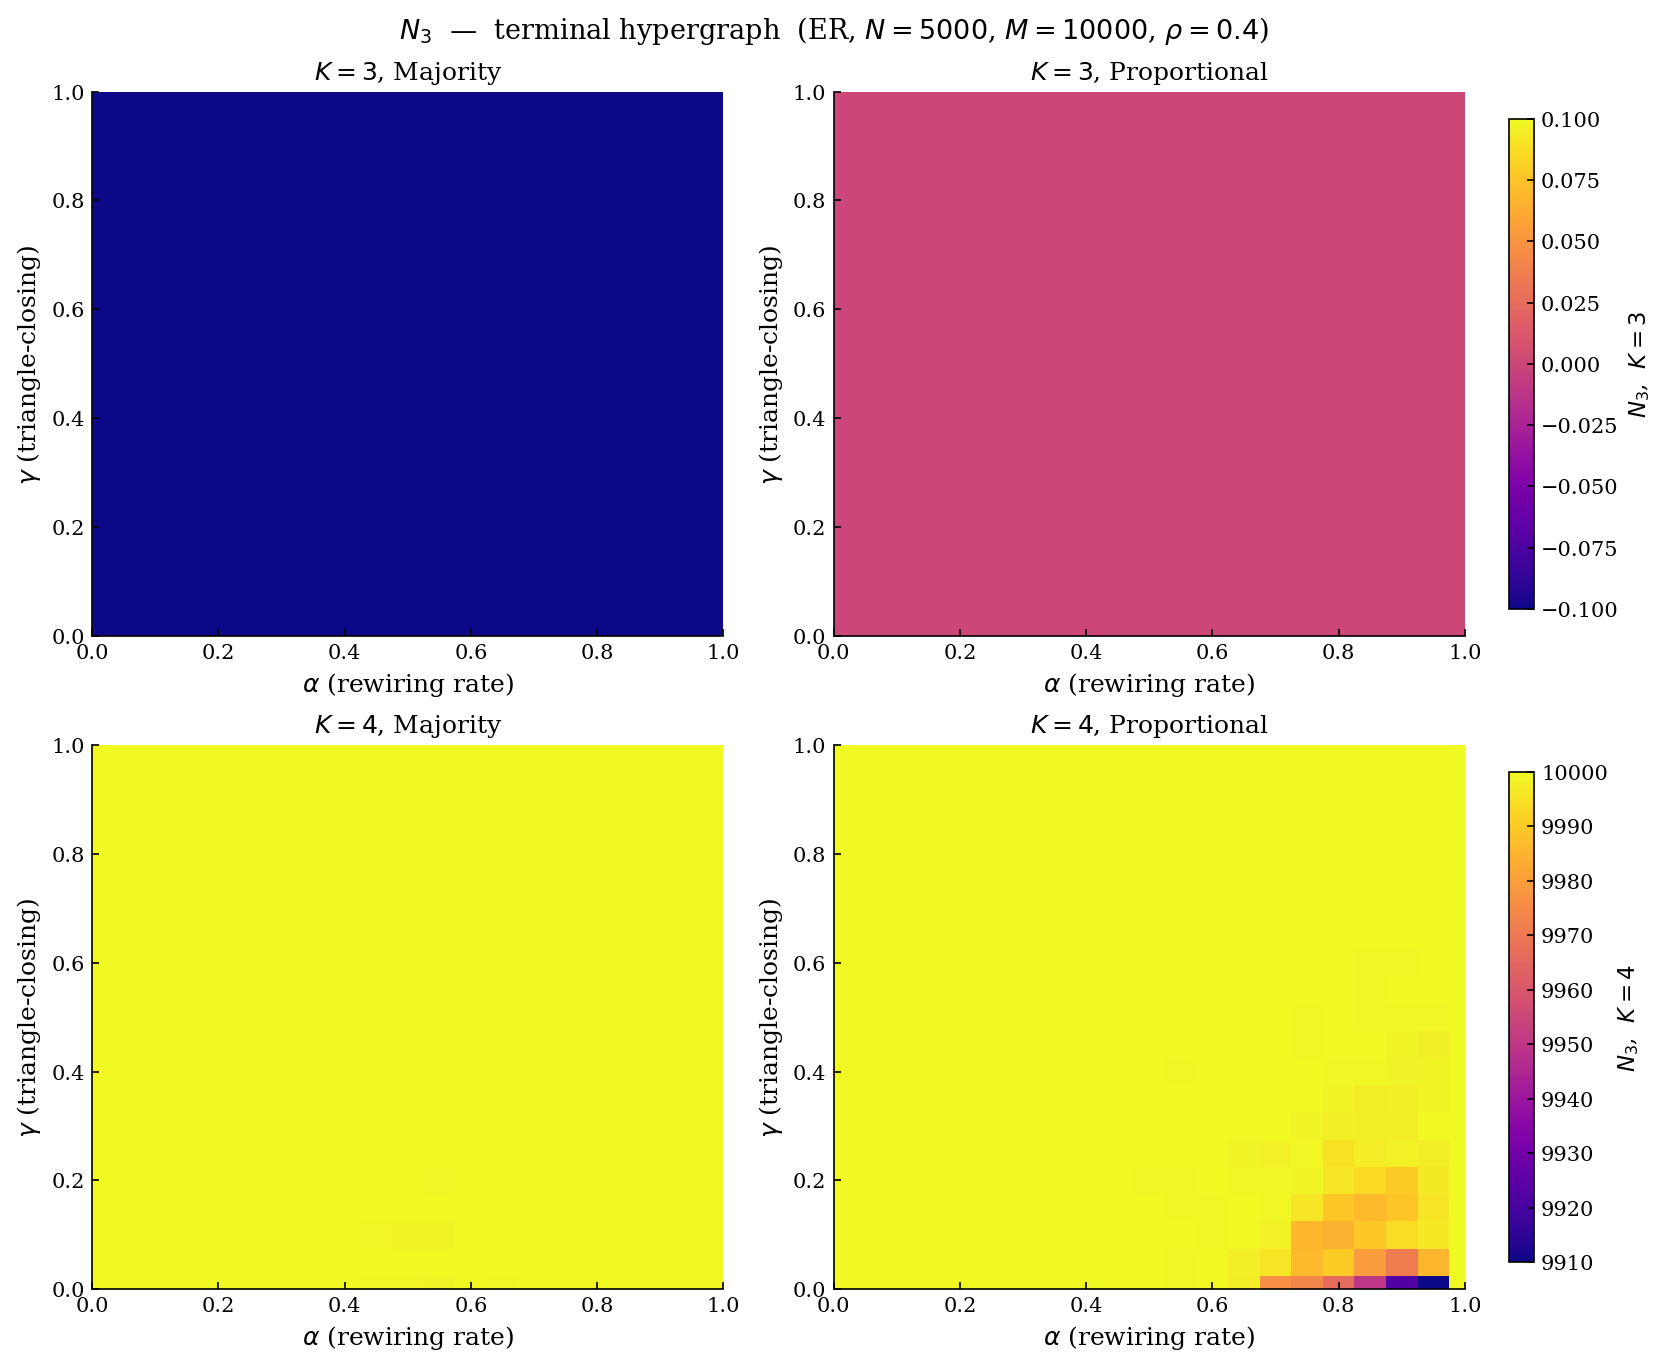

Saved: N_3


In [ ]:
# ── heatmap helper ────────────────────────────────────────────────────────────

def make_heatmap(ax, mat, title, cmap='plasma', vmin=None, vmax=None):
    finite = mat[np.isfinite(mat)]
    vmin   = finite.min() if vmin is None and len(finite) > 0 else vmin
    vmax   = finite.max() if vmax is None and len(finite) > 0 else vmax
    im = ax.pcolormesh(
        alphas, gammas, mat,
        cmap=cmap, shading='auto',
        norm=mcolors.Normalize(vmin=vmin, vmax=vmax),
    )
    ax.set_xlabel(r'$\alpha$ (rewiring rate)')
    ax.set_ylabel(r'$\gamma$ (triangle-closing)')
    ax.set_title(title, pad=6)
    ax.set_xlim(alphas[0], alphas[-1])
    ax.set_ylim(gammas[0], gammas[-1])
    return im

# ── generate one 2×2 figure per quantity ─────────────────────────────────────

quantity_keys = list(next(iter(next(iter(derived.values())).values())).keys())

for label in quantity_keys:
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)

    for row, k in enumerate(K_vals):
        # colour scale shared within this K row only
        k_vals_finite = np.concatenate([
            derived[k][v][label][np.isfinite(derived[k][v][label])].ravel()
            for v in voting_rules
        ])
        vmin = k_vals_finite.min() if len(k_vals_finite) > 0 else 0
        vmax = k_vals_finite.max() if len(k_vals_finite) > 0 else 1

        for col, v in enumerate(voting_rules):
            ax  = axes[row, col]
            mat = derived[k][v][label]
            im  = make_heatmap(ax, mat,
                               title=rf'$K={k}$, {v} Voting',
                               vmin=vmin, vmax=vmax)

        # one colourbar per row, anchored to the right panel of that row
        cbar = fig.colorbar(im, ax=axes[row, :], pad=0.02, shrink=0.9)
        cbar.set_label(rf'{label},  $K={k}$', fontsize=11)

    safe = label.replace('$','').replace('\\','').replace('{','').replace('}','').replace(' ','_')
    fig.suptitle(
        rf'{label}  —  terminal hypergraph  (ER, $N={N_nodes}$, $M={M}$, $\rho={rho}$)',
        fontsize=13,
    )
    fig.savefig(save_base + f'fig_TDA_{safe}.pdf', dpi=300, bbox_inches='tight')
    fig.savefig(save_base + f'fig_TDA_{safe}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {safe}')

In [ ]:
sys.path.append('/content/drive/MyDrive/Colab Notebooks')
!pip install dionysus==2.0.10
from GenerativeHypergraphModels import *

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 59.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for dionysus: filename=dionysus-2.0.10-cp312-cp312-linux_x86_64.whl size=437481 sha256=affccf18b09f3bc4ff0d3db62d779be74d64ea6e47ccef639a4bb45e747554c9
  Stored in directory: /root/.cache/pip/wheels/11/9f/ca/ae26580795e766a8b6dce75ae4f29163b83b52d7a72efd5d48
Successfully built dionysus


## Graph rewire-to-random model with node-swapping

In [ ]:
def G_RewireToRandomVoter_fast(G, rho, alpha, exit_criteria = np.inf, timing = False):
    """
    Input a networkx object G, initial opinion 0 density rho, and
    rewiring probability alpha. Simulate the adaptive network voter
    model on the input graph, where at each step a discordant edge
    is selected uniformly. Then, with probability alpha the edge is rewired
    at random, and with probability 1-alpha one node adopts the opinion
    of its neighbor. Returns the proportions of opinions at each time step and
    the terminal graph G.
    """

    if timing == True:
        print("Initializing graph, variables and data structures",flush=True)
        start = time.time()

    numNodes = len(G.nodes())
    # Set |V|*rho many nodes to opinion 1 and the rest to opinion 0
    Opinions = set(np.random.choice(list(G.nodes()), size=round(rho*numNodes), replace=False))
    Opinions = {v: 1 if v in Opinions else 0 for v in G.nodes()}

    # E will be list of edges and we will keep track of indices of edges in E
    E = list(G.edges())
    N = {v:set() for v in G.nodes()}
    for i, e in enumerate(E):
        for v in e:
            N[v].add(i)
    # Generate list of all edges where the connected nodes have differing (discordant) opinions
    DiscordantEdges = [i for i, edge in enumerate(E) if Opinions[edge[0]] != Opinions[edge[1]]]
    DiscordantIndex = {edge_id: pos for pos, edge_id in enumerate(DiscordantEdges)}

    # Initialize list of opinion proportions
    Proportions = [sum(Opinions.values())/numNodes]
    DiscordantCounts = [len(DiscordantEdges) / len(E)]
    timer = 0

    if timing == True:
        end = time.time()
        print("Initialization complete, time taken : "+str(end - start)+" seconds",flush=True)
        print("(Beginning network evolution)",flush=True)
        start = time.time()

    # Main loop of the model. At each step select a discordant edge at random
    # With probability alpha, the (randomly selected) source node is rewired from the target node to a random
    # node with the same opinion as the source node, and is not already connected to the source node
    # Otherwise (with probability 1 - alpha) the source node adopts the opinion of the target node

    while len(DiscordantEdges) > 0 and timer < exit_criteria:
        # Timing print
        if timing and timer % 10000 == 0:
            print("Timer : "+str(timer),flush=True)
        # Proportions from previous time step, and update timer
        timer += 1; Proportions.append(Proportions[-1])

        # Uniformly sample an element from DiscordantEdges, giving the index of a discordant edge in E
        edgeChoice = np.random.randint(len(DiscordantEdges))
        edge_id = DiscordantEdges[edgeChoice]
        edge = E[edge_id]

        # Choose either 0 or 1 to choose which node in the edge is the source and which is the target
        choice = np.random.randint(2)
        source = edge[choice]
        target = edge[(choice + 1) % 2]

        # Rewiring (probability alpha)
        if random.random() < alpha:
            source_neighbors = set(G.neighbors(source))
            target_neighbors = set(G.neighbors(target))

            while True:
                # Randomly select new target by getting index in E
                choice_id = np.random.randint(len(E))
                if choice_id == edge_id:
                    continue
                targetEdge = E[choice_id]
                choice = np.random.randint(2)
                newSource = targetEdge[choice]
                newTarget = targetEdge[(choice + 1) % 2]

                # Check that newTarget is not already connected to source and newSource is
                # not already connected to target, else draw a different edge
                # Since the average degree of a node is low, this should be faster than a deterministic selection
                if (newTarget not in source_neighbors) and (newTarget != source) and (newTarget != target) and (newSource not in target_neighbors) and (newSource != target) and (newSource != source):
                    break

            # Remove edge from G
            G.remove_edge(source, target)
            N[target].remove(edge_id)

            # If the edge is now in harmony, then we remove it from DiscordantEdges
            if Opinions[source] == Opinions[newTarget]:
                remove_discordant(edge_id, DiscordantIndex, DiscordantEdges)
            # Remove targeted edge
            G.remove_edge(newSource, newTarget)
            # Update edges incident to the two rewired nodes (dont need to change source nodes)
            N[target].add(choice_id); N[newTarget].remove(choice_id); N[newTarget].add(edge_id)

            # If the targeted edge was discordant and is now in harmony, remove it from DiscordantEdges
            if Opinions[newSource] != Opinions[newTarget] and Opinions[newSource] == Opinions[target]:
                remove_discordant(choice_id, DiscordantIndex, DiscordantEdges)
            # If the targeted edge was harmonious and is now in discord, add it to DiscordantEdges
            elif Opinions[newSource] == Opinions[newTarget] and Opinions[newSource] != Opinions[target]:
                add_discordant(choice_id, DiscordantIndex, DiscordantEdges)
            # Add edges (source, newTarget) and (newSource, target) to G
            G.add_edge(source, newTarget);
            G.add_edge(newSource, target)
            # Update edges in E
            E[edge_id] = tuple(sorted([source, newTarget]))
            E[choice_id] = tuple(sorted([newSource, target]))

        # Opinion adoption (probability 1 - alpha)
        else:
            # Source node adopts opinion of target node
            Opinions[source] = Opinions[target]
            remove_discordant(edge_id, DiscordantIndex, DiscordantEdges)

            # Either add 1/n (0->1) or subtract 1/n (1->0) to proportion of 1's
            if Opinions[target] == 1:
                Proportions[timer] += 1/numNodes
            else:
                Proportions[timer] -= 1/numNodes

            # Since we have changed the opinion of source node, we need to update whether edges containing
            # source node are discordant or not
            for Id in N[source]:
                # Already handled this case
                if edge_id == Id:
                    continue
                edge = E[Id]
                # If the opinions of the source and its neighbor differ, then they previously
                # were the same and thus not discordant, must add edge to discordant list
                if Opinions[edge[0]] != Opinions[edge[1]]:
                    add_discordant(Id, DiscordantIndex, DiscordantEdges)
                # If the opinions of the source and its neighbor are the same, then they
                # previously were discordant and so we must remove the edge from the discordant list
                else:
                    remove_discordant(Id, DiscordantIndex, DiscordantEdges)

        DiscordantCounts.append(len(DiscordantEdges) / len(E))

    if timing == True:
        end = time.time()
        print("Evolution complete, time taken : "+str(end - start)+" seconds",flush=True)

    return np.array(Proportions), np.array(DiscordantCounts), G

In [ ]:
def PC_G_RewireRandom(params):
  """
  Parallel function which is iteratively called,
  looping over a set of parameters, with the current
  iteration of parameters being params.
  """
  # Grab parameter values from params list
  n = params[0]; m = params[1]; rho = params[2]; alpha = params[3]; iteration = params[4];

  # Create filename from params
  #filename =  'C:/Users/jason/Desktop/Dissertation/VoterData/G_rewire_random_'+str(n)+'_'+str(m)+'_'+str(rho).replace('.','_')+'_'+str(alpha).replace('.','_')+'_'+str(iteration)+'.pkl'
  filename =  '/content/drive/My Drive/Colab Notebooks/Voter/Random/G_rewire_random_'+str(n)+'_'+str(m)+'_'+str(rho).replace('.','_')+'_'+str(alpha).replace('.','_')+'_'+str(iteration)+'.pkl'
  if os.path.isfile(filename):
    return 0

  G = nx.gnm_random_graph(n,m)
  Proportions, DiscordantCounts, G = G_RewireToRandomVoter_fast(G, rho, alpha)
  data = [Proportions, DiscordantCounts, G]

  # Pickle and save the output
  with gzip.open(filename,'wb') as f:
    pickle.dump(data, f);
  return 0


N = [2000]; M = [2000,4000,6000,8000,10000]; rhos = [0.1,0.2,0.3,0.4]; alphas = np.linspace(0,1,21)[:-1]; iterations = range(1,101);
params = [N, M, rhos, alphas, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(PC_G_RewireRandom)(param) for param in tqdm(params))

  0%|          | 0/40000 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Rewire-to-Same model on graphs

In [ ]:
def remove_discordant(edge_id, DiscordantIndex, DiscordantEdges):
    """O(1) removal from DiscordantEdges using swap-and-pop."""
    pos = DiscordantIndex.pop(edge_id)
    last = DiscordantEdges[-1]
    DiscordantEdges[pos] = last
    DiscordantEdges.pop()
    if DiscordantEdges:  # update index of moved element
        DiscordantIndex[last] = pos

def add_discordant(edge_id, DiscordantIndex, DiscordantEdges):
    """O(1) addition to DiscordantEdges."""
    DiscordantIndex[edge_id] = len(DiscordantEdges)
    DiscordantEdges.append(edge_id)

def has_disjoint_tuple(DiscordantEdges, E, source_neighbors, target_neighbors):
    # "any" function stops as soon as a True is found
    return any((E[t][0] not in source_neighbors and E[t][0] not in target_neighbors) and (E[t][1] not in source_neighbors and E[t][1] not in target_neighbors) for t in DiscordantEdges)

def G_RewireToSameVoter(G, rho, alpha, exit_criteria = np.inf, timing = False):
    """
    Input a networkx object G, initial opinion 0 density rho, and
    rewiring probability alpha. Simulate the adaptive network voter
    model on the input graph, where at each step a discordant edge
    is selected uniformly. Then, with probability alpha the edge is rewired
    to a node with the same opinion, and with probability 1-alpha one node adopts the opinion
    of its neighbor. Returns the proportions of opinions at each time step and
    the terminal graph G.
    """

    if timing == True:
        print("Initializing graph, variables and data structures",flush=True)
        start = time.time()

    numNodes = len(G.nodes())
    # Set |V|*rho many nodes to opinion 1 and the rest to opinion 0
    Opinions = set(np.random.choice(list(G.nodes()), size=round(rho*numNodes), replace=False))
    Opinions = {v: 1 if v in Opinions else 0 for v in G.nodes()}

    E = list(G.edges())
    N = {v: set() for v in G.nodes()}
    for i, e in enumerate(E):
        for v in e:
            N[v].add(i)

    DiscordantEdges = [i for i, edge in enumerate(E) if Opinions[edge[0]] != Opinions[edge[1]]]
    DiscordantIndex = {edge_id: pos for pos, edge_id in enumerate(DiscordantEdges)}

    # Initialize list of opinion proportions
    Proportions = [sum(Opinions.values())/numNodes]
    DiscordantCounts = [len(DiscordantEdges) / len(E)]
    timer = 0

    if timing == True:
        end = time.time()
        print("Initialization complete, time taken : "+str(end - start)+" seconds",flush=True)
        print("(Beginning network evolution",flush=True)
        start = time.time()

    # Main loop of the model. At each step select a discordant edge at random
    # With probability alpha, the (randomly selected) source node is rewired from the target node to a random
    # node with the same opinion as the source node, and is not already connected to the source node
    # Otherwise (with probability 1 - alpha) the source node adopts the opinion of the target node

    while len(DiscordantEdges) > 0 and timer < exit_criteria:
        # Timing print
        if timing and timer % 1000 == 0:
            print("Timer : "+str(timer),flush=True)
        # Proportions from previous time step, and update timer
        timer += 1; Proportions.append(Proportions[-1])

        # Uniformly select a discordant edge
        edgeChoice = np.random.randint(len(DiscordantEdges))
        edge_id = DiscordantEdges[edgeChoice]
        edge = E[edge_id]

        # Choose either 0 or 1 to choose which node in the edge is the source and which is the target
        choice = np.random.randint(2)
        source = edge[choice]
        target = edge[(choice + 1) % 2]

        # Rewiring (probability alpha)
        if random.random() < alpha:
            source_neighbors = set(G.neighbors(source))
            target_neighbors = set(G.neighbors(target))
            # Check if a valid target edge exists
            if not has_disjoint_tuple(DiscordantEdges, E, source_neighbors, target_neighbors):
                DiscordantCounts.append(DiscordantCounts[-1])
                if alpha == 1.0:
                    return np.array(Proportions), np.array(DiscordantCounts), G
                continue

            while True:
                # Randomly select new target
                targetChoice = np.random.randint(len(DiscordantEdges))
                choice_id = DiscordantEdges[targetChoice]
                if choice_id == edge_id:
                    continue
                targetEdge = E[choice_id]
                if Opinions[targetEdge[0]] == Opinions[source]:
                    newTarget = targetEdge[0]; newSource = targetEdge[1]
                else:
                    newTarget = targetEdge[1]; newSource = targetEdge[0]

                # Check that newTarget is not already connected to source and newSource is
                # not already connected to target, else draw a different edge
                # Since the average degree of a node is low, this should be faster than a deterministic selection
                if (newTarget not in source_neighbors) and (newTarget != source) and (newTarget != target) and (newSource not in target_neighbors) and (newSource != target) and (newSource != source):
                    break

            # Remove edge from G
            G.remove_edge(source, target)
            N[target].remove(edge_id)

            # If the edge is now in harmony, then we remove it from DiscordantEdges
            if Opinions[source] == Opinions[newTarget]:
                remove_discordant(edge_id, DiscordantIndex, DiscordantEdges)

            # Remove targeted edge
            G.remove_edge(newSource, newTarget)
            # Update edges incident to the two rewired nodes (dont need to change source nodes)
            N[target].add(choice_id); N[newTarget].remove(choice_id); N[newTarget].add(edge_id)

            # If the targeted edge was discordant and is now in harmony, remove it from DiscordantEdges
            if Opinions[newSource] != Opinions[newTarget] and Opinions[newSource] == Opinions[target]:
                remove_discordant(choice_id, DiscordantIndex, DiscordantEdges)
            # If the targeted edge was harmonious and is now in discord, add it to DiscordantEdges
            elif Opinions[newSource] == Opinions[newTarget] and Opinions[newSource] != Opinions[target]:
                add_discordant(choice_id, DiscordantIndex, DiscordantEdges)
            # Add edges (source, newTarget) and (newSource, target) to G
            G.add_edge(source, newTarget);
            G.add_edge(newSource, target)
            # Update edges in E
            E[edge_id] = tuple(sorted([source, newTarget]))
            E[choice_id] = tuple(sorted([newSource, target]))

        # Opinion adoption (probability 1 - alpha)
        else:
            # Source node adopts opinion of target node
            Opinions[source] = Opinions[target]
            remove_discordant(edge_id, DiscordantIndex, DiscordantEdges)

            # Either add 1/n (0->1) or subtract 1/n (1->0) to proportion of 1's
            if Opinions[target] == 1:
                Proportions[timer] += 1/numNodes
            else:
                Proportions[timer] -= 1/numNodes

            # Since we have changed the opinion of source node, we need to update whether edges containing
            # source node are discordant or not
            for Id in N[source]:
                # Already handled this case
                if edge_id == Id:
                    continue
                edge = E[Id]
                # If the opinions of the source and its neighbor differ, then they previously
                # were the same and thus not discordant, must add edge to discordant list
                if Opinions[edge[0]] != Opinions[edge[1]]:
                    add_discordant(Id, DiscordantIndex, DiscordantEdges)
                # If the opinions of the source and its neighbor are the same, then they
                # previously were discordant and so we must remove the edge from the discordant list
                else:
                    remove_discordant(Id, DiscordantIndex, DiscordantEdges)

        DiscordantCounts.append(len(DiscordantEdges) / len(E))

    if timing == True:
        end = time.time()
        print("Evolution complete, time taken : "+str(end - start)+" seconds",flush=True)

    return np.array(Proportions), np.array(DiscordantCounts), G

In [ ]:
def PC_G_RewireSame(params):
  """
  Parallel function which is iteratively called,
  looping over a set of parameters, with the current
  iteration of parameters being params.
  """
  # Grab parameter values from params list
  n = params[0]; m = params[1]; rho = params[2]; alpha = params[3]; iteration = params[4];
  # Create filename from params
  ##filename =  'C:/Users/jason/Desktop/Dissertation/VoterData/G_rewire_same_'+str(n)+'_'+str(m)+'_'+str(rho).replace('.','_')+'_'+str(alpha).replace('.','_')+'_'+str(iteration)+'.pkl'
  filename =  '/content/drive/My Drive/Colab Notebooks/Voter/Same/G_rewire_same_'+str(n)+'_'+str(m)+'_'+str(rho).replace('.','_')+'_'+str(alpha).replace('.','_')+'_'+str(iteration)+'.pkl'
  if os.path.isfile(filename):
    return 0

  G = nx.gnm_random_graph(n,m)
  Proportions, DiscordantEdges, G = G_RewireToSameVoter(G, rho, alpha)
  data = [Proportions, DiscordantEdges, G]

  # Pickle and save the output
  with gzip.open(filename,'wb') as f:
    pickle.dump(data, f);
  return 0


N = [2000]; M = [2000,4000,6000,8000,10000]; rhos = [0.1,0.2,0.3,0.4]; alphas = np.linspace(0,1,21)[:-1]; iterations = range(1,101);
params = [N, M, rhos, alphas, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(PC_G_RewireSame)(param) for param in tqdm(params))

  0%|          | 0/40000 [00:00<?, ?it/s]

## Triangle-rewire on graphs

In [ ]:
def G_TriangleRewireSameVoter(G, rho, alpha, gamma, exit_criteria = np.inf, timing = False):
    """
    Input a networkx object G, initial opinion 0 density rho, and
    rewiring probability alpha. Simulate the adaptive network voter
    model on the input graph, where at each step a discordant edge
    is selected uniformly. Then, with probability alpha the edge is rewired
    at random, and with probability 1-alpha one node adopts the opinion
    of its neighbor. Returns the proportions of opinions at each time step and
    the terminal graph G.
    """

    if timing == True:
        print("Initializing graph, variables and data structures",flush=True)
        start = time.time()

    numNodes = len(G.nodes())
    # Set |V|*rho many nodes to opinion 1 and the rest to opinion 0
    Opinions = set(np.random.choice(list(G.nodes()), size=round(rho*numNodes), replace=False))
    Opinions = {v: 1 if v in Opinions else 0 for v in G.nodes()}

    # E will be list of edges and we will keep track of indices of edges in E
    E = list(G.edges())
    N = {v:set() for v in G.nodes()}
    for i, e in enumerate(E):
        for v in e:
            N[v].add(i)
    # Generate list of all edges where the connected nodes have differing (discordant) opinions
    DiscordantEdges = [i for i, edge in enumerate(E) if Opinions[edge[0]] != Opinions[edge[1]]]
    DiscordantIndex = {edge_id: pos for pos, edge_id in enumerate(DiscordantEdges)}

    # Initialize list of opinion proportions
    Proportions = [sum(Opinions.values())/numNodes]
    DiscordantCounts = [len(DiscordantEdges) / len(E)]
    timer = 0

    if timing == True:
        end = time.time()
        print("Initialization complete, time taken : "+str(end - start)+" seconds",flush=True)
        print("(Beginning network evolution",flush=True)
        start = time.time()

    # Main loop of the model. At each step select a discordant edge at random
    # With probability alpha, the (randomly selected) source node is rewired from the target node to a random
    # node with the same opinion as the source node, and is not already connected to the source node
    # Otherwise (with probability 1 - alpha) the source node adopts the opinion of the target node

    while len(DiscordantEdges) > 0 and timer < exit_criteria:
        # Timing print
        if timing and timer % 10000 == 0:
            print("Timer : "+str(timer),flush=True)
        # Proportions from previous time step, and update timer
        timer += 1; Proportions.append(Proportions[-1])

        # Uniformly select a discordant edge
        edgeChoice = np.random.randint(len(DiscordantEdges))
        edge_id = DiscordantEdges[edgeChoice]
        edge = E[edge_id]

        # Choose either 0 or 1 to choose which node in the edge is the source and which is the target
        choice = np.random.randint(2)
        source = edge[choice]
        target = edge[(choice + 1) % 2]

        # Rewiring (probability alpha)
        if random.random() < alpha:
            source_neighbors = set(G.neighbors(source))
            target_neighbors = set(G.neighbors(target))

            # Remove edge from G
            G.remove_edge(source, target)
            N[target].remove(edge_id)

            roll = random.random()
            NeighborsOfNeighbors = [None]

            if roll < gamma:
                # Construct the list of neighbors of neighbors of the source node, not including
                # the source nodes neighbors, the source node itself, and any duplicate nodes.
                NeighborsOfNeighbors = list(set(NofN for neighbor in source_neighbors for NofN in G.neighbors(neighbor) if (NofN not in source_neighbors and NofN != source and NofN != target and len(N[NofN]) > 1)))

                # Iterate over valid NofNs checking for valids edges
                while len(NeighborsOfNeighbors) > 0:
                    # Select NofN
                    newTarget = random.choice(NeighborsOfNeighbors)
                    temp = []; counter = 0
                    # Here we check whether the NofN shares 1, or more than 1, neighbor with
                    # the source node. If they share 1, then we need to be careful not to
                    # rewire the shared node as the rewiring would not enforce transitivity
                    for neighbor in G.neighbors(newTarget):
                        if neighbor in source_neighbors:
                            counter += 1
                        else:
                            temp.append(neighbor)
                    # There is at least two common neighbors so we can rewire however we want
                    if counter > 1:
                        cands = list(G.neighbors(newTarget))
                    # There is exactly one common neighbor so we have to be sure not to rewire this neighbor
                    else:
                        cands = temp
                    # Sample and remove invalid cands until a valid node is selected, or no more options exist
                    while cands:
                        idx = random.randrange(len(cands))
                        newSource = cands[idx]
                        if newSource not in target_neighbors and newSource != source and newSource != target:
                            break
                        cands[idx] = cands[-1]
                        cands.pop()
                    # If cands is empty then no valid selection was made
                    if not cands:
                        NeighborsOfNeighbors.remove(newTarget)
                    # Valid selection was made
                    else:
                        # At the end of the gamma branch, after newSource and newTarget are confirmed:
                        choice_id = next(i for i in N[newSource]
                                      if E[i] == tuple(sorted([newSource, newTarget])))
                        break

            # With probability 1-gamma, rewire same selection
            if roll >= gamma or len(NeighborsOfNeighbors) == 0:
                if not has_disjoint_tuple(DiscordantEdges, E, source_neighbors, target_neighbors):
                    DiscordantCounts.append(DiscordantCounts[-1])
                    if alpha == 1.0:
                        return np.array(Proportions), np.array(DiscordantCounts), G
                    G.add_edge(source, target)
                    N[target].add(edge_id)
                    continue

                while True:
                    # Randomly select new target
                    targetChoice = np.random.randint(len(DiscordantEdges))
                    choice_id = DiscordantEdges[targetChoice]
                    if choice_id == edge_id:
                        continue
                    targetEdge = E[choice_id]
                    if Opinions[targetEdge[0]] == Opinions[source]:
                        newTarget = targetEdge[0]; newSource = targetEdge[1]
                    else:
                        newTarget = targetEdge[1]; newSource = targetEdge[0]

                    # Check that newTarget is not already connected to source and newSource is
                    # not already connected to target, else draw a different edge
                    # Since the average degree of a node is low, this should be faster than a deterministic selection
                    if (newTarget not in source_neighbors) and (newTarget != source) and (newTarget != target) and (newSource not in target_neighbors) and (newSource != target) and (newSource != source):
                        break

            # If the edge is now in harmony, then we remove it from DiscordantEdges
            if Opinions[source] == Opinions[newTarget]:
                remove_discordant(edge_id, DiscordantIndex, DiscordantEdges)

            # Remove targeted edge
            G.remove_edge(newSource, newTarget)
            # Update edges incident to the two rewired nodes (dont need to change source nodes)
            N[target].add(choice_id); N[newTarget].remove(choice_id); N[newTarget].add(edge_id)

            # If the targeted edge was discordant and is now in harmony, remove it from DiscordantEdges
            if Opinions[newSource] != Opinions[newTarget] and Opinions[newSource] == Opinions[target]:
                remove_discordant(choice_id, DiscordantIndex, DiscordantEdges)
            # If the targeted edge was harmonious and is now in discord, add it to DiscordantEdges
            elif Opinions[newSource] == Opinions[newTarget] and Opinions[newSource] != Opinions[target]:
                add_discordant(choice_id, DiscordantIndex, DiscordantEdges)
            # Add edges (source, newTarget) and (newSource, target) to G
            G.add_edge(source, newTarget);
            G.add_edge(newSource, target)
            # Update edges in E
            E[edge_id] = tuple(sorted([source, newTarget]))
            E[choice_id] = tuple(sorted([newSource, target]))

        # Opinion adoption (probability 1 - alpha)
        else:
            # Source node adopts opinion of target node
            Opinions[source] = Opinions[target]
            remove_discordant(edge_id, DiscordantIndex, DiscordantEdges)

            # Either add 1/n or subtract 1/n to proportion of 1's
            if Opinions[target] == 1:
                Proportions[timer] += 1/numNodes
            else:
                Proportions[timer] -= 1/numNodes

            # Since we have changed the opinion of source node, we need to update whether edges containing
            # source node are discordant or not
            for Id in N[source]:
                # Already handled this case
                if edge_id == Id:
                    continue
                edge = E[Id]
                # If the opinions of the source and its neighbor differ, then they previously
                # were the same and thus not discordant, must add edge to discordant list
                if Opinions[edge[0]] != Opinions[edge[1]]:
                    add_discordant(Id, DiscordantIndex, DiscordantEdges)
                # If the opinions of the source and its neighbor are the same, then they
                # previously were discordant and so we must remove the edge from the discordant list
                else:
                    remove_discordant(Id, DiscordantIndex, DiscordantEdges)

        DiscordantCounts.append(len(DiscordantEdges) / len(E))

    if timing == True:
        end = time.time()
        print("Evolution complete, time taken : "+str(end - start)+" seconds",flush=True)

    return np.array(Proportions), np.array(DiscordantCounts), G

n = 4000; m = 4000
rho = 0.3; alpha = 0.5; gamma = 0
G = nx.gnm_random_graph(n,m)
Proportions, DiscordantCounts, G = G_TriangleRewireSameVoter(G, rho, alpha, gamma)

In [ ]:
n = 2000; m = 4000
rho = 0.3; alpha = 0.1; gamma = 0
G = nx.watts_strogatz_graph(n,2,0)
#G = nx.barabasi_albert_graph(n,2)
#G = nx.gnm_random_graph(n,m)
Proportions, DiscordantCounts, G = G_TriangleRewireSameVoter(G, rho, alpha, gamma)

In [ ]:
def G_TriangleRewireVoter(G, rho, alpha, gamma, exit_criteria = np.inf, timing = False):
    """
    Input a networkx object G, initial opinion 0 density rho, and
    rewiring probability alpha. Simulate the adaptive network voter
    model on the input graph, where at each step a discordant edge
    is selected uniformly. Then, with probability alpha the edge is rewired
    at random, and with probability 1-alpha one node adopts the opinion
    of its neighbor. Returns the proportions of opinions at each time step and
    the terminal graph G.
    """

    if timing == True:
        print("Initializing graph, variables and data structures",flush=True)
        start = time.time()

    numNodes = len(G.nodes())
    # Set |V|*rho many nodes to opinion 1 and the rest to opinion 0
    Opinions = set(np.random.choice(list(G.nodes()), size=round(rho*numNodes), replace=False))
    Opinions = {v: 1 if v in Opinions else 0 for v in G.nodes()}

    # E will be list of edges and we will keep track of indices of edges in E
    E = list(G.edges())
    N = {v:set() for v in G.nodes()}
    for i, e in enumerate(E):
        for v in e:
            N[v].add(i)
    # Generate list of all edges where the connected nodes have differing (discordant) opinions
    DiscordantEdges = [i for i, edge in enumerate(E) if Opinions[edge[0]] != Opinions[edge[1]]]
    DiscordantIndex = {edge_id: pos for pos, edge_id in enumerate(DiscordantEdges)}

    # Initialize list of opinion proportions
    Proportions = [sum(Opinions.values())/numNodes]
    DiscordantCounts = [len(DiscordantEdges) / len(E)]
    timer = 0

    if timing == True:
        end = time.time()
        print("Initialization complete, time taken : "+str(end - start)+" seconds",flush=True)
        print("(Beginning network evolution",flush=True)
        start = time.time()

    # Main loop of the model. At each step select a discordant edge at random
    # With probability alpha, the (randomly selected) source node is rewired from the target node to a random
    # node with the same opinion as the source node, and is not already connected to the source node
    # Otherwise (with probability 1 - alpha) the source node adopts the opinion of the target node

    while len(DiscordantEdges) > 0 and timer < exit_criteria:
        # Timing print
        if timing and timer % 10000 == 0:
            print("Timer : "+str(timer),flush=True)
        # Proportions from previous time step, and update timer
        timer += 1; Proportions.append(Proportions[-1])

        # Uniformly select a discordant edge
        edgeChoice = np.random.randint(len(DiscordantEdges))
        edge_id = DiscordantEdges[edgeChoice]
        edge = E[edge_id]

        # Choose either 0 or 1 to choose which node in the edge is the source and which is the target
        choice = np.random.randint(2)
        source = edge[choice]
        target = edge[(choice + 1) % 2]

        # Rewiring (probability alpha)
        if random.random() < alpha:
            source_neighbors = set(G.neighbors(source))
            target_neighbors = set(G.neighbors(target))

            # Remove edge from G
            G.remove_edge(source, target)
            N[target].remove(edge_id)

            roll = random.random()
            NeighborsOfNeighbors = [None]

            if roll < gamma:
                # Construct the list of neighbors of neighbors of the source node, not including
                # the source nodes neighbors, the source node itself, and any duplicate nodes.
                NeighborsOfNeighbors = list(set(NofN for neighbor in source_neighbors for NofN in G.neighbors(neighbor) if (NofN not in source_neighbors and NofN != source and NofN != target and len(N[NofN]) > 1)))

                # Iterate over valid NofNs checking for valids edges
                while len(NeighborsOfNeighbors) > 0:
                    # Select NofN
                    newTarget = random.choice(NeighborsOfNeighbors)
                    temp = []; counter = 0
                    # Here we check whether the NofN shares 1, or more than 1, neighbor with
                    # the source node. If they share 1, then we need to be careful not to
                    # rewire the shared node as the rewiring would not enforce transitivity
                    for neighbor in G.neighbors(newTarget):
                        if neighbor in source_neighbors:
                            counter += 1
                        else:
                            temp.append(neighbor)
                    # There is at least two common neighbors so we can rewire however we want
                    if counter > 1:
                        cands = list(G.neighbors(newTarget))
                    # There is exactly one common neighbor so we have to be sure not to rewire this neighbor
                    else:
                        cands = temp
                    # Sample and remove invalid cands until a valid node is selected, or no more options exist
                    while cands:
                        idx = random.randrange(len(cands))
                        newSource = cands[idx]
                        if newSource not in target_neighbors and newSource != source and newSource != target:
                            break
                        cands[idx] = cands[-1]
                        cands.pop()
                    # If cands is empty then no valid selection was made
                    if not cands:
                        NeighborsOfNeighbors.remove(newTarget)
                    # Valid selection was made
                    else:
                        # At the end of the gamma branch, after newSource and newTarget are confirmed:
                        choice_id = next(i for i in N[newSource]
                                      if E[i] == tuple(sorted([newSource, newTarget])))
                        break

            # With probability 1-gamma, random selection
            if roll >= gamma or len(NeighborsOfNeighbors) == 0:
                while True:
                    # Randomly select new target
                    choice_id = np.random.randint(len(E))
                    if choice_id == edge_id:
                        continue
                    targetEdge = E[choice_id]
                    choice = np.random.randint(2)
                    newSource = targetEdge[choice]
                    newTarget = targetEdge[(choice + 1) % 2]

                    # Check that newTarget is not already connected to source and newSource is
                    # not already connected to target, else draw a different edge
                    # Since the average degree of a node is low, this should be faster than a deterministic selection
                    if (newTarget not in source_neighbors) and (newTarget != source) and (newTarget != target) and (newSource not in target_neighbors) and (newSource != target) and (newSource != source):
                        break

            # If the edge is now in harmony, then we remove it from DiscordantEdges
            if Opinions[source] == Opinions[newTarget]:
                remove_discordant(edge_id, DiscordantIndex, DiscordantEdges)

            # Remove targeted edge
            G.remove_edge(newSource, newTarget)
            # Update edges incident to the two rewired nodes (dont need to change source nodes)
            N[target].add(choice_id); N[newTarget].remove(choice_id); N[newTarget].add(edge_id)

            # If the targeted edge was discordant and is now in harmony, remove it from DiscordantEdges
            if Opinions[newSource] != Opinions[newTarget] and Opinions[newSource] == Opinions[target]:
                remove_discordant(choice_id, DiscordantIndex, DiscordantEdges)
            # If the targeted edge was harmonious and is now in discord, add it to DiscordantEdges
            elif Opinions[newSource] == Opinions[newTarget] and Opinions[newSource] != Opinions[target]:
                add_discordant(choice_id, DiscordantIndex, DiscordantEdges)
            # Add edges (source, newTarget) and (newSource, target) to G
            G.add_edge(source, newTarget);
            G.add_edge(newSource, target)
            # Update edges in E
            E[edge_id] = tuple(sorted([source, newTarget]))
            E[choice_id] = tuple(sorted([newSource, target]))

        # Opinion adoption (probability 1 - alpha)
        else:
            # Source node adopts opinion of target node
            Opinions[source] = Opinions[target]
            remove_discordant(edge_id, DiscordantIndex, DiscordantEdges)

            # Either add 1/n or subtract 1/n to proportion of 1's
            if Opinions[target] == 1:
                Proportions[timer] += 1/numNodes
            else:
                Proportions[timer] -= 1/numNodes

            # Since we have changed the opinion of source node, we need to update whether edges containing
            # source node are discordant or not
            for Id in N[source]:
                # Already handled this case
                if edge_id == Id:
                    continue
                edge = E[Id]
                # If the opinions of the source and its neighbor differ, then they previously
                # were the same and thus not discordant, must add edge to discordant list
                if Opinions[edge[0]] != Opinions[edge[1]]:
                    add_discordant(Id, DiscordantIndex, DiscordantEdges)
                # If the opinions of the source and its neighbor are the same, then they
                # previously were discordant and so we must remove the edge from the discordant list
                else:
                    remove_discordant(Id, DiscordantIndex, DiscordantEdges)

        DiscordantCounts.append(len(DiscordantEdges) / len(E))

    if timing == True:
        end = time.time()
        print("Evolution complete, time taken : "+str(end - start)+" seconds",flush=True)

    return np.array(Proportions), np.array(DiscordantCounts), G

In [ ]:
def PC_G_RewireTriangle(params):
  """
  Parallel function which is iteratively called,
  looping over a set of parameters, with the current
  iteration of parameters being params.
  """
  # Grab parameter values from params list
  n = params[0]; m = params[1]; rho = params[2]; alpha = params[3]; gamma = params[4]; iteration = params[5];
  # Create filename from params
  ##filename =  'C:/Users/jason/Desktop/Dissertation/VoterData/
  filename =  '/content/drive/My Drive/Colab Notebooks/Voter/Triangle/G_rewire_triangle_'+str(n)+'_'+str(m)+'_'+str(rho).replace('.','_')+'_'+str(alpha).replace('.','_')+'_'+str(gamma).replace('.','_')+'_'+str(iteration)+'.pkl'
  if os.path.isfile(filename):
    return 0

  G = nx.gnm_random_graph(n,m)
  Proportions, DiscordantCounts, G = G_TriangleRewireVoter(G, rho, alpha, gamma)
  data = [Proportions, DiscordantCounts, G]

  # Pickle and save the output
  with gzip.open(filename,'wb') as f:
    pickle.dump(data, f);
  return 0


N = [2000]; M = [2000,4000,6000,8000,10000]; rhos = [0.1,0.2,0.3,0.4]; alphas = np.linspace(0,1,21); iterations = range(1,101);
params = [N, M, rhos, alphas, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(PC_G_RewireTriangle)(param) for param in tqdm(params))

In [ ]:
G = nx.gnm_random_graph(2000,4000); rho = 0.25; alpha = 0.2; gamma = 0.5
Proportions, G = G_TriangleRewireVoter(G, rho, alpha, gamma, timing = True)

Initializing graph, variables and data structures
Initialization complete, time taken : 0.00590825080871582 seconds
(Beginning network evolution
Timer : 0
Timer : 10000
Timer : 20000
Timer : 30000
Timer : 40000
Timer : 50000
Timer : 60000
Timer : 70000
Timer : 80000
Timer : 90000
Timer : 100000
Timer : 110000
Timer : 120000
Timer : 130000
Timer : 140000
Timer : 150000
Timer : 160000
Timer : 170000
Timer : 180000
Timer : 190000
Timer : 200000
Timer : 210000
Timer : 220000
Timer : 230000
Timer : 240000
Timer : 250000
Timer : 260000
Timer : 270000
Timer : 280000
Timer : 290000
Timer : 300000
Timer : 310000
Timer : 320000
Timer : 330000
Timer : 340000
Timer : 350000
Timer : 360000
Timer : 370000
Timer : 380000
Timer : 390000
Timer : 400000
Timer : 410000
Timer : 420000
Timer : 430000
Timer : 440000
Timer : 450000
Timer : 460000
Timer : 470000
Timer : 480000
Timer : 490000
Timer : 500000
Timer : 510000
Timer : 520000
Timer : 530000
Timer : 540000
Timer : 550000
Timer : 560000
Timer : 570000

## Hypergraph rewire-to-random model with node-swapping:

At each timestep a discordant hyperedge (not all nodes have same opinion) is selected uniformly at random. With probability $\alpha$ the edge is rewired by randomly selecting a second hyperedge, and two nodes from those hyperedges are randomly swapped. Otherwise, with probability $(1-\alpha)$ social influence occurs by either majority voting or proportional voting. In majority voting each node in the edge adopts the opinion of the majority. In proportional voting an opinion is adopted by the entire edge proportional to the number of nodes in that edge initially holding said opinion.

In [ ]:
def majority_vote(prop):
    return 1 if prop > 0.5 else (0 if prop < 0.5 else np.random.randint(2))

def proportional_vote(prop):
    return 1 if random.random() < prop else 0

def rewire_random(H, E, N, Opinions, Count, DiscordantIndex, DiscordantEdges, edge_id, edgeChoice):
    """
    Performs random rewiring by swapping nodes between edges.

    Input: H: Hypergraph dict
           E: List of edge ids
           N: Node neighborhood dict
           Opinions: Node opinion dict
           Prop: Edge proportion dict
           DiscordantEdges: List of discordant edges
           edge_id: Selected edge to rewire
           edgeChoice: Index of edge in DiscordantEdges
    Output: Updated data structures
    """
    # Select source node
    sourceEdge = H[edge_id]
    sourceNode_id = np.random.randint(len(sourceEdge))
    sourceNode = sourceEdge[sourceNode_id]

    while True:
        # Select random edge and check if valid
        targetEdge_id = random.choice(E)
        if targetEdge_id != edge_id:
            # Randomly select target node
            targetEdge = H[targetEdge_id]
            targetNode_id = np.random.randint(len(targetEdge))
            targetNode = targetEdge[targetNode_id]
            if (targetNode != sourceNode) and (sourceNode not in targetEdge) and (targetNode not in sourceEdge):
                break

    # Update original edge
    sourceEdge[sourceNode_id] = targetNode
    sourceEdge = sorted(sourceEdge)
    H[edge_id] = sourceEdge

    # Subtract contribution of source node and add contribution of target node
    Count[edge_id] = Count[edge_id] + Opinions[targetNode] - Opinions[sourceNode]

    if Count[edge_id] == 0 or Count[edge_id] == len(H[edge_id]):
        # Edge is now in consensus, remove from DiscordantEdges
        remove_discordant(edge_id, DiscordantIndex, DiscordantEdges)

    # Update targeted edge
    count = Count[targetEdge_id]
    targetEdge[targetNode_id] = sourceNode
    targetEdge = sorted(targetEdge)
    H[targetEdge_id] = targetEdge
    Count[targetEdge_id] = Count[targetEdge_id] + Opinions[sourceNode] - Opinions[targetNode]

    # Update DiscordantEdges for target edge
    if (count == 0 or count == len(targetEdge)) and (Count[targetEdge_id] != 0 and Count[targetEdge_id] != len(targetEdge)):
        add_discordant(targetEdge_id, DiscordantIndex, DiscordantEdges)
    elif (count != 0 and count != len(targetEdge)) and (Count[targetEdge_id] == 0 or Count[targetEdge_id] == len(targetEdge)):
        remove_discordant(targetEdge_id, DiscordantIndex, DiscordantEdges)

    # Update neighborhood of nodes
    N[sourceNode].remove(edge_id)
    N[sourceNode].add(targetEdge_id)
    N[targetNode].add(edge_id)
    N[targetNode].remove(targetEdge_id)


def social_influence(H, N, Opinions, Count, DiscordantIndex, DiscordantEdges, edge_id, edgeChoice, vote_function):
    """
    Performs social influence step where nodes adopt opinions based on voting rule.

    Input: H: Hypergraph dict
           N: Node neighborhood dict
           Opinions: Node opinion dict
           Prop: Edge proportion dict
           DiscordantEdges: List of discordant edges
           edge_id: Selected edge for influence
           edgeChoice: Index of edge in DiscordantEdges
           voting: Voting rule ('Majority' or 'Proportional')
    Output: Number of nodes that changed opinion and their new opinion
    """
    edge = H[edge_id]
    # Determine majority class based on voting rule
    Majority = vote_function(Count[edge_id] / len(edge))

    # Update node opinions and record which nodes change
    changed = []
    for v in H[edge_id]:
        if Opinions[v] != Majority:
            Opinions[v] = Majority
            changed.append(v)

    # Update edge proportion and remove from DiscordantEdges
    Count[edge_id] = Majority * len(edge)
    remove_discordant(edge_id, DiscordantIndex, DiscordantEdges)

    # Update neighboring edges based on opinion changes
    if Majority == 1:
        # Nodes changed from 0 to 1
        for v in changed:
            for e in N[v]:
                if e == edge_id:
                    continue
                # Edge was concordant at 0, v changed to 1, add edge to discordant
                if Count[e] == 0:
                    add_discordant(e, DiscordantIndex, DiscordantEdges)
                Count[e] += 1
                # Edge was discordant due to v, v changed to 1, remove edge from discordant
                if Count[e] == len(H[e]):
                    remove_discordant(e, DiscordantIndex, DiscordantEdges)
    else:
        # Nodes changed from 1 to 0
        for v in changed:
            for e in N[v]:
                if e == edge_id:
                    continue
                #  Edge was concordant at 1, v changed to 0, add edge to discordant
                if Count[e] == len(H[e]):
                    add_discordant(e, DiscordantIndex, DiscordantEdges)
                Count[e] -= 1
                if Count[e] == 0:
                    remove_discordant(e, DiscordantIndex, DiscordantEdges)

    return len(changed), Majority


def HG_RewireRandom_Voter(H, alpha, rho, voting='Majority', exit_criteria = np.inf, timing=False):
    """
    Implementation of the hypergraph rewire-to-random model using
    a node-swapping rewiring rule.
    Input: Initial hypergraph dict H = {edge_id: edge_list}
           alpha: Probability of rewiring
           rho: Initial proportion of opinion 1 in H
           voting: Rule used for voting, either 'Majority' or 'Proportional'
           timing: Whether to print timing information
    Output: List of proportions of opinion 1 at each time step, and
            terminal hypergraph H.
    """

    vote_function = majority_vote if voting == 'Majority' else proportional_vote

    if timing:
        print("Initializing hypergraph, variables and data structures", flush=True)
        start = time.time()

    # Get node list by taking set union of edges
    V = set(v for e in H for v in H[e])
    # Store edge id list for random selection
    E = list(H.keys())
    # Create incidence dict to know what edges are incident to each node
    N = {v: set() for v in V}
    for e in H:
        for v in H[e]:
            N[v].add(e)

    # Set |V|*rho many nodes to opinion 1 and the rest to opinion 0
    Opinions = set(np.random.choice(list(V), size=round(rho*len(V)), replace=False))
    Opinions = {v: 1 if v in Opinions else 0 for v in V}

    # For each edge compute the proportion of member nodes with opinion 1
    Count = {e: sum(Opinions[v] for v in H[e]) for e in H}

    # Generate list of all edges where connected nodes have differing opinions
    DiscordantEdges = [e for e in H if Count[e] > 0 and Count[e] < len(H[e])]
    DiscordantIndex = {edge_id: pos for pos, edge_id in enumerate(DiscordantEdges)}

    # Initialize list of opinion proportions
    Proportions = [sum(Opinions.values()) / len(V)]
    DiscordantCounts = [len(DiscordantEdges) / len(E)]
    timer = 0

    if timing:
        end = time.time()
        print("Initialization complete, time taken: " + str(end - start) + " seconds", flush=True)
        print("Beginning network evolution", flush=True)
        start = time.time()

    while len(DiscordantEdges) > 0 and timer < exit_criteria:
        # Copy proportions from previous time step, and update timer
        timer += 1
        Proportions.append(Proportions[-1])

        # Uniformly select a discordant edge
        edgeChoice = np.random.randint(len(DiscordantEdges))
        edge_id = DiscordantEdges[edgeChoice]

        # Random Rewiring (probability alpha)
        if random.random() < alpha:
            rewire_random(H, E, N, Opinions, Count, DiscordantIndex, DiscordantEdges, edge_id, edgeChoice)

        # Social influence (probability 1-alpha)
        else:
            num_changed, new_opinion = social_influence(H, N, Opinions, Count,
                                                        DiscordantIndex, DiscordantEdges, edge_id,
                                                        edgeChoice, vote_function)

            # Update global proportion
            if new_opinion == 1:
                Proportions[timer] += num_changed / len(V)
            else:
                Proportions[timer] -= num_changed / len(V)

        DiscordantCounts.append(len(DiscordantEdges) / len(E))

    if timing:
        end = time.time()
        print("Evolution complete, time taken: " + str(end - start) + " seconds", flush=True)

    return np.array(Proportions), np.array(DiscordantCounts), H

In [ ]:
def PC_HG_RewireRandom(params):
  """
  Parallel function which is iteratively called,
  looping over a set of parameters, with the current
  iteration of parameters being params.
  """
  # Grab parameter values from params list
  n = params[0]; m = params[1]; rho = params[2]; alpha = params[3]; voting = params[4]; iteration = params[5];
  # Create filename from params
  ##filename =  'C:/Users/jason/Desktop/Dissertation/VoterData/
  filename =  #'/content/drive/My Drive/Colab Notebooks/Voter/Triangle/G_rewire_triangle_'+str(n)+'_'+str(m)+'_'+str(rho).replace('.','_')+'_'+str(alpha).replace('.','_')+'_'+voting+'_'+str(iteration)+'.pkl'
  if os.path.isfile(filename):
    return 0

  G = nx.gnm_random_graph(n,m)
  Proportions, DiscordantCounts, H = HG_RewireRandom_Voter(H, alpha, rho, voting=voting)
  data = [Proportions, DiscordantCounts, H]

  # Pickle and save the output
  with gzip.open(filename,'wb') as f:
    pickle.dump(data, f);
  return 0


N = [2000]; M = [2000,4000,6000,8000,10000]; rhos = [0.1,0.2,0.3,0.4]; alphas = np.linspace(0,1,21); iterations = range(1,101);
params = [N, M, rhos, alphas, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(PC_G_RewireSame)(param) for param in tqdm(params))

In [ ]:
N = 1000; size = 3;
E = [sorted([(v+i) % N for i in range(K)]) for K in range(2,size+1) for v in range(N)]
#E = [sorted([(v+i) % N for i in range(size)]) for v in range(N) for size in range(2, K+1)]
H = {i: e for i, e in enumerate(E)}

alpha = .2
rho = 0.2;
Proportions, DiscordantCounts, H = HG_RewireRandom_Voter(H, alpha, rho, voting = 'Proportional')

In [ ]:
N = 2000; size = 3;
E = [sorted([(v+i) % N for i in range(K)]) for K in range(2,size+1) for v in range(N)]
#E = [sorted([(v+i) % N for i in range(size)]) for v in range(N) for size in range(2, K+1)]
H = {i: e for i, e in enumerate(E)}

alpha = 0.8
rho = 0.4; gamma = 0.8
Proportions, DiscordantCounts, H = HG_TriangleRewire_Voter(H, alpha, rho, gamma, voting = 'Proportional')

NameError: name 'HG_TriangleRewire_Voter' is not defined

In [ ]:
alpha = 0.2
rho = 0.2; gamma = 0.8
H_ER = {i: sorted(list(e)) for i, e in H_ER.items()} # Convert existing H_ER tuples to lists
Proportions, DiscordantCounts, H = HG_TriangleRewire_Voter(H_ER, alpha, rho, gamma, voting = 'Proportional')

In [ ]:
def majority_vote(prop):
    return 1 if prop > 0.5 else (0 if prop < 0.5 else np.random.randint(2))

def proportional_vote(prop):
    return 1 if random.random() < prop else 0

def rewire_random(H, E, N, Opinions, Count, DiscordantIndex, DiscordantEdges, edge_id, edgeChoice):
    """
    Performs random rewiring by swapping nodes between edges.

    Input: H: Hypergraph dict
           E: List of edge ids
           N: Node neighborhood dict
           Opinions: Node opinion dict
           Prop: Edge proportion dict
           DiscordantEdges: List of discordant edges
           edge_id: Selected edge to rewire
           edgeChoice: Index of edge in DiscordantEdges
    Output: Updated data structures
    """
    # Select source node
    sourceEdge = H[edge_id]
    sourceNode_id = np.random.randint(len(sourceEdge))
    sourceNode = sourceEdge[sourceNode_id]

    while True:
        # Select random edge and check if valid
        targetEdge_id = random.choice(E)
        if targetEdge_id != edge_id:
            # Randomly select target node
            targetEdge = H[targetEdge_id]
            targetNode_id = np.random.randint(len(targetEdge))
            targetNode = targetEdge[targetNode_id]
            if (targetNode != sourceNode) and (sourceNode not in targetEdge) and (targetNode not in sourceEdge):
                break

    # Update original edge
    sourceEdge[sourceNode_id] = targetNode
    sourceEdge = sorted(sourceEdge)
    H[edge_id] = sourceEdge

    # Subtract contribution of source node and add contribution of target node
    Count[edge_id] = Count[edge_id] + Opinions[targetNode] - Opinions[sourceNode]

    if Count[edge_id] == 0 or Count[edge_id] == len(H[edge_id]):
        # Edge is now in consensus, remove from DiscordantEdges
        remove_discordant(edge_id, DiscordantIndex, DiscordantEdges)

    # Update targeted edge
    count = Count[targetEdge_id]
    targetEdge[targetNode_id] = sourceNode
    targetEdge = sorted(targetEdge)
    H[targetEdge_id] = targetEdge
    Count[targetEdge_id] = Count[targetEdge_id] + Opinions[sourceNode] - Opinions[targetNode]

    # Update DiscordantEdges for target edge
    if (count == 0 or count == len(targetEdge)) and (Count[targetEdge_id] != 0 and Count[targetEdge_id] != len(targetEdge)):
        add_discordant(targetEdge_id, DiscordantIndex, DiscordantEdges)
    elif (count != 0 and count != len(targetEdge)) and (Count[targetEdge_id] == 0 or Count[targetEdge_id] == len(targetEdge)):
        remove_discordant(targetEdge_id, DiscordantIndex, DiscordantEdges)

    # Update neighborhood of nodes
    N[sourceNode].remove(edge_id)
    N[sourceNode].add(targetEdge_id)
    N[targetNode].add(edge_id)
    N[targetNode].remove(targetEdge_id)


def social_influence(H, N, Opinions, Count, DiscordantIndex, DiscordantEdges, edge_id, edgeChoice, vote_function):
    """
    Performs social influence step where nodes adopt opinions based on voting rule.

    Input: H: Hypergraph dict
           N: Node neighborhood dict
           Opinions: Node opinion dict
           Prop: Edge proportion dict
           DiscordantEdges: List of discordant edges
           edge_id: Selected edge for influence
           edgeChoice: Index of edge in DiscordantEdges
           voting: Voting rule ('Majority' or 'Proportional')
    Output: Number of nodes that changed opinion and their new opinion
    """
    edge = H[edge_id]
    # Determine majority class based on voting rule
    Majority = vote_function(Count[edge_id] / len(edge))

    # Update node opinions and record which nodes change
    changed = []
    for v in H[edge_id]:
        if Opinions[v] != Majority:
            Opinions[v] = Majority
            changed.append(v)

    # Update edge proportion and remove from DiscordantEdges
    Count[edge_id] = Majority * len(edge)
    remove_discordant(edge_id, DiscordantIndex, DiscordantEdges)

    # Update neighboring edges based on opinion changes
    if Majority == 1:
        # Nodes changed from 0 to 1
        for v in changed:
            for e in N[v]:
                if e == edge_id:
                    continue
                # Edge was concordant at 0, v changed to 1, add edge to discordant
                if Count[e] == 0:
                    add_discordant(e, DiscordantIndex, DiscordantEdges)
                Count[e] += 1
                # Edge was discordant due to v, v changed to 1, remove edge from discordant
                if Count[e] == len(H[e]):
                    remove_discordant(e, DiscordantIndex, DiscordantEdges)
    else:
        # Nodes changed from 1 to 0
        for v in changed:
            for e in N[v]:
                if e == edge_id:
                    continue
                #  Edge was concordant at 1, v changed to 0, add edge to discordant
                if Count[e] == len(H[e]):
                    add_discordant(e, DiscordantIndex, DiscordantEdges)
                Count[e] -= 1
                if Count[e] == 0:
                    remove_discordant(e, DiscordantIndex, DiscordantEdges)

    return len(changed), Majority

def triangle_rewire(H, E, N, Opinions, Count, DiscordantIndex, DiscordantEdges,
                    edge_id, edgeChoice, gamma):
    """
    Performs transitivity-enforcing rewiring by swapping nodes between edges,
    preferring swaps that enforce triangle closure with probability gamma,
    falling back to random rewiring otherwise.

    Input: H: Hypergraph dict
           E: List of edge ids
           N: Node neighborhood dict
           Opinions: Node opinion dict
           Count: Edge opinion-1 count dict
           DiscordantIndex: Reverse index for O(1) discordant edge removal
           DiscordantEdges: List of discordant edges
           edge_id: Selected edge to rewire
           edgeChoice: Index of edge in DiscordantEdges
           gamma: Probability of triangle rewiring
    """
    sourceEdge = H[edge_id]
    sourceNode_id = np.random.randint(len(sourceEdge))
    sourceNode = sourceEdge[sourceNode_id]

    roll = random.random()
    NofNs = [None]
    found = False
    targetEdge_id = None
    targetNode = None

    if roll < gamma:

        Neighbors = set(
            v for e in N[sourceNode] if e != edge_id for v in H[e] if v != sourceNode
        )
        NeighborEdges = set(
            e for v in Neighbors for e in N[v] if e not in N[sourceNode]
        )
        NofNs = list(set(
            v for e in NeighborEdges for v in H[e] if v not in Neighbors and v != sourceNode
        ))

        while NofNs:
            middleNode_id = np.random.randint(len(NofNs))
            middleNode = NofNs[middleNode_id]#random.choice(NofNs)
            temp = []
            counter = 0
            for e in N[middleNode]:
                if e in NeighborEdges:
                    counter += 1
                else:
                    temp.append(e)

            cands = list(N[middleNode]) if counter > 1 else temp

            while cands:
                cand_edge_id = np.random.randint(len(cands))
                cand_edge = H[cands[cand_edge_id]]
                valid_nodes = [v for v in cand_edge
                               if v != middleNode and v not in sourceEdge]
                if valid_nodes:
                    targetEdge_id = cands[cand_edge_id]
                    targetNode = random.choice(valid_nodes)
                    found = True
                    break
                else:
                    # swap-and-pop for O(1) removal
                    cands[cand_edge_id] = cands[-1]
                    cands.pop()

            if found:
                break

            # swap-and-pop for O(1) removal
            NofNs[middleNode_id] = NofNs[-1]
            NofNs.pop()

    # Fallback to random rewiring if gamma branch failed or was not taken
    if not found:
        while True:
            targetEdge_id = random.choice(E)
            if targetEdge_id == edge_id:
                continue
            targetEdge = H[targetEdge_id]
            targetNode_id = np.random.randint(len(targetEdge))
            targetNode = targetEdge[targetNode_id]
            if (targetNode != sourceNode and sourceNode not in targetEdge and targetNode not in sourceEdge):
                break

    # Update source edge
    new_sourceEdge = list(sourceEdge)
    new_sourceEdge[sourceNode_id] = targetNode
    H[edge_id] = sorted(new_sourceEdge)

    Count[edge_id] += Opinions[targetNode] - Opinions[sourceNode]
    if Count[edge_id] == 0 or Count[edge_id] == len(H[edge_id]):
        remove_discordant(edge_id, DiscordantIndex, DiscordantEdges)

    # Update target edge
    count = Count[targetEdge_id]
    new_targetEdge = list(H[targetEdge_id])
    targetNode_idx = new_targetEdge.index(targetNode)
    new_targetEdge[targetNode_idx] = sourceNode
    H[targetEdge_id] = sorted(new_targetEdge)
    Count[targetEdge_id] += Opinions[sourceNode] - Opinions[targetNode]

    if (count == 0 or count == len(H[targetEdge_id])) and (Count[targetEdge_id] != 0 and Count[targetEdge_id] != len(H[targetEdge_id])):
        add_discordant(targetEdge_id, DiscordantIndex, DiscordantEdges)
    elif (count != 0 and count != len(H[targetEdge_id])) and (Count[targetEdge_id] == 0 or Count[targetEdge_id] == len(H[targetEdge_id])):
        remove_discordant(targetEdge_id, DiscordantIndex, DiscordantEdges)

    # Update node neighborhoods
    N[sourceNode].remove(edge_id)
    N[sourceNode].add(targetEdge_id)
    N[targetNode].add(edge_id)
    N[targetNode].remove(targetEdge_id)


def HG_TriangleRewire_Voter(H, alpha, rho, gamma, voting='Majority',
                             exit_criteria=np.inf, timing=False):
    """
    Implementation of the hypergraph triangle-rewire model using
    a node-swapping rewiring rule.
    Input: Initial hypergraph dict H = {edge_id: edge_list}
           alpha: Probability of rewiring
           rho: Initial proportion of opinion 1 in H
           gamma: Probability of triangle rewiring
           voting: Rule used for voting, either 'Majority' or 'Proportional'
           exit_criteria: Maximum number of steps before halting
           timing: Whether to print timing information
    Output: List of proportions of opinion 1 at each time step, and
            terminal hypergraph H.
    """
    # Define vote_function once before loop — avoids repeated string comparison
    vote_function = majority_vote if voting == 'Majority' else proportional_vote

    if timing:
        print("Initializing hypergraph, variables and data structures", flush=True)
        start = time.time()

    V = set(v for e in H for v in H[e])
    E = list(H.keys())

    N = {v: set() for v in V}
    for e in H:
        for v in H[e]:
            N[v].add(e)

    Opinions = set(np.random.choice(list(V), size=round(rho * len(V)), replace=False))
    Opinions = {v: 1 if v in Opinions else 0 for v in V}

    # Use integer Count instead of float Prop — avoids floating point equality issues
    Count = {e: sum(Opinions[v] for v in H[e]) for e in H}

    # Use DiscordantIndex for O(1) add/remove — matches rewire_random pattern
    DiscordantEdges = [e for e in H if 0 < Count[e] < len(H[e])]
    DiscordantIndex = {edge_id: pos for pos, edge_id in enumerate(DiscordantEdges)}

    Proportions = [sum(Opinions.values()) / len(V)]
    DiscordantCounts = [len(DiscordantEdges) / len(E)]
    timer = 0

    if timing:
        end = time.time()
        print("Initialization complete, time taken: " + str(end - start) + " seconds",
              flush=True)
        print("Beginning network evolution", flush=True)
        start = time.time()

    while len(DiscordantEdges) > 0 and timer < exit_criteria:
        timer += 1
        Proportions.append(Proportions[-1])

        edgeChoice = np.random.randint(len(DiscordantEdges))
        edge_id = DiscordantEdges[edgeChoice]

        if random.random() < alpha:
            triangle_rewire(H, E, N, Opinions, Count, DiscordantIndex, DiscordantEdges,
                           edge_id, edgeChoice, gamma)

        else:
            num_changed, new_opinion = social_influence(
                H, N, Opinions, Count,
                DiscordantIndex, DiscordantEdges,
                edge_id, edgeChoice, vote_function
            )
            if new_opinion == 1:
                Proportions[timer] += num_changed / len(V)
            else:
                Proportions[timer] -= num_changed / len(V)

        DiscordantCounts.append(len(DiscordantEdges) / len(E))

    if timing:
        end = time.time()
        print("Evolution complete, time taken: " + str(end - start) + " seconds",
              flush=True)

    return np.array(Proportions), np.array(DiscordantCounts), H

In [ ]:
N = 100000
H = {i:[i,i+1] for i in range(N)}
for j in range(N,2*N):
  H[j] = [j-N,j-N+1,j-N+2]

alpha = 0.2
rho = 0.2
gamma = 0.2
Proportions, DiscordantCounts, H = HG_TriangleRewire_Voter(H, alpha, rho, gamma, voting = 'Majority', timing = True)

Initializing hypergraph, variables and data structures


TypeError: 'int' object is not callable

In [ ]:
def HG_RewireSame_Voter(H, alpha, rho, voting='Majority',
                         exit_criteria=np.inf, timing=False):

    vote_function = majority_vote if voting == 'Majority' else proportional_vote

    if timing:
        print("Initializing hypergraph, variables and data structures", flush=True)
        start = time.time()

    V = set(v for e in H for v in H[e])
    E = list(H.keys())

    N = {v: set() for v in V}
    for e in H:
        for v in H[e]:
            N[v].add(e)

    Opinions = set(np.random.choice(list(V), size=round(rho * len(V)), replace=False))
    Opinions = {v: 1 if v in Opinions else 0 for v in V}

    Count = {e: sum(Opinions[v] for v in H[e]) for e in H}

    def edge_majority(e):
        c = Count[e]; s = len(H[e])
        if c * 2 > s: return 1
        if c * 2 < s: return 0
        return -1  # tied

    # --- O(1) stratified discordant structure ---
    # For each stratum k in {0, 1, -1}:
    #   Strat[k]      : list of edge ids with majority k
    #   StratIndex[k] : dict mapping edge_id -> position in Strat[k]
    # Tied edges (k=-1) are stored only in Strat[-1] and treated as
    # valid targets for either majority at selection time.
    Strat      = {0: [], 1: [], -1: []}
    StratIndex = {0: {}, 1: {}, -1: {}}

    # Master flat list + index for overall discordant tracking
    DiscordantEdges = [e for e in H if 0 < Count[e] < len(H[e])]
    DiscordantIndex = {edge_id: pos for pos, edge_id in enumerate(DiscordantEdges)}

    for e in DiscordantEdges:
        k = edge_majority(e)
        StratIndex[k][e] = len(Strat[k])
        Strat[k].append(e)

    def _strat_add(e, k):
        """Add edge e to stratum k. O(1)."""
        StratIndex[k][e] = len(Strat[k])
        Strat[k].append(e)

    def _strat_remove(e, k):
        """Remove edge e from stratum k using swap-and-pop. O(1)."""
        pos  = StratIndex[k].pop(e)
        last = Strat[k][-1]
        Strat[k][pos] = last
        Strat[k].pop()
        if Strat[k]:
            StratIndex[k][last] = pos

    def add_discordant_strat(e):
        """Add e to flat DiscordantEdges and to its stratum. O(1)."""
        add_discordant(e, DiscordantIndex, DiscordantEdges)
        _strat_add(e, edge_majority(e))

    def remove_discordant_strat(e):
        """Remove e from its stratum and from flat DiscordantEdges. O(1)."""
        _strat_remove(e, edge_majority(e))
        remove_discordant(e, DiscordantIndex, DiscordantEdges)

    def update_strat(e, old_count):
        """
        Re-stratify e after Count[e] changed from old_count.
        Only called when e remains discordant (not concordant).
        O(1).
        """
        old_size = len(H[e])
        if old_count * 2 > old_size:   old_k = 1
        elif old_count * 2 < old_size: old_k = 0
        else:                          old_k = -1
        new_k = edge_majority(e)
        if old_k != new_k:
            _strat_remove(e, old_k)
            _strat_add(e, new_k)

    def sample_opposite(majority, exclude_id):
        """
        Sample uniformly from edges whose majority is opposite to `majority`,
        including tied edges. Returns None if no valid candidate exists.
        O(1) with at most 2 rejection checks.
        """
        opposite = 1 - majority

        # Build combined length for weighted sampling between Strat[opposite]
        # and Strat[-1], without merging the lists.
        n_opp  = len(Strat[opposite])
        n_tied = len(Strat[-1])
        total  = n_opp + n_tied
        if edge_majority(exclude_id) == -1 and n_tied > 0 and total == 1:
            return None
        if total == 0:
            return None

        stuckcounter = 0
        while True:
            stuckcounter += 1;
            if stuckcounter > 1000:
                print("Broken")
            idx = np.random.randint(total)
            if idx < n_opp:
                candidate = Strat[opposite][idx]
            else:
                candidate = Strat[-1][idx - n_opp]
            if candidate != exclude_id:
                return candidate

        return None  # only reached if pool is effectively empty

    Proportions      = [sum(Opinions.values()) / len(V)]
    DiscordantCounts = [len(DiscordantEdges) / len(E)]
    timer = 0

    if timing:
        end = time.time()
        print("Initialization complete, time taken: " + str(end - start) + " seconds",
              flush=True)
        print("Beginning network evolution", flush=True)
        start = time.time()

    while len(DiscordantEdges) > 0 and timer < exit_criteria:
        timer += 1
        Proportions.append(Proportions[-1])

        edgeChoice = np.random.randint(len(DiscordantEdges))
        edge_id    = DiscordantEdges[edgeChoice]
        edge       = H[edge_id]

        Majority = edge_majority(edge_id)
        if Majority == -1:
            Majority = np.random.randint(2)
        Minority = 1 - Majority

        if random.random() < alpha:

            targetEdge_id = sample_opposite(Majority, edge_id)

            if targetEdge_id is None:
                DiscordantCounts.append(len(DiscordantEdges) / len(E))
                continue

            targetEdge = H[targetEdge_id]

            # Minority nodes in source edge (hold opinion Minority)
            source_minority_ids = [
                i for i, v in enumerate(edge)
                if Opinions[v] == Minority and v not in targetEdge
            ]
            # Minority nodes in target edge (hold opinion Majority,
            # since target has opposite majority)
            target_minority_ids = [
                i for i, v in enumerate(targetEdge)
                if Opinions[v] == Majority and v not in edge
            ]

            if not source_minority_ids or not target_minority_ids:
                DiscordantCounts.append(len(DiscordantEdges) / len(E))
                continue

            sourceNode_id = random.choice(source_minority_ids)
            sourceNode    = edge[sourceNode_id]
            targetNode_id = random.choice(target_minority_ids)
            targetNode    = targetEdge[targetNode_id]

            if targetNode == sourceNode:
                DiscordantCounts.append(len(DiscordantEdges) / len(E))
                continue

            # Remove or update strat BEFORE modifying Count
            old_count_source = Count[edge_id]
            old_count_target = Count[targetEdge_id]
            new_source_count = Count[edge_id] + Opinions[targetNode] - Opinions[sourceNode]
            now_concordant_source = (new_source_count == 0 or new_source_count == len(H[edge_id]))

            new_sourceEdge                = list(edge)
            new_sourceEdge[sourceNode_id] = targetNode
            H[edge_id]                    = sorted(new_sourceEdge)

            # Update strat Count changes
            if now_concordant_source:
                remove_discordant_strat(edge_id)
                Count[edge_id] = new_source_count
            else:
                Count[edge_id] = new_source_count
                update_strat(edge_id, old_count_source)

            new_targetEdge                = list(targetEdge)
            new_targetEdge[targetNode_id] = sourceNode
            H[targetEdge_id]              = sorted(new_targetEdge)

            new_target_count = Count[targetEdge_id] + Opinions[sourceNode] - Opinions[targetNode]
            now_concordant_target = (new_target_count == 0 or new_target_count == len(H[targetEdge_id]))

            if now_concordant_target:
                remove_discordant_strat(targetEdge_id)
                Count[targetEdge_id] = new_target_count
            else:
                Count[targetEdge_id] = new_target_count
                update_strat(targetEdge_id, old_count_target)

            N[sourceNode].discard(edge_id)
            N[sourceNode].add(targetEdge_id)
            N[targetNode].add(edge_id)
            N[targetNode].discard(targetEdge_id)

        else:
            # Social influence
            edge_list   = list(H[edge_id])
            Majority_si = vote_function(Count[edge_id] / len(edge_list))

            changed = []
            for v in edge_list:
                if Opinions[v] != Majority_si:
                    Opinions[v] = Majority_si
                    changed.append(v)

            Proportions[timer] += (
                len(changed) / len(V) if Majority_si == 1
                else -len(changed) / len(V)
            )
            remove_discordant_strat(edge_id)
            Count[edge_id] = Majority_si * len(H[edge_id])

            delta = 1 if Majority_si == 1 else -1
            for v in changed:
                for e in N[v]:
                    if e == edge_id:
                        continue
                    old_count_e    = Count[e]
                    was_concordant = (old_count_e == 0
                                      or old_count_e == len(H[e]))
                    new_count_e    = Count[e] + delta
                    now_concordant = (new_count_e == 0
                                      or new_count_e == len(H[e]))

                    if was_concordant and not now_concordant:
                        Count[e] = new_count_e
                        add_discordant_strat(e)
                    elif not was_concordant and now_concordant:
                        remove_discordant_strat(e)
                        Count[e] = new_count_e
                    else:
                        Count[e] = new_count_e
                        update_strat(e, old_count_e)

        DiscordantCounts.append(len(DiscordantEdges) / len(E))

    if timing:
        end = time.time()
        print("Evolution complete, time taken: " + str(end - start) + " seconds",
              flush=True)

    return np.array(Proportions), np.array(DiscordantCounts), H

In [ ]:
def HG_RewireTriangleSame_Voter(H, alpha, rho, gamma, voting='Majority',
                                  exit_criteria=np.inf, timing=False):
    """
    Hypergraph voter model combining structure-aware transitivity enforcement
    with opinion-aware rewire-to-same as fallback.

    With probability alpha, rewiring occurs:
      - With probability gamma: a triangle-closing swap is attempted,
        selecting nodes purely on structural grounds (no opinion filtering).
        If no valid triangle swap exists, falls back to rewire-to-same.
      - With probability 1-gamma (or on triangle failure): rewire-to-same
        is used, swapping minority-opinion nodes between edges of opposite
        majority to drive consensus.
    With probability 1-alpha, social influence is applied.
    """
    vote_function = majority_vote if voting == 'Majority' else proportional_vote

    if timing:
        print("Initializing hypergraph, variables and data structures", flush=True)
        start = time.time()

    V = set(v for e in H for v in H[e])
    E = list(H.keys())

    N = {v: set() for v in V}
    for e in H:
        for v in H[e]:
            N[v].add(e)

    Opinions = set(np.random.choice(list(V), size=round(rho * len(V)), replace=False))
    Opinions = {v: 1 if v in Opinions else 0 for v in V}

    Count = {e: sum(Opinions[v] for v in H[e]) for e in H}

    def edge_majority(e):
        c = Count[e]; s = len(H[e])
        if c * 2 > s: return 1
        if c * 2 < s: return 0
        return -1

    # --- O(1) stratified discordant structure ---
    Strat      = {0: [], 1: [], -1: []}
    StratIndex = {0: {}, 1: {}, -1: {}}

    DiscordantEdges = [e for e in H if 0 < Count[e] < len(H[e])]
    DiscordantIndex = {edge_id: pos for pos, edge_id in enumerate(DiscordantEdges)}

    for e in DiscordantEdges:
        k = edge_majority(e)
        StratIndex[k][e] = len(Strat[k])
        Strat[k].append(e)

    def _strat_add(e, k):
        StratIndex[k][e] = len(Strat[k])
        Strat[k].append(e)

    def _strat_remove(e, k):
        if e not in StratIndex[k]:
            return
        pos = StratIndex[k].pop(e)
        if pos < len(Strat[k]) - 1:
            last = Strat[k][-1]
            Strat[k][pos] = last
            StratIndex[k][last] = pos
        Strat[k].pop()

    def add_discordant_strat(e):
        add_discordant(e, DiscordantIndex, DiscordantEdges)
        _strat_add(e, edge_majority(e))

    def remove_discordant_strat(e):
        _strat_remove(e, edge_majority(e))
        remove_discordant(e, DiscordantIndex, DiscordantEdges)

    def update_strat(e, old_count):
        old_size = len(H[e])
        if old_count * 2 > old_size:   old_k = 1
        elif old_count * 2 < old_size: old_k = 0
        else:                          old_k = -1
        new_k = edge_majority(e)
        if old_k != new_k:
            _strat_remove(e, old_k)
            _strat_add(e, new_k)

    def sample_opposite(majority, exclude_id):
        """O(1) uniform sample from edges with opposite majority."""
        opposite = 1 - majority
        n_opp    = len(Strat[opposite])
        n_tied   = len(Strat[-1])
        total    = n_opp + n_tied
        if total == 0:
            return None
        if total == 1:
            candidate = Strat[opposite][0] if n_opp == 1 else Strat[-1][0]
            return candidate if candidate != exclude_id else None
        stuckcounter = 0
        while True:
            stuckcounter += 1;
            if stuckcounter > 1000:
                print("Broken")
            idx = np.random.randint(total)
            if idx < n_opp:
                candidate = Strat[opposite][idx]
            else:
                candidate = Strat[-1][idx - n_opp]
            if candidate != exclude_id:
                return candidate

    def apply_swap(edge_id, sourceNode_id, sourceNode,
                   targetEdge_id, targetNode_id, targetNode):
        """
        Perform node swap between edge_id and targetEdge_id,
        updating H, Count, Strat and N.
        """
        old_count_source = Count[edge_id]
        old_count_target = Count[targetEdge_id]

        # Update source edge
        new_sourceEdge                = list(H[edge_id])
        new_sourceEdge[sourceNode_id] = targetNode
        H[edge_id]                    = sorted(new_sourceEdge)
        new_source_count              = (old_count_source
                                         + Opinions[targetNode]
                                         - Opinions[sourceNode])

        if new_source_count == 0 or new_source_count == len(H[edge_id]):
            remove_discordant_strat(edge_id)
            Count[edge_id] = new_source_count
        else:
            Count[edge_id] = new_source_count
            update_strat(edge_id, old_count_source)

        # Update target edge
        new_targetEdge                = list(H[targetEdge_id])
        new_targetEdge[targetNode_id] = sourceNode
        H[targetEdge_id]              = sorted(new_targetEdge)
        new_target_count              = (old_count_target
                                         + Opinions[sourceNode]
                                         - Opinions[targetNode])

        was_concordant = (old_count_target == 0
                          or old_count_target == len(H[targetEdge_id]))
        now_concordant = (new_target_count == 0
                          or new_target_count == len(H[targetEdge_id]))

        if was_concordant and not now_concordant:
            Count[targetEdge_id] = new_target_count
            add_discordant_strat(targetEdge_id)
        elif not was_concordant and now_concordant:
            remove_discordant_strat(targetEdge_id)
            Count[targetEdge_id] = new_target_count
        else:
            Count[targetEdge_id] = new_target_count
            update_strat(targetEdge_id, old_count_target)

        # Update node neighbourhoods
        N[sourceNode].discard(edge_id)
        N[sourceNode].add(targetEdge_id)
        N[targetNode].add(edge_id)
        N[targetNode].discard(targetEdge_id)

    Proportions      = [sum(Opinions.values()) / len(V)]
    DiscordantCounts = [len(DiscordantEdges) / len(E)]
    timer = 0

    if timing:
        end = time.time()
        print("Initialization complete, time taken: " + str(end - start) + " seconds",
              flush=True)
        print("Beginning network evolution", flush=True)
        start = time.time()

    while len(DiscordantEdges) > 0 and timer < exit_criteria:
        timer += 1
        Proportions.append(Proportions[-1])

        edgeChoice = np.random.randint(len(DiscordantEdges))
        edge_id    = DiscordantEdges[edgeChoice]
        edge       = H[edge_id]

        Majority = edge_majority(edge_id)
        if Majority == -1:
            Majority = np.random.randint(2)
        Minority = 1 - Majority

        if random.random() < alpha:

            found = False

            # --- Triangle branch (structure-aware, no opinion filtering) ---
            if random.random() < gamma:

                # sourceNode selected purely at random — no opinion constraint
                sourceNode_id = np.random.randint(len(edge))
                sourceNode    = edge[sourceNode_id]

                # Build neighbourhood-of-neighbourhood structure
                Neighbors = set(
                    v for e in N[sourceNode]
                    if e != edge_id
                    for v in H[e]
                    if v != sourceNode
                )
                NeighborEdges = set(
                    e for v in Neighbors
                    for e in N[v]
                    if e not in N[sourceNode]
                )
                NofNs = list(set(
                    v for e in NeighborEdges
                    for v in H[e]
                    if v not in Neighbors and v != sourceNode
                ))

                while NofNs and not found:
                    middleNode_id = np.random.randint(len(NofNs))
                    middleNode    = NofNs[middleNode_id]

                    temp = []; counter = 0
                    for e in N[middleNode]:
                        if e in NeighborEdges:
                            counter += 1
                        else:
                            temp.append(e)
                    cands = list(N[middleNode]) if counter > 1 else temp

                    while cands:
                        cand_idx     = np.random.randint(len(cands))
                        cand_edge_id = cands[cand_idx]
                        cand_edge    = H[cand_edge_id]

                        # Structural validity only: target node must not
                        # already be in source edge, and sourceNode must
                        # not already be in the target edge
                        valid_nodes = [
                            (i, v) for i, v in enumerate(cand_edge)
                            if v != middleNode
                            and v not in edge
                            and sourceNode not in cand_edge
                        ]

                        if valid_nodes:
                            targetEdge_id            = cand_edge_id
                            targetNode_id, targetNode = random.choice(valid_nodes)
                            found = True
                            break
                        else:
                            cands[cand_idx] = cands[-1]
                            cands.pop()

                    if found:
                        break
                    NofNs[middleNode_id] = NofNs[-1]
                    NofNs.pop()

            # --- Fallback: rewire-to-same (opinion-aware) ---
            if not found:
                targetEdge_id = sample_opposite(Majority, edge_id)
                if targetEdge_id is None:
                    DiscordantCounts.append(len(DiscordantEdges) / len(E))
                    if alpha == 1.0:
                        return np.array(Proportions), np.array(DiscordantCounts), H
                    continue

                targetEdge = H[targetEdge_id]

                # Opinion-aware node selection
                source_minority_ids = [
                    i for i, v in enumerate(edge)
                    if Opinions[v] == Minority and v not in targetEdge
                ]
                target_minority_ids = [
                    i for i, v in enumerate(targetEdge)
                    if Opinions[v] == Majority and v not in edge
                ]

                if not source_minority_ids or not target_minority_ids:
                    DiscordantCounts.append(len(DiscordantEdges) / len(E))
                    continue

                sourceNode_id = random.choice(source_minority_ids)
                sourceNode    = edge[sourceNode_id]
                targetNode_id = random.choice(target_minority_ids)
                targetNode    = H[targetEdge_id][targetNode_id]

                if targetNode == sourceNode:
                    DiscordantCounts.append(len(DiscordantEdges) / len(E))
                    continue

            apply_swap(edge_id, sourceNode_id, sourceNode,
                       targetEdge_id, targetNode_id, targetNode)

        else:
            # --- Social influence ---
            edge_list   = list(H[edge_id])
            Majority_si = vote_function(Count[edge_id] / len(edge_list))

            changed = []
            for v in edge_list:
                if Opinions[v] != Majority_si:
                    Opinions[v] = Majority_si
                    changed.append(v)

            Proportions[timer] += (
                len(changed) / len(V) if Majority_si == 1
                else -len(changed) / len(V)
            )
            remove_discordant_strat(edge_id)
            Count[edge_id] = Majority_si * len(H[edge_id])

            delta = 1 if Majority_si == 1 else -1
            for v in changed:
                for e in N[v]:
                    if e == edge_id:
                        continue
                    old_count_e    = Count[e]
                    was_concordant = (old_count_e == 0
                                      or old_count_e == len(H[e]))
                    new_count_e    = Count[e] + delta
                    now_concordant = (new_count_e == 0
                                      or new_count_e == len(H[e]))

                    if was_concordant and not now_concordant:
                        Count[e] = new_count_e
                        add_discordant_strat(e)
                    elif not was_concordant and now_concordant:
                        remove_discordant_strat(e)
                        Count[e] = new_count_e
                    else:
                        Count[e] = new_count_e
                        update_strat(e, old_count_e)

        DiscordantCounts.append(len(DiscordantEdges) / len(E))

    if timing:
        end = time.time()
        print("Evolution complete, time taken: " + str(end - start) + " seconds",
              flush=True)

    return np.array(Proportions), np.array(DiscordantCounts), H

In [ ]:
def PC_HG_RewireTriangleSame(params):
  """
  Parallel function which is iteratively called,
  looping over a set of parameters, with the current
  iteration of parameters being params.
  """
  # Grab parameter values from params list
  n = params[0]; m = params[1]; k = params[2]; rho = params[3]; alpha = params[4]; gamma = params[5]; voting = params[6]; iteration = params[7];
  # Create filename from params
  filename =  '/content/drive/My Drive/Colab Notebooks/Voter/Triangle/G_rewire_triangle_'+str(n)+'_'+str(m)+'_'+str(rho).replace('.','_')+'_'+str(alpha).replace('.','_')+'_'+voting+'_'+str(iteration)+'.pkl'
  if os.path.isfile(filename):
    return 0

  E = set()
  H_ER = {};
  i = 0
  while(i) < m:
    targets = set()
    while len(targets) < k:
      targets.add(np.random.randint(n))
    e = tuple(sorted(list(targets)))
    if e not in E:
      E.add(e)
      H_ER[i] = e
      i += 1

  for e in H_ER:
    H_ER[e] = list(H_ER[e])

  Proportions, DiscordantCounts, H = HG_RewireTriangleSame_Voter(H, alpha, rho, gamma, voting=voting)
  data = [Proportions, DiscordantCounts, H]

  # Pickle and save the output
  with gzip.open(filename,'wb') as f:
    pickle.dump(data, f);
  return 0


N = [5000]; M = [10000]; K = [3,4]; rhos = [0.2,0.4]; alphas = np.linspace(0,1,21); gammas = np.linspace(0,1,21); iterations = range(1,6);
params = [N, M, rhos, alphas, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(PC_G_RewireTriangleSame)(param) for param in tqdm(params))

In [ ]:
n = 5000; m = 10000; k = 3
E = set()
H_ER = {};
i = 0
while(i) < m:
  targets = set()
  while len(targets) < k:
    targets.add(np.random.randint(n))
  e = tuple(sorted(list(targets)))
  if e not in E:
    E.add(e)
    H_ER[i] = e
    i += 1

for e in H_ER:
  H_ER[e] = list(H_ER[e])

In [ ]:
import numpy as np
import pickle
import os
from itertools import product
from joblib import Parallel, delayed
from tqdm.auto import tqdm

# Parameters
n = 5000
m = 10000
k_values = [3, 4]
alpha_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
gamma_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
voting_values = ['Proportional']
rho = 0.5

# Base directory
base_dir = '/content/drive/My Drive/Colab Notebooks/Voter/Triangle/Arch'
os.makedirs(base_dir, exist_ok=True)

def generate_ER_hypergraph(n, m, k):
    """Generate k-uniform ER hypergraph"""
    E = set()
    H_ER = {}
    i = 0
    while i < m:
        targets = set()
        while len(targets) < k:
            targets.add(np.random.randint(n))
        e = tuple(sorted(list(targets)))
        if e not in E:
            E.add(e)
            H_ER[i] = list(e)
            i += 1
    return H_ER

def run_single_simulation(params):
    """
    Run a single simulation for given parameters
    """
    k, alpha, gamma, voting, n, m, rho, base_dir = params

    filename = f'ER_{n}_{m}_{k}_{rho}_{alpha}_{gamma}_{voting}.pkl'
    filepath = os.path.join(base_dir, filename)

    # Skip if file already exists
    if os.path.exists(filepath):
        return (True, filename, "Already exists")

    try:
        # Generate hypergraph
        H_ER = generate_ER_hypergraph(n, m, k)

        # Run simulation
        Proportions, DiscordantCounts, H = HG_RewireTriangleSame_Voter(
            H_ER, alpha, rho, gamma, voting=voting, exit_criteria = 100000000
        )

        # Save only Proportions and DiscordantCounts (not H)
        data = {
            'Proportions': Proportions,
            'DiscordantCounts': DiscordantCounts,
            'params': {
                'n': n, 'm': m, 'k': k, 'rho': rho,
                'alpha': alpha, 'gamma': gamma, 'voting': voting
            }
        }

        with open(filepath, 'wb') as f:
            pickle.dump(data, f)

        return (True, filename, "Success")

    except Exception as e:
        return (False, filename, str(e))

# Build list of all parameter combinations
param_list = []
for k, alpha, gamma, voting in product(k_values, alpha_values, gamma_values, voting_values):
    params = (k, alpha, gamma, voting, n, m, rho, base_dir)
    param_list.append(params)

total_runs = len(param_list)
print(f"Total simulations to run: {total_runs}")
print(f"Running in parallel...")

# Run simulations in parallel with progress bar
results = Parallel(n_jobs=4)(
    delayed(run_single_simulation)(params)
    for params in tqdm(param_list, desc="Simulations")
)

# Summary
successful = sum(1 for success, _, _ in results if success)
skipped = sum(1 for success, _, msg in results if success and msg == "Already exists")
failed = sum(1 for success, _, _ in results if not success)

print("\n" + "="*60)
print(f"Simulation Summary:")
print(f"  Total runs: {total_runs}")
print(f"  Successful: {successful}")
print(f"  Skipped (already exist): {skipped}")
print(f"  Failed: {failed}")
print("="*60)

# Print any errors
if failed > 0:
    print("\nErrors:")
    for success, filename, msg in results:
        if not success:
            print(f"  {filename}: {msg}")

print("\nAll simulations complete!")

Total simulations to run: 72
Running in parallel...


Simulations:   0%|          | 0/72 [00:00<?, ?it/s]


Simulation Summary:
  Total runs: 72
  Successful: 72
  Skipped (already exist): 72
  Failed: 0

All simulations complete!


In [ ]:
import numpy as np
import pickle
import os
from joblib import Parallel, delayed
from itertools import product

def load_single_file(filepath):
    """Load a single pickle file"""
    try:
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
        return data
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def load_all_data_parallel(base_dir, n=5000, m=10000, rho=0.5):
    """Load all simulation data in parallel"""

    k_values = [3,4]
    alpha_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    gamma_values = [0.2, 0.4, 0.6, 0.8, 1.0]
    voting_values = ['Majority','Proportional']

    # Build list of all filepaths
    filepaths = []
    params_list = []

    for k, alpha, gamma, voting in product(k_values, alpha_values, gamma_values, voting_values):
        filename = f'ER_{n}_{m}_{k}_{rho}_{alpha}_{gamma}_{voting}.pkl'
        filepath = os.path.join(base_dir, filename)
        if os.path.exists(filepath):
            filepaths.append(filepath)
            params_list.append((k, alpha, gamma, voting))

    print(f"Loading {len(filepaths)} files in parallel...")

    # Load in parallel
    results = Parallel(n_jobs=-1, verbose=10)(
        delayed(load_single_file)(fp) for fp in filepaths
    )

    # Organize into dictionary
    data_dict = {}
    for params, result in zip(params_list, results):
        if result is not None:
            k, alpha, gamma, voting = params
            key = (k, alpha, gamma, voting)
            data_dict[key] = result

    print(f"Successfully loaded {len(data_dict)} datasets")
    return data_dict

# Load all data
base_dir = '/content/drive/My Drive/Colab Notebooks/Voter/Triangle/Arch'
all_data = load_all_data_parallel(base_dir)

Loading 120 files in parallel...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   14.5s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   18.5s
[Parallel(n_jobs=-1)]: Done 118 out of 120 | elapsed:   45.4s remaining:    0.8s


Successfully loaded 120 datasets


[Parallel(n_jobs=-1)]: Done 120 out of 120 | elapsed:   55.4s finished


Saved: /content/arch_plot_k3_Majority.png


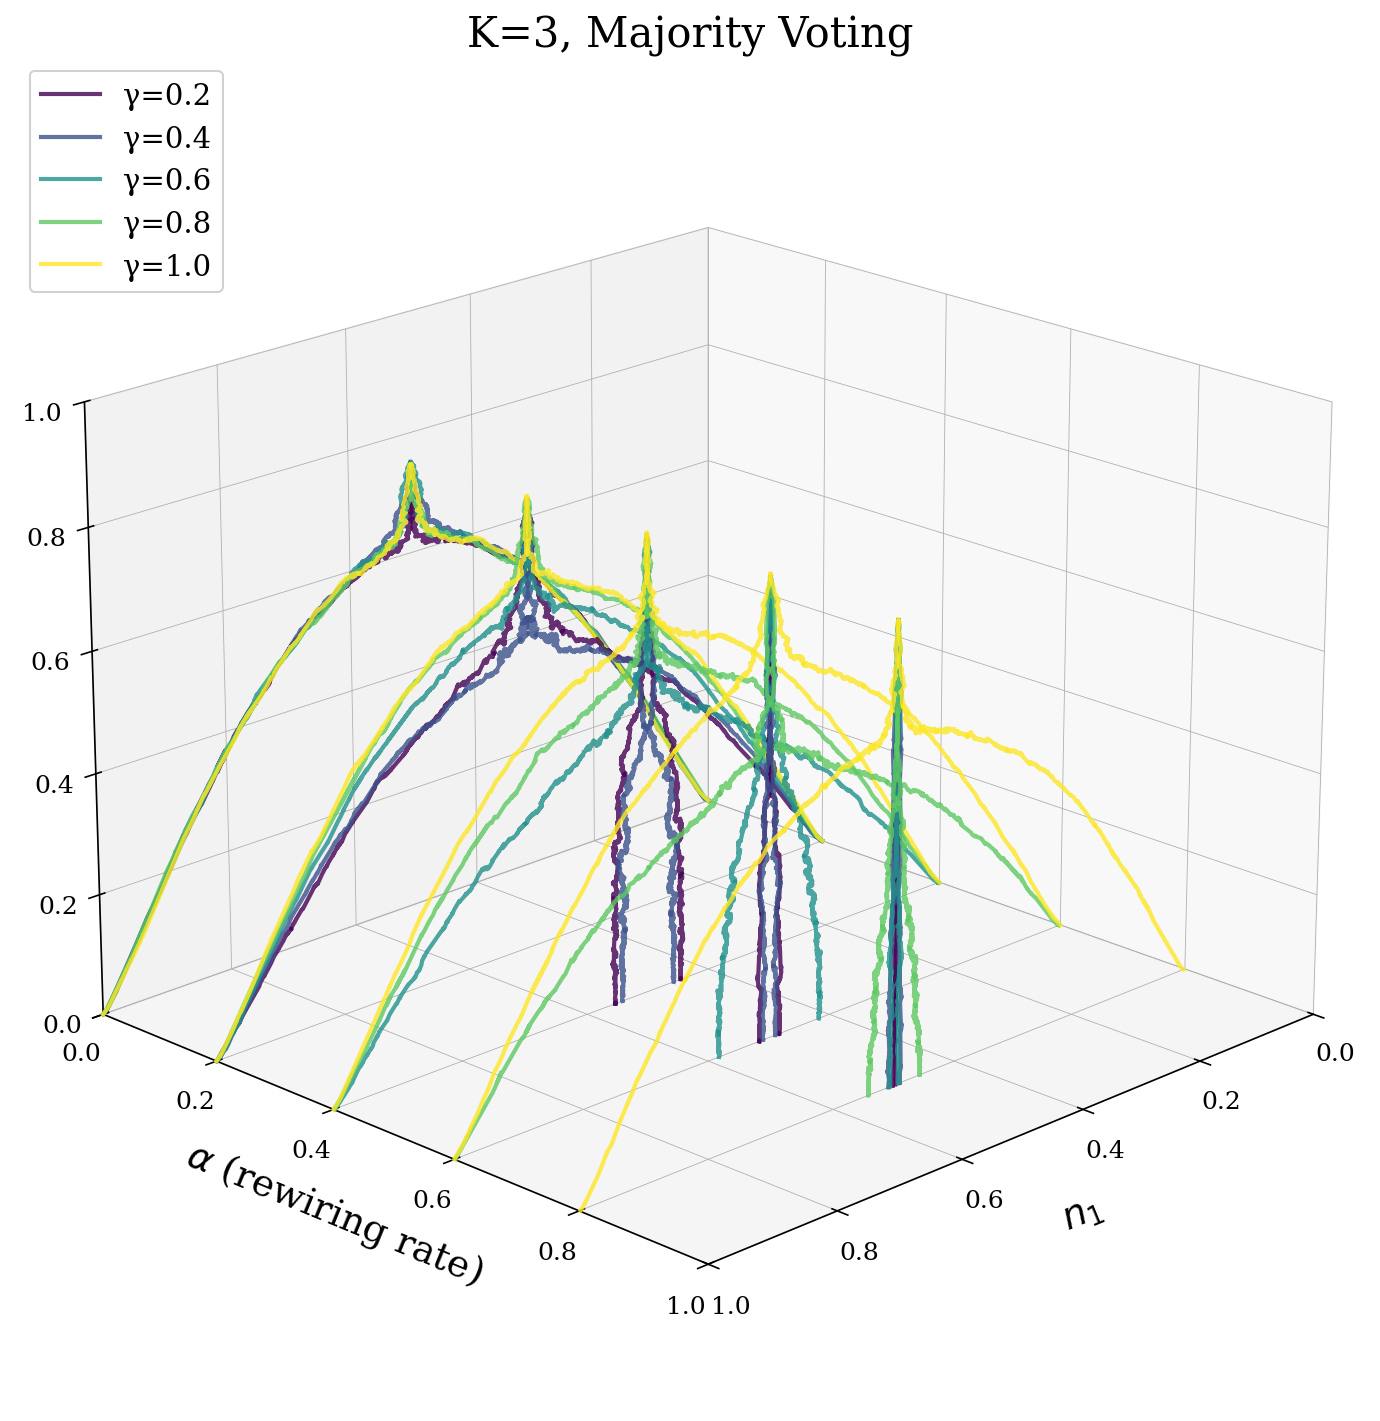

Saved: /content/arch_plot_k4_Majority.png


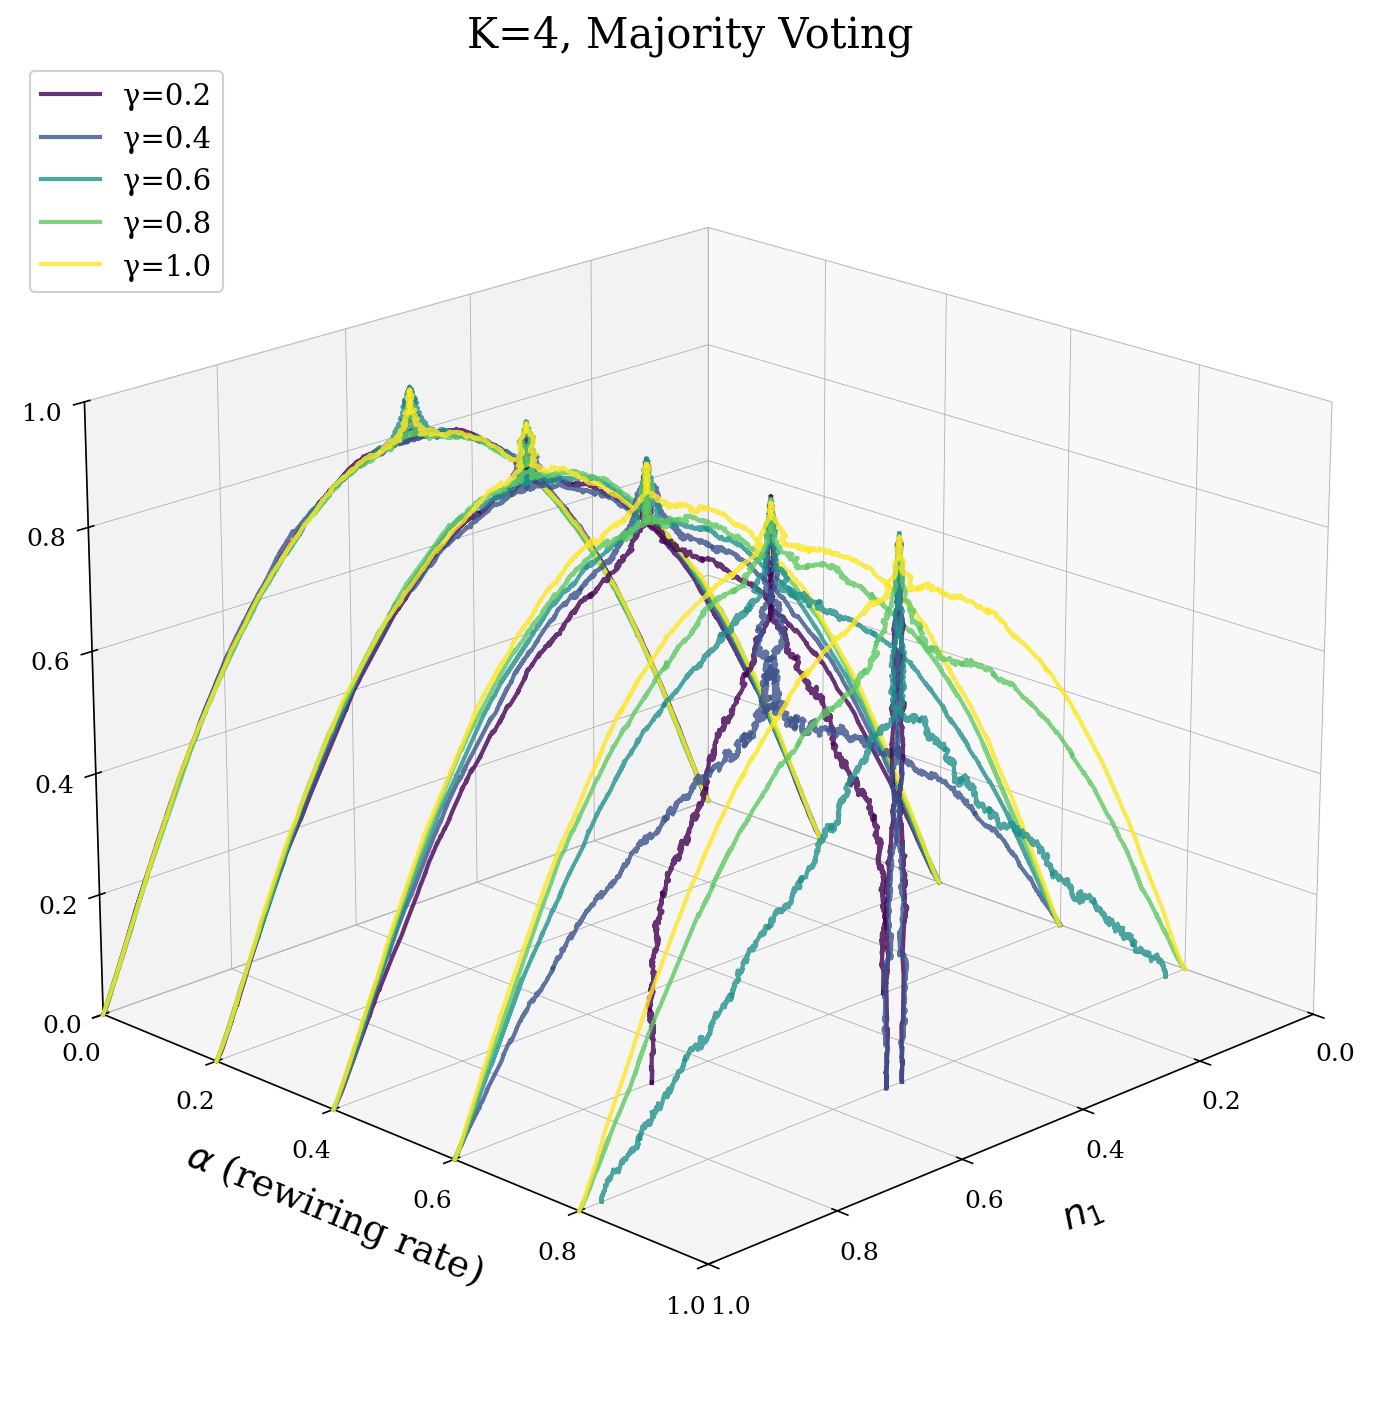

Saved: /content/arch_plot_k3_Proportional.png


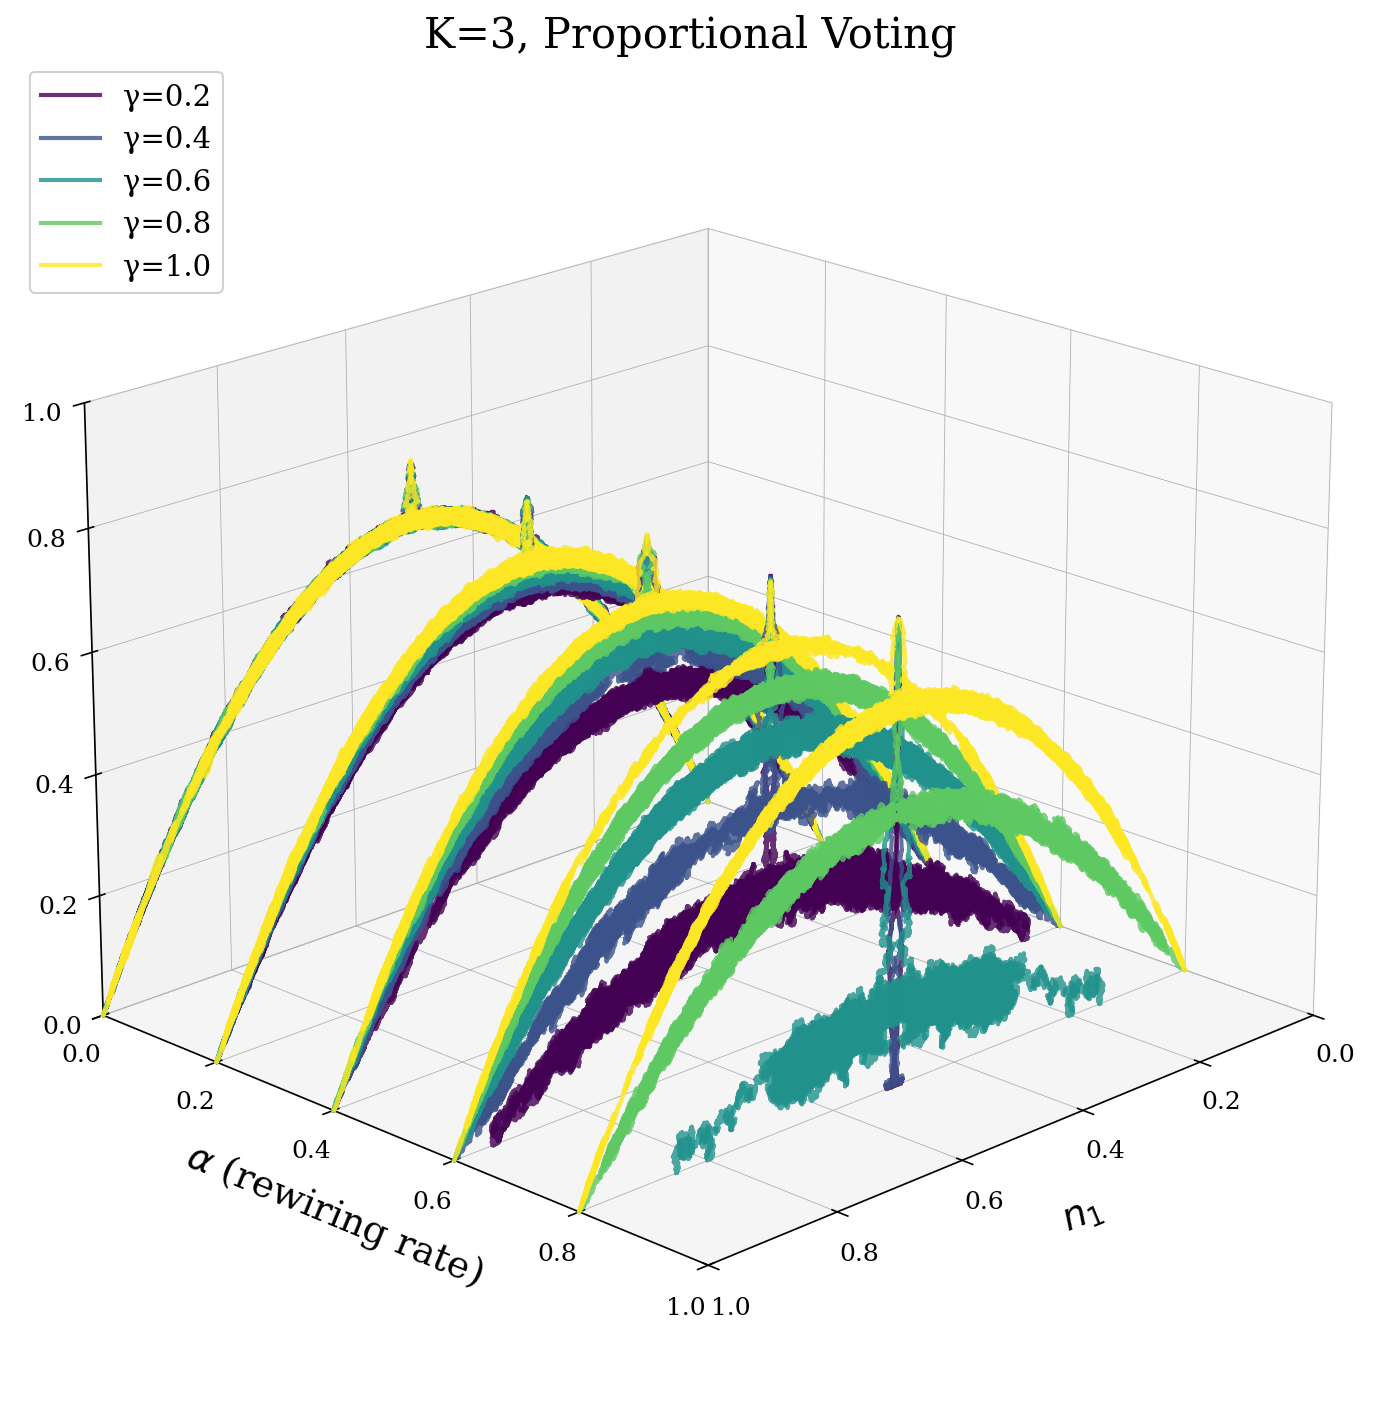

Saved: /content/arch_plot_k4_Proportional.png


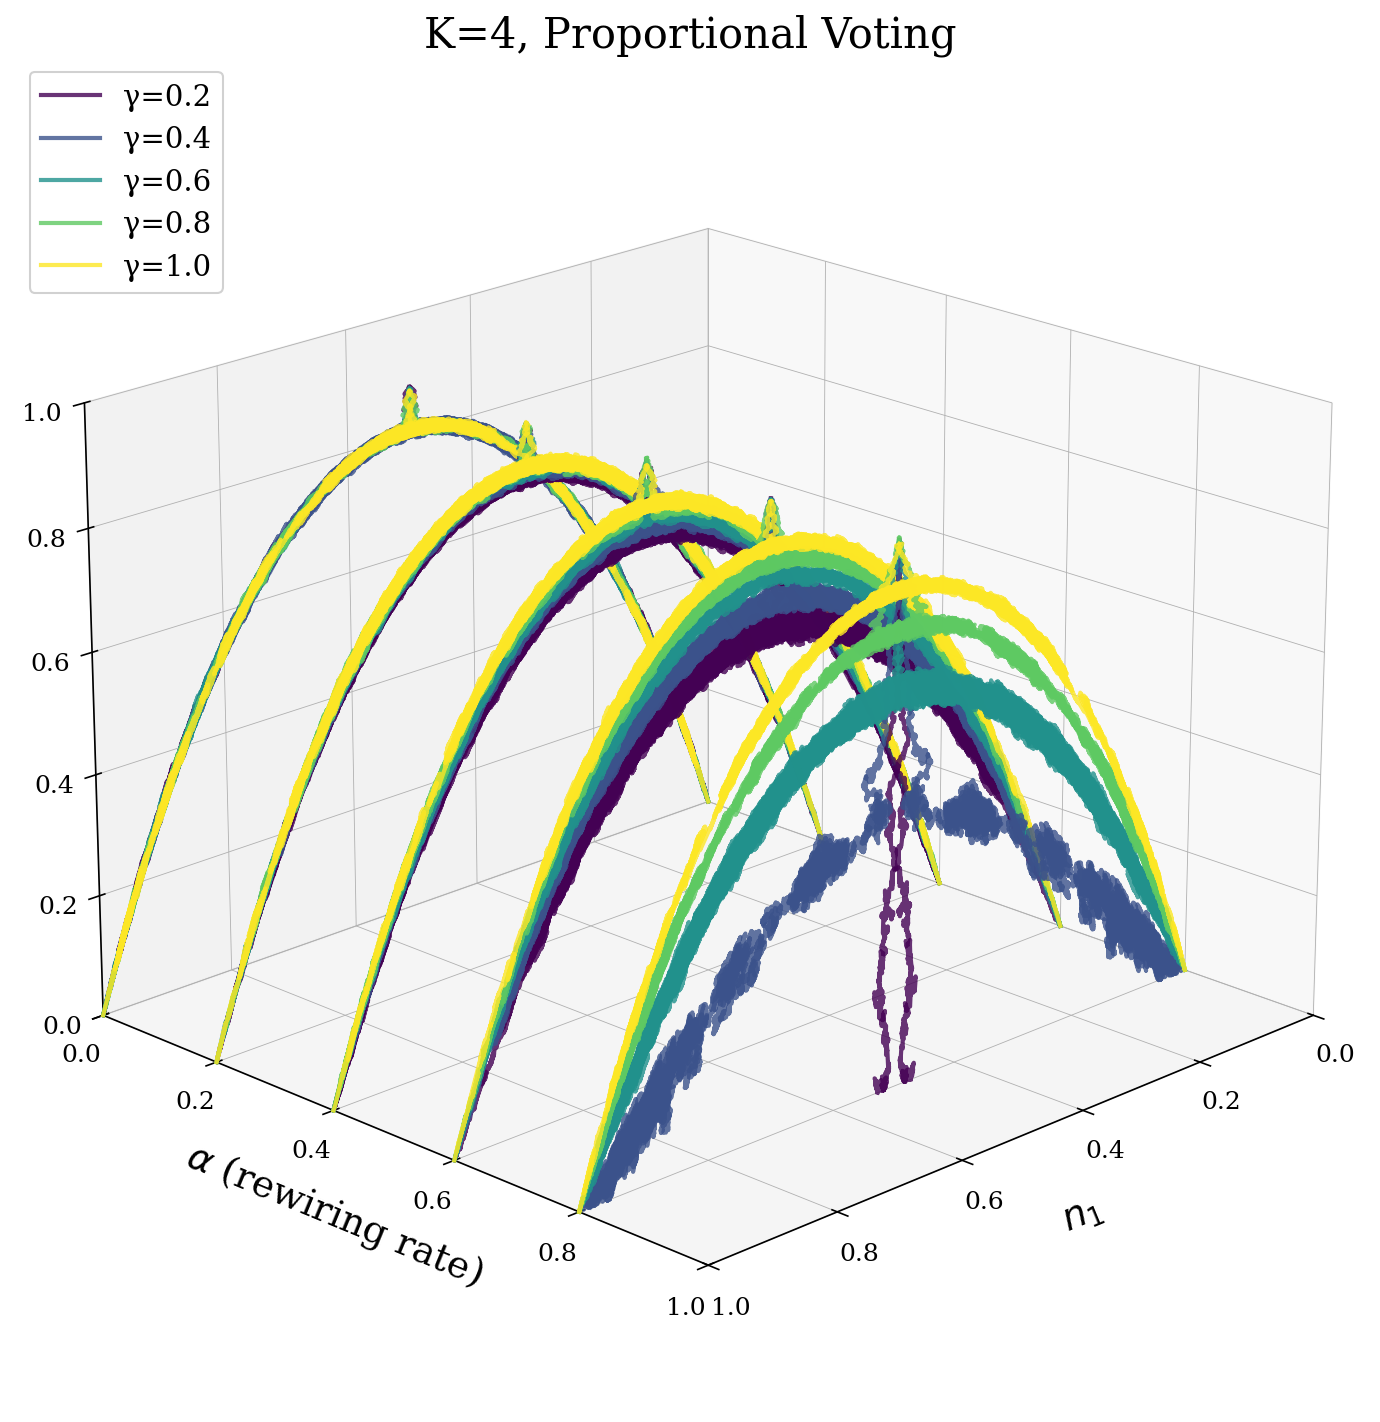

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Fix for too many points in plots
import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000
mpl.rcParams['path.simplify'] = True
mpl.rcParams['path.simplify_threshold'] = 1.0

def create_arch_figure(all_data, k_value, voting_rule, save_path=None):
    """
    Create 3D arch plot similar to publication figure with symmetric mirroring
    """

    gamma_values = [0.2, 0.4, 0.6, 0.8, 1.0]
    alpha_values = [0.0, 0.2, 0.4, 0.6, 0.8]

    colors = cm.viridis(np.linspace(0, 1, len(gamma_values)))
    color_dict = {gamma: colors[i] for i, gamma in enumerate(gamma_values)}

    # Slightly larger figure
    fig = plt.figure(figsize=(13, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Plot curves (same as before)
    for alpha in alpha_values:
        for gamma_idx, gamma in enumerate(gamma_values):
            key = (k_value, alpha, gamma, voting_rule)

            if key not in all_data:
                continue

            data = all_data[key]
            Proportions = data['Proportions']
            DiscordantCounts = data['DiscordantCounts']

            n1_prop = np.array(Proportions)
            alpha_array = np.full_like(n1_prop, alpha)
            add_label = (alpha == alpha_values[-1])

            ax.plot(n1_prop, alpha_array, DiscordantCounts,
                   color=color_dict[gamma],
                   linewidth=2,
                   alpha=0.8,
                   label=f'γ={gamma:.1f}' if add_label else '')

            n1_prop_mirrored = 1.0 - n1_prop
            ax.plot(n1_prop_mirrored, alpha_array, DiscordantCounts,
                   color=color_dict[gamma],
                   linewidth=2,
                   alpha=0.8)

    # Formatting
    ax.set_xlabel(r'$n_1$', fontsize=18, labelpad=10)
    ax.set_ylabel(r'$\alpha$ (rewiring rate)', fontsize=18, labelpad=10)
    ax.set_zlabel(r'$l_{01}$', fontsize=18, labelpad=10, rotation=0)

    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_zlim([0, 1])

    ax.set_title(f'K={k_value}, {voting_rule} Voting', fontsize=20, pad=1)
    ax.legend(loc='upper left', fontsize=14, framealpha=0.9)
    ax.view_init(elev=20, azim=45)

    # Adjust layout with extra padding
    plt.tight_layout(pad=2.0)
    plt.subplots_adjust(left=0.15, right=0.9, top=0.95, bottom=0.05)

    if save_path:
        # Save with extra padding
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.5)
        print(f"Saved: {save_path}")

    return fig, ax

# Generate all 4 figures
voting_rules = ['Majority','Proportional']
k_values = [3,4]

for voting in voting_rules:
    for k in k_values:
        fig, ax = create_arch_figure(
            all_data,
            k_value=k,
            voting_rule=voting,
            save_path=f'/content/arch_plot_k{k}_{voting}.png'
        )
        plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.lines import Line2D
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Fix for too many points in plots
import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000
mpl.rcParams['path.simplify'] = True
mpl.rcParams['path.simplify_threshold'] = 1.0


def create_arch_figure_pair(all_data, k_value, save_path=None):
    """
    Two-panel 3D arch plot for a fixed K: Majority (left) and Proportional
    (right), with a single shared legend.
    """

    gamma_values  = [0.2, 0.4, 0.6, 0.8, 1.0]
    alpha_values  = [0.0, 0.2, 0.4, 0.6, 0.8]
    voting_rules  = ['Majority', 'Proportional']

    colors     = cm.viridis(np.linspace(0, 1, len(gamma_values)))
    color_dict = {gamma: colors[i] for i, gamma in enumerate(gamma_values)}

    fig = plt.figure(figsize=(20, 9))

    for panel_idx, voting_rule in enumerate(voting_rules):
        ax = fig.add_subplot(1, 2, panel_idx + 1, projection='3d')

        for alpha in alpha_values:
            for gamma in gamma_values:
                key = (k_value, alpha, gamma, voting_rule)
                if key not in all_data:
                    continue

                data             = all_data[key]
                Proportions      = data['Proportions']
                DiscordantCounts = data['DiscordantCounts']

                n1_prop     = np.array(Proportions)
                alpha_array = np.full_like(n1_prop, alpha)

                ax.plot(n1_prop, alpha_array, DiscordantCounts,
                        color=color_dict[gamma],
                        linewidth=2, alpha=0.8)

                # mirrored branch
                ax.plot(1.0 - n1_prop, alpha_array, DiscordantCounts,
                        color=color_dict[gamma],
                        linewidth=2, alpha=0.8)

        ax.set_xlabel(r'$\rho$ (minority proportion)', fontsize=18, labelpad=10)
        ax.set_ylabel(r'$\alpha$ (rewiring rate)', fontsize=18, labelpad=10)
        ax.set_zlabel(r'Proportion of Discordant Edges', fontsize=16, labelpad=10, rotation=180)

        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.set_zlim([0, 1])

        ax.set_title(f'{voting_rule} Voting', fontsize=20)#, pad=1)
        ax.view_init(elev=20, azim=45)

    # ── shared legend, built manually from the colour map ─────────────────────
    legend_handles = [
        Line2D([0], [0], color=color_dict[g], linewidth=2.5,
               label=f'γ={g:.1f}')
        for g in gamma_values
    ]
    fig.legend(handles=legend_handles,
               loc='upper center',
               bbox_to_anchor=(0.5, 0.10),
               ncol=len(gamma_values),
               fontsize=15,
               framealpha=0.9)

    fig.suptitle(f'K={k_value}', fontsize=22, y=0.9)

    plt.subplots_adjust(left=0.04, right=0.96, top=0.90, bottom=0.14,
                        wspace=0.05)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.5)
        print(f"Saved: {save_path}")

    return fig


# Generate one two-panel figure per K
for k in [4]:
    fig = create_arch_figure_pair(
        all_data,
        k_value=k,
        save_path=f'/content/arch_plot_k{k}_both.png'
    )
    plt.show()

In [ ]:
def ConstructCliqueComplex(G, k = float('inf')):
    """
    Input a networkx graph G and output the clique simplicial
    complex corresponding to G, where every node, edge and
    clique (up to and including size k) is encoded as simplices.
    """
    # Find all maximal cliques in G which correspond to the maximal simplices
    Cliques = list(nx.find_cliques(G))
    Complex = set(tuple([v]) for v in G.nodes())
    for e in G.edges:
        Complex.add(e)

    # Iterate across each maximal clique, and include each subset of the clique
    # as a simplex in the complex. The set() structure, with sorted(), avoids the issue of
    # including identical simplices multiple times.
    for clique in Cliques:
        numNodes = len(clique)
        # For a clique of n nodes, include the clique itself, its n-1 subsets, n-2 subsets,
        # all the way down to the 2-subsets (edges) and 1-subsets (nodes)
        # We do sorted() to avoid double creating simplices
        clique = sorted(clique)
        for r in range(min(numNodes, k), 2, -1):
            # combinations(S,r) is from itertools and returns iterator corresponding
            # to all r-subsets of S.
            for face in combinations(clique, r):
                Complex.add(face)

    return (Complex)

def nFaces(Complex, n):
    """
    Input a simplicial complex and integer n >= 0 and return all n-simplices (simplices with n+1 nodes)
    """
    # Filter function iterates through the faces of the complex and filters those with n+1 nodes
    return list(filter(lambda face: len(face) == n+1, Complex))

def SimplexCounts(Complex):
    """
    Input a simplical complex and return the counts of simplices of each dimension,
    as well as the dimension of the complex (largest dimension of simplices).
    """
    Counts = [len(nFaces(Complex, 0))]
    Dim = 0
    while True:
        temp = len(nFaces(Complex, Dim + 1))
        if temp > 0:
            Counts.append(temp)
            Dim = Dim + 1
        else:
            break
    return Counts, Dim

def BettiNumbersFromPH(G, p = 2):
  """
  Input a networkx graph G, and prime p to compute the betti
  numbers of the clique complex of G over Z mod p. We restrict
  the complex to include nodes, edges, triangles and tetrahedra.
  This ensures correctness of b0, b1 and b2 with minimal computation
  """
  Complex = ConstructCliqueComplex(G,4)
  Simplices = [(list(simplex), len(simplex)-1) for simplex in Complex]

  # Create filtration of simplicial complexes using Times
  f = d.Filtration(Simplices)
  # Compute persistent homology of filtration
  m = d.homology_persistence(f, p)

  # PH doesn't return betti numbers, it returns persistence pairs
  # Here we loop through pairs, any time between the birth
  # and death of the pair corresponds to the existence of a hole
  Betti = np.zeros((4,3))
  one = np.ones(3)
  dgms = d.init_diagrams(m,f)
  for i, dgm in enumerate(dgms):
    for p in dgm:
      Betti[i][int(p.birth):int(min(p.death,3))] += one[int(p.birth):int(min(p.death,3))]

  return [Betti[0][-1], Betti[1][-1], Betti[2][-1]]

def ComputeResults(G, p = 2):
  """
  Input a networkx graph G, and prime p to compute the betti
  numbers of the clique complex of G over Z mod p. Return the
  exact euler characteristic, as well as Betti numbers b0, b1, b2.
  """
  Complex = ConstructCliqueComplex(G)
  Counts = SimplexCounts(Complex)[0]; Euler = 0
  for i in range(len(Counts)):
    Euler += Counts[i] * (-1)**i

  Simplices = [(list(simplex), len(simplex)-1) for simplex in Complex if len(simplex) <= 4]

  # Create filtration of simplicial complexes using Times
  f = d.Filtration(Simplices)
  # Compute persistent homology of filtration
  m = d.homology_persistence(f, p)

  # PH doesn't return betti numbers, it returns persistence pairs
  # Here we loop through pairs, any time between the birth
  # and death of the pair corresponds to the existence of a hole
  Betti = np.zeros((4,4))
  one = np.ones(4)
  dgms = d.init_diagrams(m,f)
  for i, dgm in enumerate(dgms):
    for p in dgm:
      Betti[i][int(p.birth):int(min(p.death,4))] += one[int(p.birth):int(min(p.death,4))]

  return [Betti[0][-1], Betti[1][-1], Betti[2][-1], Euler, Counts]

In [ ]:
# =============================================================================
# CONFIGURATION
# =============================================================================

import os, gzip, pickle
import numpy as np
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

BASE_G = ('/content/drive/Othercomputers/My Computer (1)/Dissertation/'
          'VoterData/G/Triangle/')
PROC_G = os.path.join(BASE_G, 'proc')
os.makedirs(PROC_G, exist_ok=True)

n          = 5000
m          = 10000
alphas     = np.linspace(0, 1, 21)
gammas     = np.linspace(0, 1, 21)
iterations = range(1, 11)
rhos       = [0.1, 0.2, 0.3, 0.4]
na, ng     = len(alphas), len(gammas)
fields_g   = ['b0', 'b1', 'b2', 'euler', 'N0', 'N1', 'N2', 'N3']

alpha_labels = [f'{a:.2f}' for a in alphas]
gamma_labels = [f'{g:.2f}' for g in gammas]
tick_interval = 5

def proc_graph_fname(rho, alpha, gamma, iteration):
    rs = str(rho).replace('.', '_')
    return os.path.join(PROC_G,
        f'tda_rho{rs}_a{alpha:.4f}_g{gamma:.4f}_it{iteration}.pkl.gz')


# =============================================================================
# PART I: PARALLEL COMPUTE AND SAVE
# =============================================================================

def compute_and_save_graph(rho, alpha, gamma, iteration, graph):
    pfname = proc_graph_fname(rho, alpha, gamma, iteration)
    if os.path.isfile(pfname):
        return 'exists'
    try:
        res  = ComputeResults(graph)
        cnts = res[4] if res[4] is not None else []
        out  = {
            'b0':    res[0],
            'b1':    res[1],
            'b2':    res[2],
            'euler': res[3],
            'N0':    cnts[0] if len(cnts) > 0 else 0,
            'N1':    cnts[1] if len(cnts) > 1 else 0,
            'N2':    cnts[2] if len(cnts) > 2 else 0,
            'N3':    cnts[3] if len(cnts) > 3 else 0,
        }
        with gzip.open(pfname, 'wb') as f:
            pickle.dump(out, f)
        return 'done'
    except Exception as e:
        return f'error: {e}'

In [ ]:
# =============================================================================
# PART II: PARALLEL LOAD AND ACCUMULATE
# =============================================================================

all_jobs_g = [
    (rho, ai, gi, it)
    for rho in rhos
    for ai, _ in enumerate(alphas)
    for gi, _ in enumerate(gammas)
    for it in iterations
]

sums_g   = {rho: {fld: np.zeros((ng, na)) for fld in fields_g}
            for rho in rhos}
counts_g = {rho: np.zeros((ng, na)) for rho in rhos}


def load_one_graph(rho, ai, gi, it):
    pfname = proc_graph_fname(rho, alphas[ai], gammas[gi], it)
    if not os.path.isfile(pfname):
        return None
    try:
        with gzip.open(pfname, 'rb') as f:
            res = pickle.load(f)
        return (rho, ai, gi, res)
    except Exception:
        return None


print('Loading graph TDA results...')
results_g = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_one_graph)(rho, ai, gi, it)
    for rho, ai, gi, it in tqdm(all_jobs_g, desc='Submitting')
)

for out in tqdm(results_g, desc='Accumulating'):
    if out is None:
        continue
    rho, ai, gi, res = out
    for fld in fields_g:
        sums_g[rho][fld][gi, ai] += res[fld]
    counts_g[rho][gi, ai] += 1


# ── means and derived quantities ──────────────────────────────────────────────

def gmean(rho, fld):
    c = counts_g[rho]
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(c > 0, sums_g[rho][fld] / c, np.nan)

means_g = {rho: {fld: gmean(rho, fld) for fld in fields_g}
           for rho in rhos}

derived_g = {}
for rho in rhos:
    means = means_g[rho]
    b0, b1, b2       = means['b0'], means['b1'], means['b2']
    N0, N1, N2, N3   = means['N0'], means['N1'], means['N2'], means['N3']
    euler            = means['euler']

    with np.errstate(invalid='ignore', divide='ignore'):
        tb0   = np.where(N0 > 0, b0 / N0, np.nan)
        tb1   = np.where(N1 > 0, b1 / N1, np.nan)
        tb2   = np.where(N2 > 0, b2 / N2, np.nan)
        CR1   = N1 - N0 + b0
        CR1b1 = CR1 - b1
        g1    = np.where(N2 > 0, CR1b1 / N2, np.nan)
        CR2   = N2 - CR1 + b1
        CR2b2 = CR2 - b2
        g2    = np.where(N3 > 0, CR2b2 / N3, np.nan)

    derived_g[rho] = {
        r'$\beta_0$ (components)':                          b0,
        r'$\tilde{\beta}_0=\beta_0/N$':                  tb0,
        r'$\beta_1$ (tunnels)':                          b1,
        r'$\tilde{\beta}_1=\beta_1/N_1$':                  tb1,
        r'$\beta_2$ (voids)':                          b2,
        r'$\tilde{\beta}_2=\beta_2/N_2$':                  tb2,
        r'$\chi$ (Euler characteristic)':                             euler,
        r'$N_1$ (edges)':                              N1,
        r'$N_2$ (triangles)':                              N2,
        r'$N_3$ (tetrahedra)':                              N3,
        r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)':        CR1b1,
        r'$\gamma_1$ (1-filling efficiency)':                         g1,
        r'$\mathcal{CR}_2 - \beta_2$ (filled voids)':        CR2b2,
        r'$\gamma_2$ (2-filling efficiency)':                         g2,
    }

Loading graph TDA results...


Submitting:   0%|          | 0/17640 [00:00<?, ?it/s]

Accumulating:   0%|          | 0/17640 [00:00<?, ?it/s]

Saved: /content/drive/Othercomputers/My Computer (1)/Dissertation/VoterData/G/Triangle/heatmap_styled_n5000_m10000_rho0_4.png


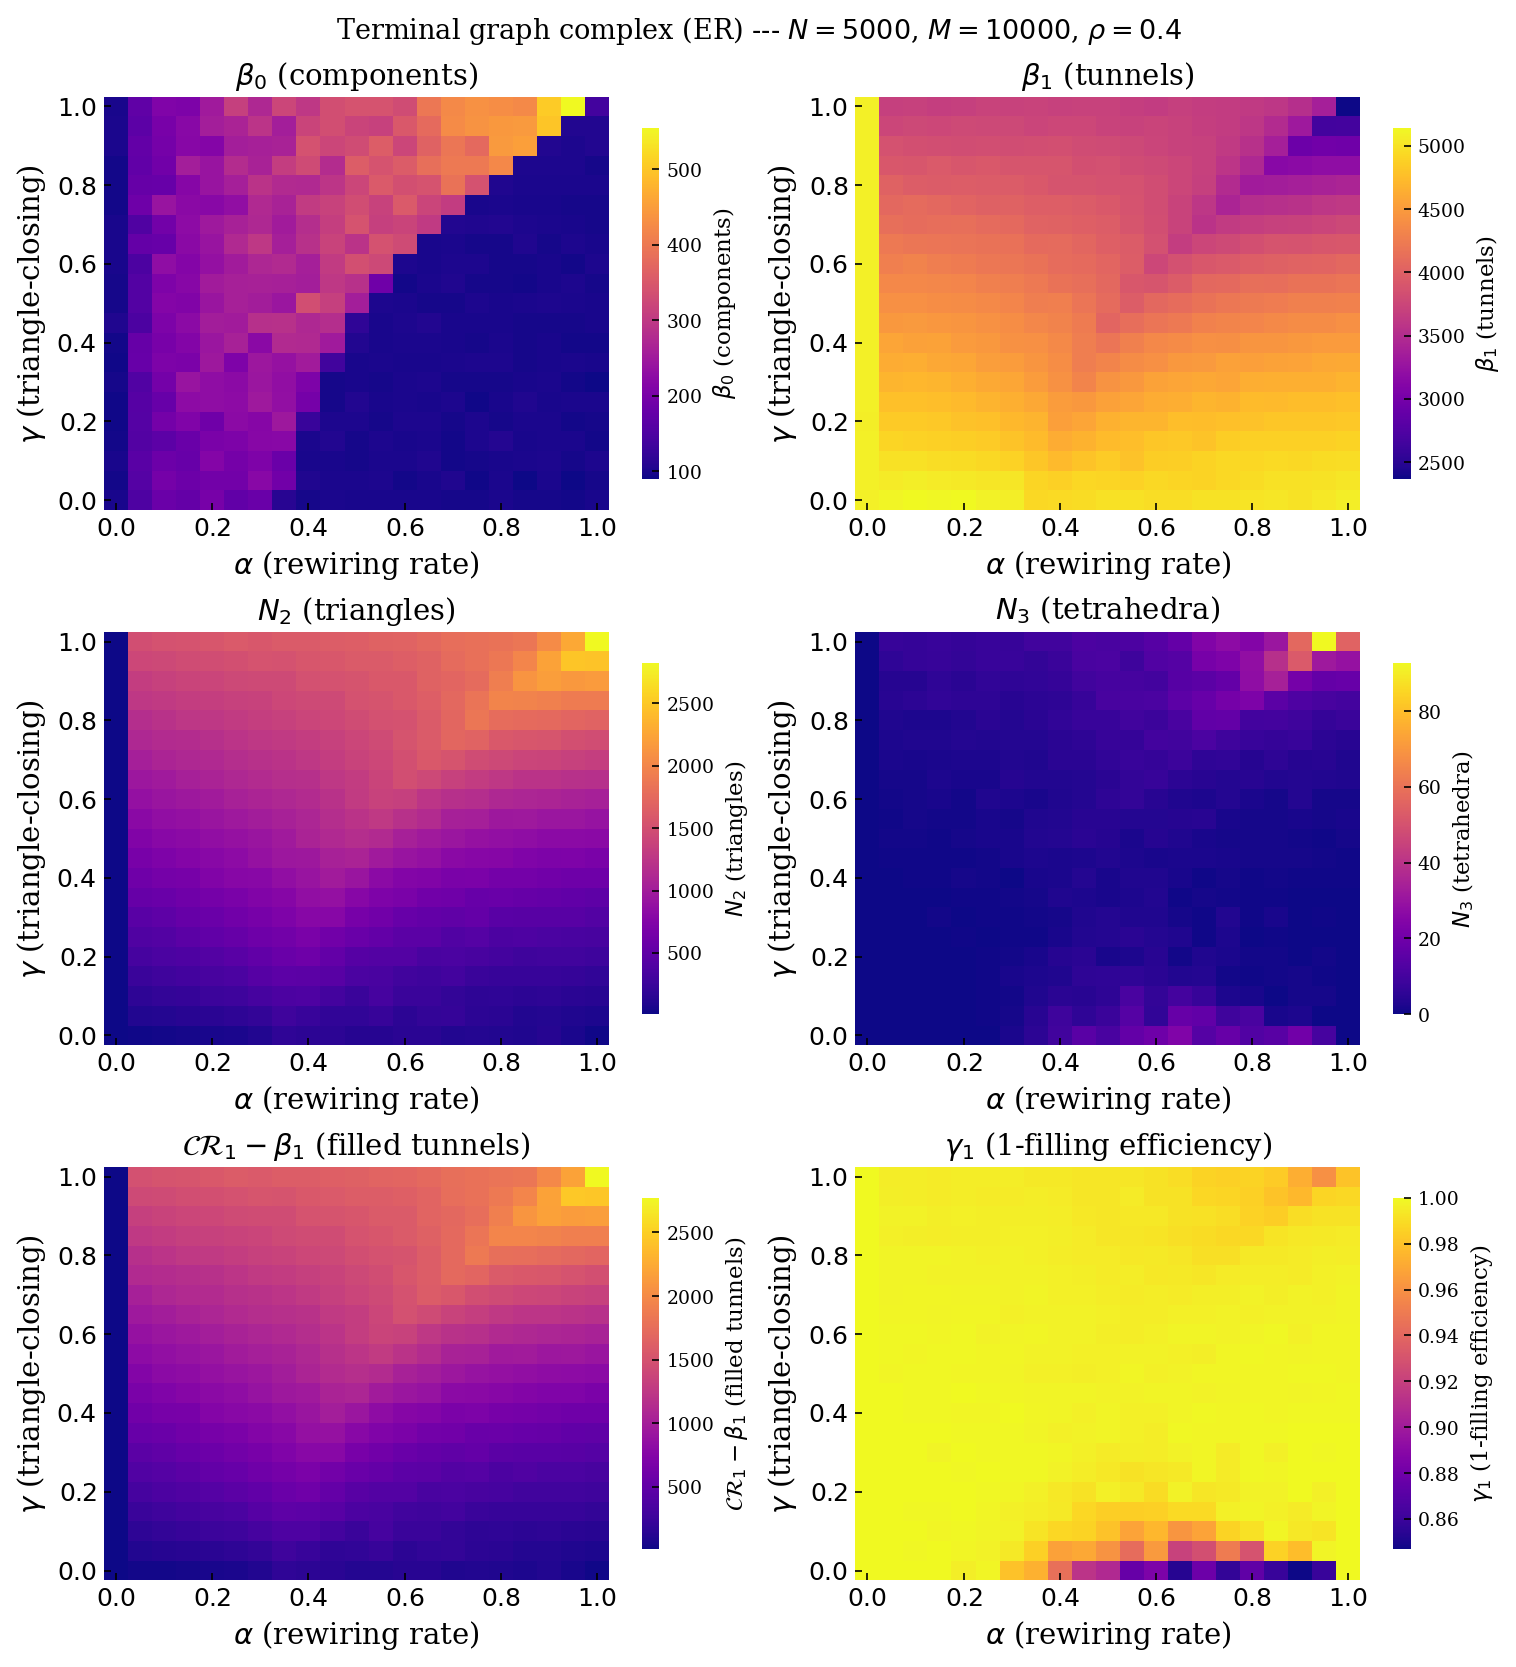

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── style to match hypergraph figures ─────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         13,
    'axes.labelsize':    14,
    'axes.titlesize':    14,
    'legend.fontsize':   13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
    'axes.grid':         False,
    'grid.linewidth':    0.4
})

CMAP      = 'plasma'
RHO       = 0.4
TICK_IDX  = np.arange(0, na, 4)           # 0.0, 0.2, 0.4, 0.6, 0.8, 1.0
XLABELS   = [rf'${alphas[i]:.1f}$' for i in TICK_IDX]
YLABELS   = [rf'${gammas[i]:.1f}$' for i in TICK_IDX]

def plot_graph_heatmaps_styled(rho=RHO, save_path=None):

    panels = [
        (r'$\beta_0$ (components)',                      derived_g[rho][r'$\beta_0$ (components)']),
        (r'$\beta_1$ (tunnels)',                      derived_g[rho][r'$\beta_1$ (tunnels)']),
        (r'$N_2$ (triangles)',                          derived_g[rho][r'$N_2$ (triangles)']),
        (r'$N_3$ (tetrahedra)',                          derived_g[rho][r'$N_3$ (tetrahedra)']),
        (r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)',    derived_g[rho][r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)']),
        (r'$\gamma_1$ (1-filling efficiency)',                     derived_g[rho][r'$\gamma_1$ (1-filling efficiency)']),
    ]

    fig, axes = plt.subplots(
        3, 2,
        figsize=(10, 11),
        constrained_layout=True,
    )

    for ax, (label, data) in zip(axes.flatten(), panels):
        sns.heatmap(
            data,
            ax          = ax,
            cmap        = CMAP,
            mask        = np.isnan(data),
            cbar        = True,
            cbar_kws    = {'label': label, 'shrink': 0.85},
            xticklabels = False,
            yticklabels = False,
            linewidths  = 0,
            rasterized  = True,
        )
        ax.invert_yaxis()

        ax.set_xticks(TICK_IDX + 0.5)
        ax.set_xticklabels(XLABELS, rotation=0)
        ax.set_yticks(TICK_IDX + 0.5)
        ax.set_yticklabels(YLABELS, rotation=0)
        ax.set_xlabel(r'$\alpha$ (rewiring rate)')
        ax.set_ylabel(r'$\gamma$ (triangle-closing)')
        ax.set_title(label)

        # match colorbar label font size
        ax.collections[0].colorbar.ax.tick_params(labelsize=9)
        ax.collections[0].colorbar.set_label(label, size=11)

    fig.suptitle(
        rf'Terminal graph complex (ER)'
        rf' --- $N = {n}$, $M = {m}$, $\rho = {rho}$',
        fontsize=13,
    )

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


plot_graph_heatmaps_styled(
    rho       = RHO,
    save_path = os.path.join(
        BASE_G,
        f'heatmap_styled_n{n}_m{10000}_rho{str(RHO).replace(".", "_")}.png'
    )
)

Saved: /content/drive/Othercomputers/My Computer (1)/Dissertation/VoterData/G/Triangle/heatmap_styled_n5000_m10000_rho0_4.png


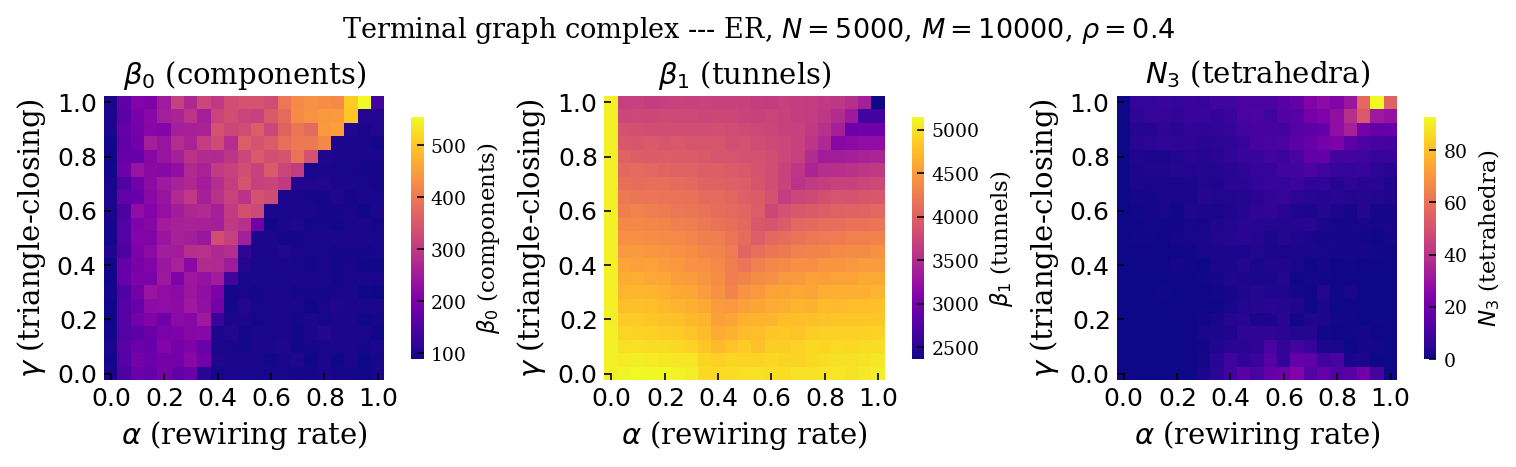

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

CMAP      = 'plasma'
RHO       = 0.4
TICK_IDX  = np.arange(0, na, 4)           # 0.0, 0.2, 0.4, 0.6, 0.8, 1.0
XLABELS   = [rf'${alphas[i]:.1f}$' for i in TICK_IDX]
YLABELS   = [rf'${gammas[i]:.1f}$' for i in TICK_IDX]

def plot_graph_heatmaps_styled_pres(rho=RHO, save_path=None):

    panels = [
        (r'$\beta_0$ (components)',                      derived_g[rho][r'$\beta_0$ (components)']),
        (r'$\beta_1$ (tunnels)',                      derived_g[rho][r'$\beta_1$ (tunnels)']),
        (r'$N_3$ (tetrahedra)',                          derived_g[rho][r'$N_3$ (tetrahedra)']),
    ]

    fig, axes = plt.subplots(
        1, 3,
        figsize=(10, 3),
        constrained_layout=True,
    )

    for ax, (label, data) in zip(axes.flatten(), panels):
        sns.heatmap(
            data,
            ax          = ax,
            cmap        = CMAP,
            mask        = np.isnan(data),
            cbar        = True,
            cbar_kws    = {'label': label, 'shrink': 0.85},
            xticklabels = False,
            yticklabels = False,
            linewidths  = 0,
            rasterized  = True,
        )
        ax.invert_yaxis()

        ax.set_xticks(TICK_IDX + 0.5)
        ax.set_xticklabels(XLABELS, rotation=0)
        ax.set_yticks(TICK_IDX + 0.5)
        ax.set_yticklabels(YLABELS, rotation=0)
        ax.set_xlabel(r'$\alpha$ (rewiring rate)')
        ax.set_ylabel(r'$\gamma$ (triangle-closing)')
        ax.set_title(label)

        # match colorbar label font size
        ax.collections[0].colorbar.ax.tick_params(labelsize=9)
        ax.collections[0].colorbar.set_label(label, size=11)

    fig.suptitle(
        rf'Terminal graph complex'
        rf' --- ER, $N = {n}$, $M = {m}$, $\rho = {rho}$',
        fontsize=13,
    )

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


plot_graph_heatmaps_styled_pres(
    rho       = RHO,
    save_path = os.path.join(
        BASE_G,
        f'heatmap_styled_n{n}_m{10000}_rho{str(RHO).replace(".", "_")}.png'
    )
)

Computing TDA for BA and WS graphs...


Computing:   0%|          | 0/8820 [00:00<?, ?it/s]

Loading BA/WS TDA results...


Submitting:   0%|          | 0/8820 [00:00<?, ?it/s]

Accumulating:   0%|          | 0/8820 [00:00<?, ?it/s]

Saved: /content/drive/Othercomputers/My Computer (1)/BA/heatmap_styled_BA_n5000_m10000_rho0_4.png


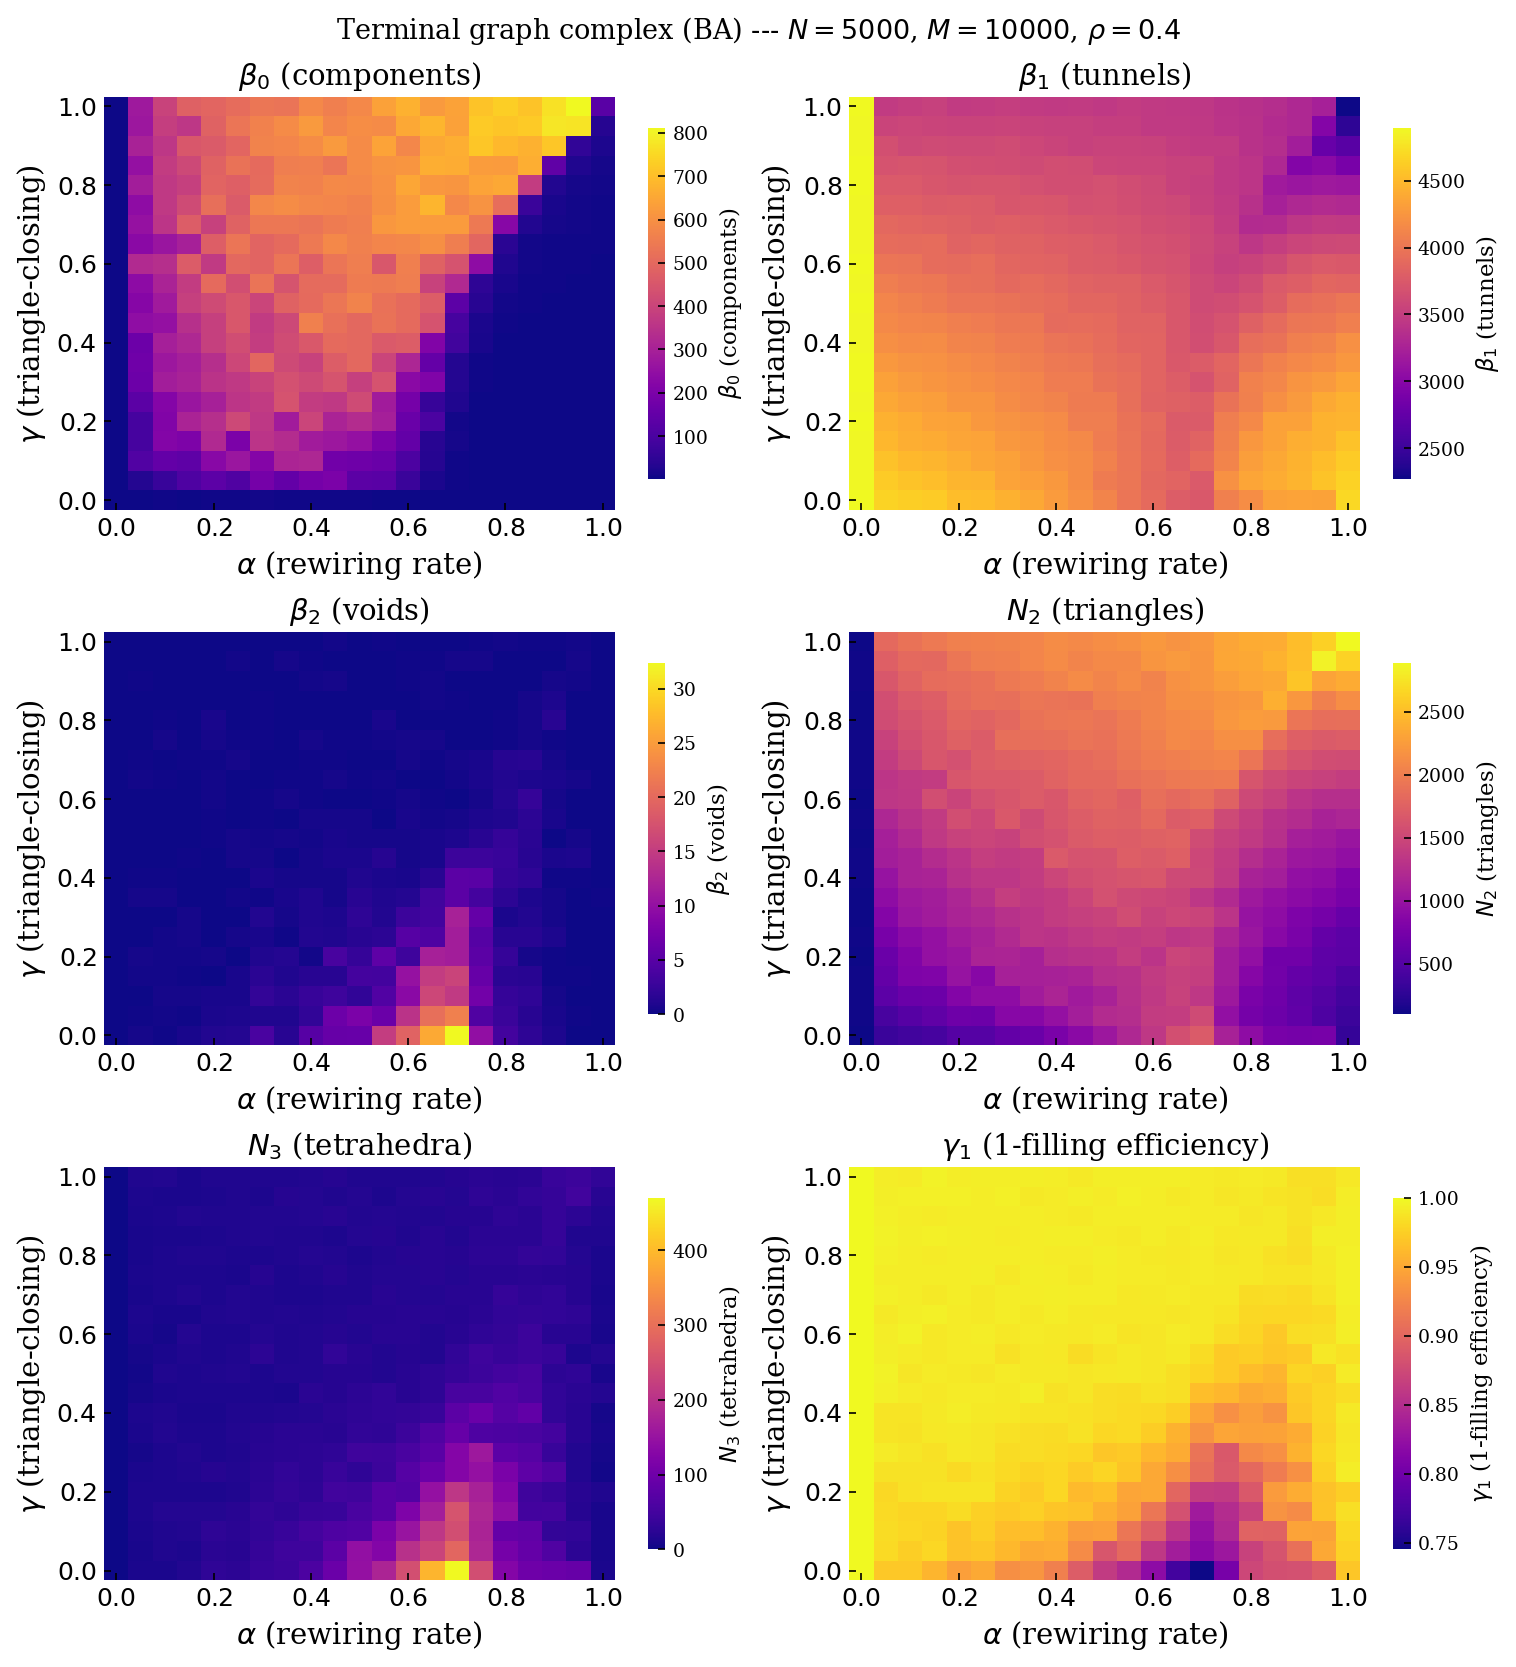

Saved: /content/drive/Othercomputers/My Computer (1)/WS/heatmap_styled_WS_n5000_m10000_rho0_4.png


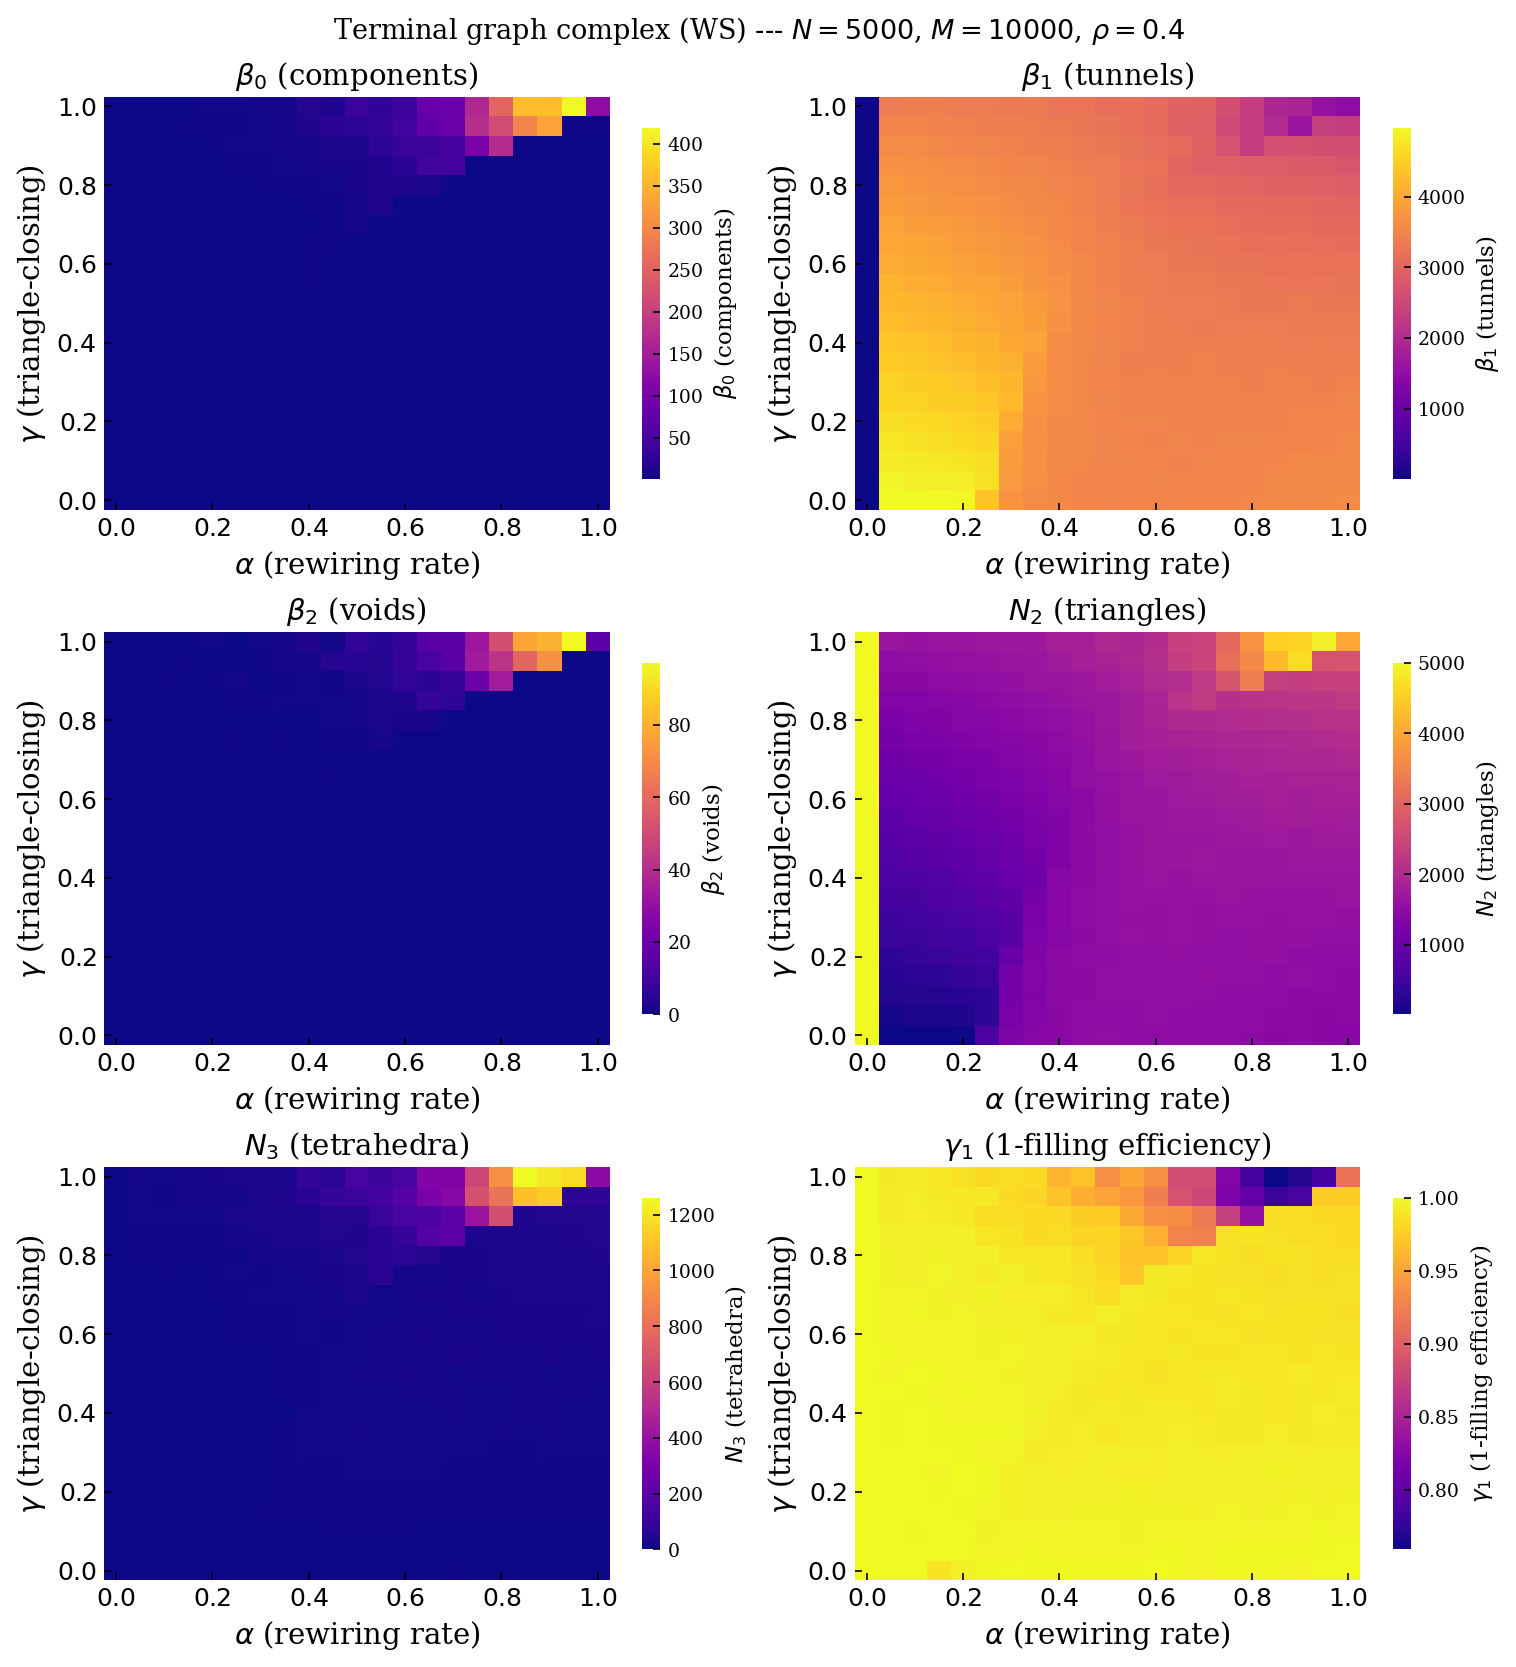

In [ ]:
# =============================================================================
# CONFIGURATION
# =============================================================================
import seaborn as sns
MODELS     = ['BA', 'WS']
RHO        = 0.4
n, m       = 5000, 10000
alphas     = np.linspace(0, 1, 21)
gammas     = np.linspace(0, 1, 21)
iterations = range(1, 11)
na, ng     = len(alphas), len(gammas)
fields_g   = ['b0', 'b1', 'b2', 'euler', 'N0', 'N1', 'N2', 'N3']

BASE_GRAPH = ('/content/drive/Othercomputers/My Computer (1)/')

def raw_fname(model, rho, alpha, gamma, iteration):
    """Path to the individual terminal graph file."""
    return os.path.join(
        BASE_GRAPH, model,
        f'G_{model}_{n}_{m}_'+str(rho).replace('.','_')+'_'+str(alpha).replace('.','_')+'_'+str(gamma).replace('.','_')+'_'+str(iteration)+'.pkl'
    )

def proc_fname_baws(model, alpha, gamma, iteration):
    """Path to the saved TDA result for one (model, alpha, gamma, iteration)."""
    d = os.path.join(BASE_GRAPH, model, 'proc')
    os.makedirs(d, exist_ok=True)
    return os.path.join(d, f'tda_a{alpha:.4f}_g{gamma:.4f}_it{iteration}.pkl.gz')

def load_raw_graph(path):
    """Try gzip pickle first, fall back to plain pickle."""
    try:
        with gzip.open(path, 'rb') as f:
            return pickle.load(f)
    except Exception:
        pass
    try:
        with open(path, 'rb') as f:
            return pickle.load(f)
    except Exception:
        return None


# =============================================================================
# PART I: PARALLEL COMPUTE AND SAVE
# =============================================================================

def compute_and_save_baws(model, rho, alpha, gamma, iteration):
    pfname = proc_fname_baws(model, alpha, gamma, iteration)
    if os.path.isfile(pfname):
        return 'exists'
    data = load_raw_graph(raw_fname(model, rho, alpha, gamma, iteration))
    if data is None:
        return 'missing'
    try:
        graph = data[3]
        res  = ComputeResults(graph)
        cnts = res[4] if res[4] is not None else []
        out  = {
            'b0':    res[0],
            'b1':    res[1],
            'b2':    res[2],
            'euler': res[3],
            'N0':    cnts[0] if len(cnts) > 0 else 0,
            'N1':    cnts[1] if len(cnts) > 1 else 0,
            'N2':    cnts[2] if len(cnts) > 2 else 0,
            'N3':    cnts[3] if len(cnts) > 3 else 0,
        }
        with gzip.open(pfname, 'wb') as f:
            pickle.dump(out, f)
        return 'done'
    except Exception as e:
        return f'error: {e}'


all_jobs_baws = [
    (model, RHO, alpha, gamma, it)
    for model in MODELS
    for alpha in alphas
    for gamma in gammas
    for it in iterations
]

print('Computing TDA for BA and WS graphs...')
Parallel(n_jobs=-1, backend='loky')(
    delayed(compute_and_save_baws)(model, rho, alpha, gamma, it)
    for model, rho, alpha, gamma, it
    in tqdm(all_jobs_baws, desc='Computing')
)


# =============================================================================
# PART II: PARALLEL LOAD AND ACCUMULATE
# =============================================================================

sums_baws   = {model: {fld: np.zeros((ng, na)) for fld in fields_g}
               for model in MODELS}
counts_baws = {model: np.zeros((ng, na)) for model in MODELS}

def load_one_baws(model, ai, gi, it):
    pfname = proc_fname_baws(model, alphas[ai], gammas[gi], it)
    if not os.path.isfile(pfname):
        return None
    try:
        with gzip.open(pfname, 'rb') as f:
            res = pickle.load(f)
        return (model, ai, gi, res)
    except Exception:
        return None

load_jobs = [
    (model, ai, gi, it)
    for model in MODELS
    for ai in range(na)
    for gi in range(ng)
    for it in iterations
]

print('Loading BA/WS TDA results...')
results_baws = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_one_baws)(model, ai, gi, it)
    for model, ai, gi, it in tqdm(load_jobs, desc='Submitting')
)

for out in tqdm(results_baws, desc='Accumulating'):
    if out is None:
        continue
    model, ai, gi, res = out
    for fld in fields_g:
        sums_baws[model][fld][gi, ai] += res[fld]
    counts_baws[model][gi, ai] += 1


# ── means and derived quantities ──────────────────────────────────────────────

def gmean_baws(model, fld):
    c = counts_baws[model]
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(c > 0, sums_baws[model][fld] / c, np.nan)

means_baws = {model: {fld: gmean_baws(model, fld) for fld in fields_g}
              for model in MODELS}

derived_baws = {}
for model in MODELS:
    m_ = means_baws[model]
    b0, b1, b2     = m_['b0'], m_['b1'], m_['b2']
    N0, N1, N2, N3 = m_['N0'], m_['N1'], m_['N2'], m_['N3']
    euler          = m_['euler']

    with np.errstate(invalid='ignore', divide='ignore'):
        tb0   = np.where(N0 > 0, b0 / N0, np.nan)
        tb1   = np.where(N1 > 0, b1 / N1, np.nan)
        tb2   = np.where(N2 > 0, b2 / N2, np.nan)
        CR1   = N1 - N0 + b0
        CR1b1 = CR1 - b1
        g1    = np.where(N2 > 0, CR1b1 / N2, np.nan)
        CR2   = N2 - CR1 + b1
        CR2b2 = CR2 - b2
        g2    = np.where(N3 > 0, CR2b2 / N3, np.nan)

    derived_baws[model] = {
        r'$\beta_0$ (components)':                      b0,
        r'$\beta_1$ (tunnels)':                      b1,
        r'$\beta_2$ (voids)':                      b2,
        r'$N_2$ (triangles)':                          N2,
        r'$N_3$ (tetrahedra)':                          N3,
        r'$\gamma_1$ (1-filling efficiency)':                     g1,
    }


# =============================================================================
# PART III: PLOTTING
# =============================================================================

TICK_IDX = np.arange(0, na, 4)
XLABELS  = [f'${alphas[i]:.1f}$' for i in TICK_IDX]
YLABELS  = [f'${gammas[i]:.1f}$' for i in TICK_IDX]

def plot_baws_heatmaps(model, save_path=None):
    panels = list(derived_baws[model].items())   # 6 panels

    fig, axes = plt.subplots(3, 2, figsize=(10, 11), constrained_layout=True)

    for ax, (label, data) in zip(axes.flatten(), panels):
        sns.heatmap(
            data,
            ax          = ax,
            cmap        = CMAP,
            mask        = np.isnan(data),
            cbar        = True,
            cbar_kws    = {'label': label, 'shrink': 0.85},
            xticklabels = False,
            yticklabels = False,
            linewidths  = 0,
            rasterized  = True,
        )
        ax.invert_yaxis()
        ax.set_xticks(TICK_IDX + 0.5)
        ax.set_xticklabels(XLABELS, rotation=0)
        ax.set_yticks(TICK_IDX + 0.5)
        ax.set_yticklabels(YLABELS, rotation=0)
        ax.set_xlabel(r'$\alpha$ (rewiring rate)')
        ax.set_ylabel(r'$\gamma$ (triangle-closing)')
        ax.set_title(label)
        ax.collections[0].colorbar.ax.tick_params(labelsize=9)
        ax.collections[0].colorbar.set_label(label, size=11)

    fig.suptitle(
        rf'Terminal graph complex ({model})'
        rf' --- $N = {n}$, $M = {m}$, $\rho = {RHO}$',
        fontsize=13,
    )

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


for model in MODELS:
    plot_baws_heatmaps(
        model     = model,
        save_path = os.path.join(
            BASE_GRAPH, model,
            f'heatmap_styled_{model}_n{n}_m{m}_rho{str(RHO).replace(".", "_")}.png'
        )
    )

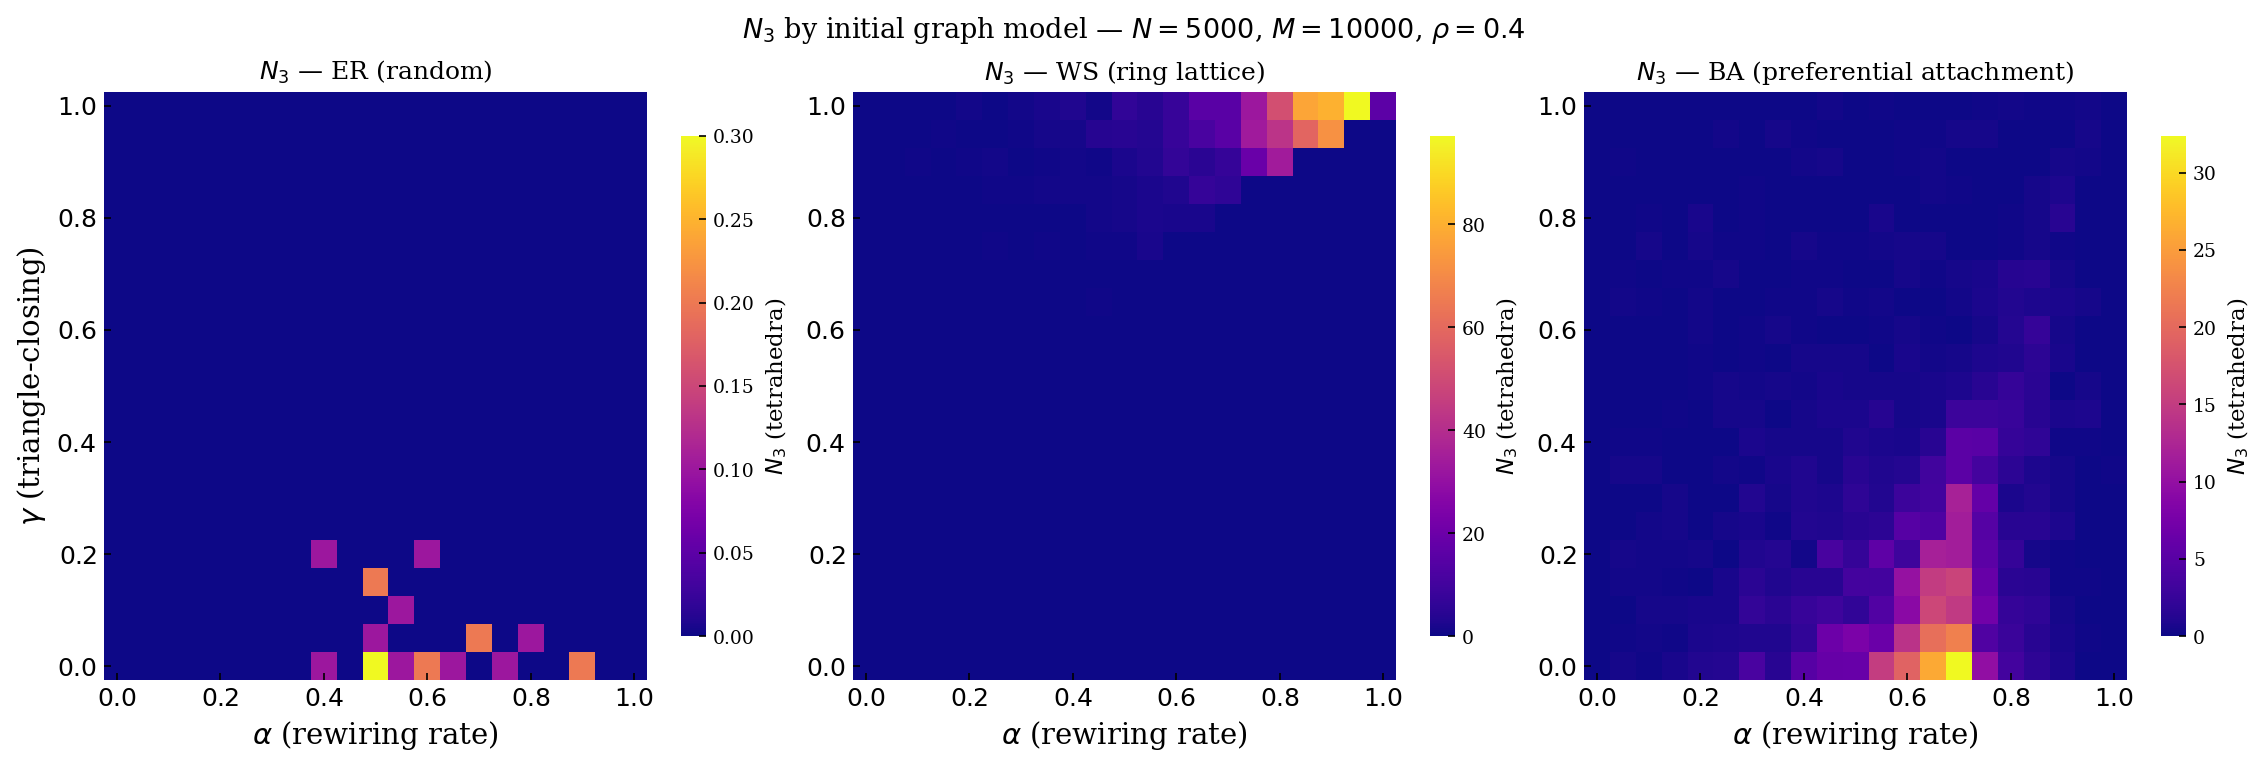

In [ ]:
def plot_beta2_comparison(rho=RHO, save_path=None):

    panels = [
        #('ER (random)', derived_g[rho][r'$N_3$']),
        #('WS (ring lattice)', derived_baws['WS'][r'$N_3$']),
        #('BA (preferential-attachment)', derived_baws['BA'][r'$N_3$']),
        ('ER (random)', derived_g[rho][r'$\beta_2$ (voids)']),
        ('WS (ring lattice)', derived_baws['WS'][r'$\beta_2$ (voids)']),
        ('BA (preferential attachment)', derived_baws['BA'][r'$\beta_2$ (voids)']),
    ]

    # shared colour range so the three models are directly comparable
    all_vals = np.concatenate([d[~np.isnan(d)].ravel() for _, d in panels])
    vmin, vmax = all_vals.min(), all_vals.max()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

    for ax, (model, data) in zip(axes, panels):
        sns.heatmap(
            data,
            ax          = ax,
            cmap        = CMAP,
            #vmin        = vmin,
            #vmax        = vmax,
            mask        = np.isnan(data),
            cbar        = True,
            cbar_kws    = {'label': r'$N_3$ (tetrahedra)', 'shrink': 0.85},
            xticklabels = False,
            yticklabels = False,
            linewidths  = 0,
            rasterized  = True,
        )
        ax.invert_yaxis()
        ax.set_xticks(TICK_IDX + 0.5)
        ax.set_xticklabels(XLABELS, rotation=0)
        ax.set_yticks(TICK_IDX + 0.5)
        ax.set_yticklabels(YLABELS, rotation=0)
        ax.set_xlabel(r'$\alpha$ (rewiring rate)')
        ax.set_ylabel(r'$\gamma$ (triangle-closing)' if ax is axes[0] else '')
        ax.set_title(rf'$N_3$ — {model}', fontsize=12)
        ax.collections[0].colorbar.ax.tick_params(labelsize=9)
        ax.collections[0].colorbar.set_label(r'$N_3$ (tetrahedra)', size=11)

    fig.suptitle(
        rf'$N_3$ by initial graph model'
        rf' — $N = {n}$, $M = {m}$, $\rho = {rho}$',
        fontsize=13,
    )

    plt.show()


plot_beta2_comparison(
    rho       = RHO,
    save_path = os.path.join(
        BASE_GRAPH,
        f'beta2_comparison_n{n}_m{m}_rho{str(RHO).replace(".", "_")}.png'
    )
)

In [ ]:
# =============================================================================
# LOAD TERMINAL PROPORTIONS DIRECTLY FROM RAW FILES
# =============================================================================

term_sums = {
    model: {'minority': np.zeros((ng, na)),
            'discord':  np.zeros((ng, na)),
            'length':   np.zeros((ng, na))}
    for model in MODELS
}
term_counts = {model: np.zeros((ng, na)) for model in MODELS}


def load_terminal_one(model, ai, gi, it):
    path = raw_fname(model, RHO, alphas[ai], gammas[gi], it)
    data = load_raw_graph(path)
    if data is None:
        return None
    try:
        prop     = float(data[0])
        discord  = float(data[1])
        length   = float(data[2])
        minority = min(prop, 1.0 - prop)
        return (model, ai, gi, minority, discord, length)
    except Exception:
        return None


term_jobs = [
    (model, ai, gi, it)
    for model  in MODELS
    for ai     in range(na)
    for gi     in range(ng)
    for it     in iterations
]

print('Loading terminal proportions...')
term_results = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_terminal_one)(model, ai, gi, it)
    for model, ai, gi, it in tqdm(term_jobs, desc='Submitting')
)

for out in tqdm(term_results, desc='Accumulating'):
    if out is None:
        continue
    model, ai, gi, minority, discord, length = out
    term_sums[model]['minority'][gi, ai] += minority
    term_sums[model]['discord'][gi, ai]  += discord
    term_sums[model]['length'][gi, ai]   += length
    term_counts[model][gi, ai]           += 1


# ── means ─────────────────────────────────────────────────────────────────────

term_means = {}
for model in MODELS:
    c = term_counts[model]
    with np.errstate(invalid='ignore', divide='ignore'):
        term_means[model] = {
            r'$\langle \rho_{\min} \rangle$':
                np.where(c > 0, term_sums[model]['minority'] / c, np.nan),
            r'$\langle \rho_{\mathrm{discord}} \rangle$':
                np.where(c > 0, term_sums[model]['discord']  / c, np.nan),
            r'$\langle T \rangle$':
                np.where(c > 0, term_sums[model]['length']   / c, np.nan),
        }

Loading terminal proportions...


Submitting:   0%|          | 0/8820 [00:00<?, ?it/s]

Accumulating:   0%|          | 0/8820 [00:00<?, ?it/s]

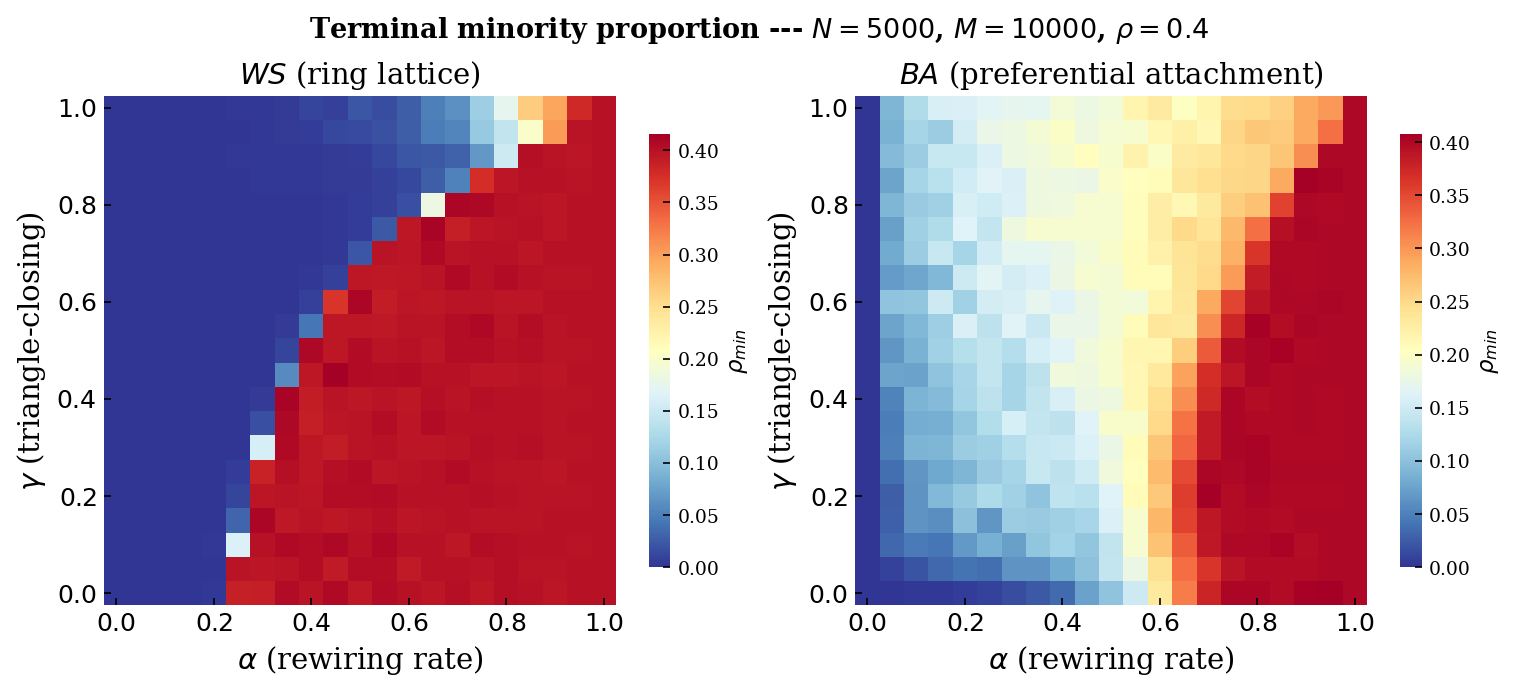

In [ ]:
def plot_terminal_comparison(save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

    for ax, model in zip(axes, ['WS', 'BA']):
        data  = term_means[model][r'$\langle \rho_{\min} \rangle$']
        if model == 'WS':
          label = rf'$WS$ (ring lattice)'
        elif model == 'BA':
          label = rf'$BA$ (preferential attachment)'

        sns.heatmap(
            data,
            ax          = ax,
            cmap        = 'RdYlBu_r',#CMAP,
            mask        = np.isnan(data),
            cbar        = True,
            cbar_kws    = {'label': rf'$\rho_0$', 'shrink': 0.85},
            xticklabels = False,
            yticklabels = False,
            linewidths  = 0,
            rasterized  = True,
        )
        ax.invert_yaxis()
        ax.set_xticks(TICK_IDX + 0.5)
        ax.set_xticklabels(XLABELS, rotation=0)
        ax.set_yticks(TICK_IDX + 0.5)
        ax.set_yticklabels(YLABELS, rotation=0)
        ax.set_xlabel(r'$\alpha$ (rewiring rate)')
        ax.set_ylabel(r'$\gamma$ (triangle-closing)')
        ax.set_title(label)
        ax.collections[0].colorbar.ax.tick_params(labelsize=9)
        ax.collections[0].colorbar.set_label(rf'$\rho_{{min}}$', size=11)

    fig.suptitle(
        rf'Terminal minority proportion'
        rf' --- $N = {n}$, $M = {m}$, $\rho = {RHO}$',
        fontsize=13, fontweight='bold',
    )


plot_terminal_comparison(
    save_path=os.path.join(
        BASE_GRAPH,
        f'terminal_minority_WS_BA_n{n}_m{m}_rho{str(RHO).replace(".", "_")}.png'
    )
)

In [ ]:
nodes = range(n)
E = [tuple(sorted([(v+i) % n for i in range(K)])) for v in nodes]
for v in nodes:
    for size in range(2,K):
        for comb in combinations(range(v+1,v+K),size-1):
            if random.random() < p:
                E.append(tuple(sorted([v]+[u % n for u in comb])))

Edges = set()
Edges.update(E)
H = {i: e for i, e in enumerate(E)}

In [ ]:
def HG_RewireTriangleSame_Voter(H, alpha, rho, gamma, voting='Majority',
                                  exit_criteria=np.inf, timing=False):
    """
    Hypergraph voter model combining structure-aware transitivity enforcement
    with opinion-aware rewire-to-same as fallback.

    With probability alpha, rewiring occurs:
      - With probability gamma: a triangle-closing swap is attempted,
        selecting nodes purely on structural grounds (no opinion filtering).
        If no valid triangle swap exists, falls back to rewire-to-same.
      - With probability 1-gamma (or on triangle failure): rewire-to-same
        is used, swapping minority-opinion nodes between edges of opposite
        majority to drive consensus.
    With probability 1-alpha, social influence is applied.
    """
    vote_function = majority_vote if voting == 'Majority' else proportional_vote

    if timing:
        print("Initializing hypergraph, variables and data structures", flush=True)
        start = time.time()

    V = set(v for e in H for v in H[e])
    E = list(H.keys())

    N = {v: set() for v in V}
    for e in H:
        for v in H[e]:
            N[v].add(e)

    Opinions = set(np.random.choice(list(V), size=round(rho * len(V)), replace=False))
    Opinions = {v: 1 if v in Opinions else 0 for v in V}

    Count = {e: sum(Opinions[v] for v in H[e]) for e in H}

    def edge_majority(e):
        c = Count[e]; s = len(H[e])
        if c * 2 > s: return 1
        if c * 2 < s: return 0
        return -1

    # --- O(1) stratified discordant structure ---
    Strat      = {0: [], 1: [], -1: []}
    StratIndex = {0: {}, 1: {}, -1: {}}

    DiscordantEdges = [e for e in H if 0 < Count[e] < len(H[e])]
    DiscordantIndex = {edge_id: pos for pos, edge_id in enumerate(DiscordantEdges)}

    for e in DiscordantEdges:
        k = edge_majority(e)
        StratIndex[k][e] = len(Strat[k])
        Strat[k].append(e)

    def _strat_add(e, k):
        StratIndex[k][e] = len(Strat[k])
        Strat[k].append(e)

    def _strat_remove(e, k):
        if e not in StratIndex[k]:
            return
        pos = StratIndex[k].pop(e)
        if pos < len(Strat[k]) - 1:
            last = Strat[k][-1]
            Strat[k][pos] = last
            StratIndex[k][last] = pos
        Strat[k].pop()

    def add_discordant_strat(e):
        add_discordant(e, DiscordantIndex, DiscordantEdges)
        _strat_add(e, edge_majority(e))

    def remove_discordant_strat(e):
        _strat_remove(e, edge_majority(e))
        remove_discordant(e, DiscordantIndex, DiscordantEdges)

    def update_strat(e, old_count):
        old_size = len(H[e])
        if old_count * 2 > old_size:   old_k = 1
        elif old_count * 2 < old_size: old_k = 0
        else:                          old_k = -1
        new_k = edge_majority(e)
        if old_k != new_k:
            _strat_remove(e, old_k)
            _strat_add(e, new_k)

    def sample_opposite(majority, exclude_id):
        """O(1) uniform sample from edges with opposite majority."""
        opposite = 1 - majority
        n_opp    = len(Strat[opposite])
        n_tied   = len(Strat[-1])
        total    = n_opp + n_tied
        if total == 0:
            return None
        if total == 1:
            candidate = Strat[opposite][0] if n_opp == 1 else Strat[-1][0]
            return candidate if candidate != exclude_id else None
        stuckcounter = 0
        while True:
            stuckcounter += 1;
            if stuckcounter > 1000:
                print("Broken")
            idx = np.random.randint(total)
            if idx < n_opp:
                candidate = Strat[opposite][idx]
            else:
                candidate = Strat[-1][idx - n_opp]
            if candidate != exclude_id:
                return candidate

    def apply_swap(edge_id, sourceNode_id, sourceNode,
                   targetEdge_id, targetNode_id, targetNode):
        """
        Perform node swap between edge_id and targetEdge_id,
        updating H, Count, Strat and N.
        """
        old_count_source = Count[edge_id]
        old_count_target = Count[targetEdge_id]

        # Update source edge
        new_sourceEdge                = list(H[edge_id])
        new_sourceEdge[sourceNode_id] = targetNode
        H[edge_id]                    = sorted(new_sourceEdge)
        new_source_count              = (old_count_source
                                         + Opinions[targetNode]
                                         - Opinions[sourceNode])

        if new_source_count == 0 or new_source_count == len(H[edge_id]):
            remove_discordant_strat(edge_id)
            Count[edge_id] = new_source_count
        else:
            Count[edge_id] = new_source_count
            update_strat(edge_id, old_count_source)

        # Update target edge
        new_targetEdge                = list(H[targetEdge_id])
        new_targetEdge[targetNode_id] = sourceNode
        H[targetEdge_id]              = sorted(new_targetEdge)
        new_target_count              = (old_count_target
                                         + Opinions[sourceNode]
                                         - Opinions[targetNode])

        was_concordant = (old_count_target == 0
                          or old_count_target == len(H[targetEdge_id]))
        now_concordant = (new_target_count == 0
                          or new_target_count == len(H[targetEdge_id]))

        if was_concordant and not now_concordant:
            Count[targetEdge_id] = new_target_count
            add_discordant_strat(targetEdge_id)
        elif not was_concordant and now_concordant:
            remove_discordant_strat(targetEdge_id)
            Count[targetEdge_id] = new_target_count
        else:
            Count[targetEdge_id] = new_target_count
            update_strat(targetEdge_id, old_count_target)

        # Update node neighbourhoods
        N[sourceNode].discard(edge_id)
        N[sourceNode].add(targetEdge_id)
        N[targetNode].add(edge_id)
        N[targetNode].discard(targetEdge_id)

    #Proportions      = [sum(Opinions.values()) / len(V)]
    #DiscordantCounts = [len(DiscordantEdges) / len(E)]
    timer = 0

    if timing:
        end = time.time()
        print("Initialization complete, time taken: " + str(end - start) + " seconds",
              flush=True)
        print("Beginning network evolution", flush=True)
        start = time.time()

    while len(DiscordantEdges) > 0 and timer < exit_criteria:
        timer += 1
        #Proportions.append(Proportions[-1])

        edgeChoice = np.random.randint(len(DiscordantEdges))
        edge_id    = DiscordantEdges[edgeChoice]
        edge       = H[edge_id]

        Majority = edge_majority(edge_id)
        if Majority == -1:
            Majority = np.random.randint(2)
        Minority = 1 - Majority

        if random.random() < alpha:

            found = False

            # --- Triangle branch (structure-aware, no opinion filtering) ---
            if random.random() < gamma:

                # sourceNode selected purely at random — no opinion constraint
                sourceNode_id = np.random.randint(len(edge))
                sourceNode    = edge[sourceNode_id]

                # Build neighbourhood-of-neighbourhood structure
                Neighbors = set(
                    v for e in N[sourceNode]
                    if e != edge_id
                    for v in H[e]
                    if v != sourceNode
                )
                NeighborEdges = set(
                    e for v in Neighbors
                    for e in N[v]
                    if e not in N[sourceNode]
                )
                NofNs = list(set(
                    v for e in NeighborEdges
                    for v in H[e]
                    if v not in Neighbors and v != sourceNode
                ))

                while NofNs and not found:
                    middleNode_id = np.random.randint(len(NofNs))
                    middleNode    = NofNs[middleNode_id]

                    temp = []; counter = 0
                    for e in N[middleNode]:
                        if e in NeighborEdges:
                            counter += 1
                        else:
                            temp.append(e)
                    cands = list(N[middleNode]) if counter > 1 else temp

                    while cands:
                        cand_idx     = np.random.randint(len(cands))
                        cand_edge_id = cands[cand_idx]
                        cand_edge    = H[cand_edge_id]

                        # Structural validity only: target node must not
                        # already be in source edge, and sourceNode must
                        # not already be in the target edge
                        valid_nodes = [
                            (i, v) for i, v in enumerate(cand_edge)
                            if v != middleNode
                            and v not in edge
                            and sourceNode not in cand_edge
                        ]

                        if valid_nodes:
                            targetEdge_id            = cand_edge_id
                            targetNode_id, targetNode = random.choice(valid_nodes)
                            found = True
                            break
                        else:
                            cands[cand_idx] = cands[-1]
                            cands.pop()

                    if found:
                        break
                    NofNs[middleNode_id] = NofNs[-1]
                    NofNs.pop()

            # --- Fallback: rewire-to-same (opinion-aware) ---
            if not found:
                targetEdge_id = sample_opposite(Majority, edge_id)
                if targetEdge_id is None:
                    #DiscordantCounts.append(len(DiscordantEdges) / len(E))
                    if alpha == 1.0:
                        return  sum(Opinions.values()) / len(V), len(DiscordantEdges) / len(E), timer, H
                        #return np.array(Proportions), np.array(DiscordantCounts), H
                    continue

                targetEdge = H[targetEdge_id]

                # Opinion-aware node selection
                source_minority_ids = [
                    i for i, v in enumerate(edge)
                    if Opinions[v] == Minority and v not in targetEdge
                ]
                target_minority_ids = [
                    i for i, v in enumerate(targetEdge)
                    if Opinions[v] == Majority and v not in edge
                ]

                if not source_minority_ids or not target_minority_ids:
                    #DiscordantCounts.append(len(DiscordantEdges) / len(E))
                    continue

                sourceNode_id = random.choice(source_minority_ids)
                sourceNode    = edge[sourceNode_id]
                targetNode_id = random.choice(target_minority_ids)
                targetNode    = H[targetEdge_id][targetNode_id]

                if targetNode == sourceNode:
                    #DiscordantCounts.append(len(DiscordantEdges) / len(E))
                    continue

            apply_swap(edge_id, sourceNode_id, sourceNode,
                       targetEdge_id, targetNode_id, targetNode)

        else:
            # --- Social influence ---
            edge_list   = list(H[edge_id])
            Majority_si = vote_function(Count[edge_id] / len(edge_list))

            changed = []
            for v in edge_list:
                if Opinions[v] != Majority_si:
                    Opinions[v] = Majority_si
                    changed.append(v)

            #Proportions[timer] += (
            #    len(changed) / len(V) if Majority_si == 1
            #    else -len(changed) / len(V)
            #)
            remove_discordant_strat(edge_id)
            Count[edge_id] = Majority_si * len(H[edge_id])

            delta = 1 if Majority_si == 1 else -1
            for v in changed:
                for e in N[v]:
                    if e == edge_id:
                        continue
                    old_count_e    = Count[e]
                    was_concordant = (old_count_e == 0
                                      or old_count_e == len(H[e]))
                    new_count_e    = Count[e] + delta
                    now_concordant = (new_count_e == 0
                                      or new_count_e == len(H[e]))

                    if was_concordant and not now_concordant:
                        Count[e] = new_count_e
                        add_discordant_strat(e)
                    elif not was_concordant and now_concordant:
                        remove_discordant_strat(e)
                        Count[e] = new_count_e
                    else:
                        Count[e] = new_count_e
                        update_strat(e, old_count_e)

        #DiscordantCounts.append(len(DiscordantEdges) / len(E))

    if timing:
        end = time.time()
        print("Evolution complete, time taken: " + str(end - start) + " seconds",
              flush=True)

    return  sum(Opinions.values()) / len(V), len(DiscordantEdges) / len(E), timer, H
    #return np.array(Proportions), np.array(DiscordantCounts), H

In [ ]:
def PC_Simplicial(params):
  """
  Parallel function which is iteratively called,
  looping over a set of parameters, with the current
  iteration of parameters being params.
  """
  # Grab parameter values from params list
  n = params[0]; k = params[1]; rho = params[2]; alpha = params[3]; gamma = params[4]; voting = params[5]; iteration = params[6]; p = params[7]
  # Create filename from params
  filename =  '/content/drive/My Drive/Colab Notebooks/Voter/Simplicial/WS_Simplicial_'+str(n)+'_'+str(k)+'_'+str(rho).replace('.','_')+'_'+str(alpha).replace('.','_')+'_'+str(gamma).replace('.','_')+'_'+str(p).replace('.','_')+'_'+voting+'_'+str(iteration)+'.pkl'
  if os.path.isfile(filename):
    return 0

  nodes = range(n)
  E = [tuple(sorted([(v+i) % n for i in range(k)])) for v in nodes]
  for v in nodes:
    for size in range(2,k):
        for comb in combinations(range(v+1,v+k),size-1):
            if random.random() < p:
                E.append(tuple(sorted([v]+[u % n for u in comb])))

  H = {i: e for i, e in enumerate(E)}

  Proportion, DiscordantCount, timer, H = HG_RewireTriangleSame_Voter(H, alpha, rho, gamma, voting=voting, exit_criteria=10000000)
  data = [Proportion, DiscordantCount, timer, H]

  # Pickle and save the output
  with gzip.open(filename,'wb') as f:
    pickle.dump(data, f);
  return 0


N = [500]; K = [3,4]; rhos = [0.4]; alphas = np.linspace(0,1,11)[1:]; gammas = np.linspace(0,1,11); voting=['Majority']; iterations = range(1,6); P = [0.5]
params = [N, K, rhos, alphas, gammas, voting, iterations, P]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(PC_Simplicial)(param) for param in tqdm(params))

  0%|          | 0/1100 [00:00<?, ?it/s]

Computing:   0%|          | 0/6600 [00:00<?, ?it/s]

Loading:   0%|          | 0/6600 [00:00<?, ?it/s]

Accumulating:   0%|          | 0/6600 [00:00<?, ?it/s]

Saved: /content/drive/My Drive/Colab Notebooks/Voter/Simplicial/proc/heatmap_simp_WS_K3_psub0_4.png


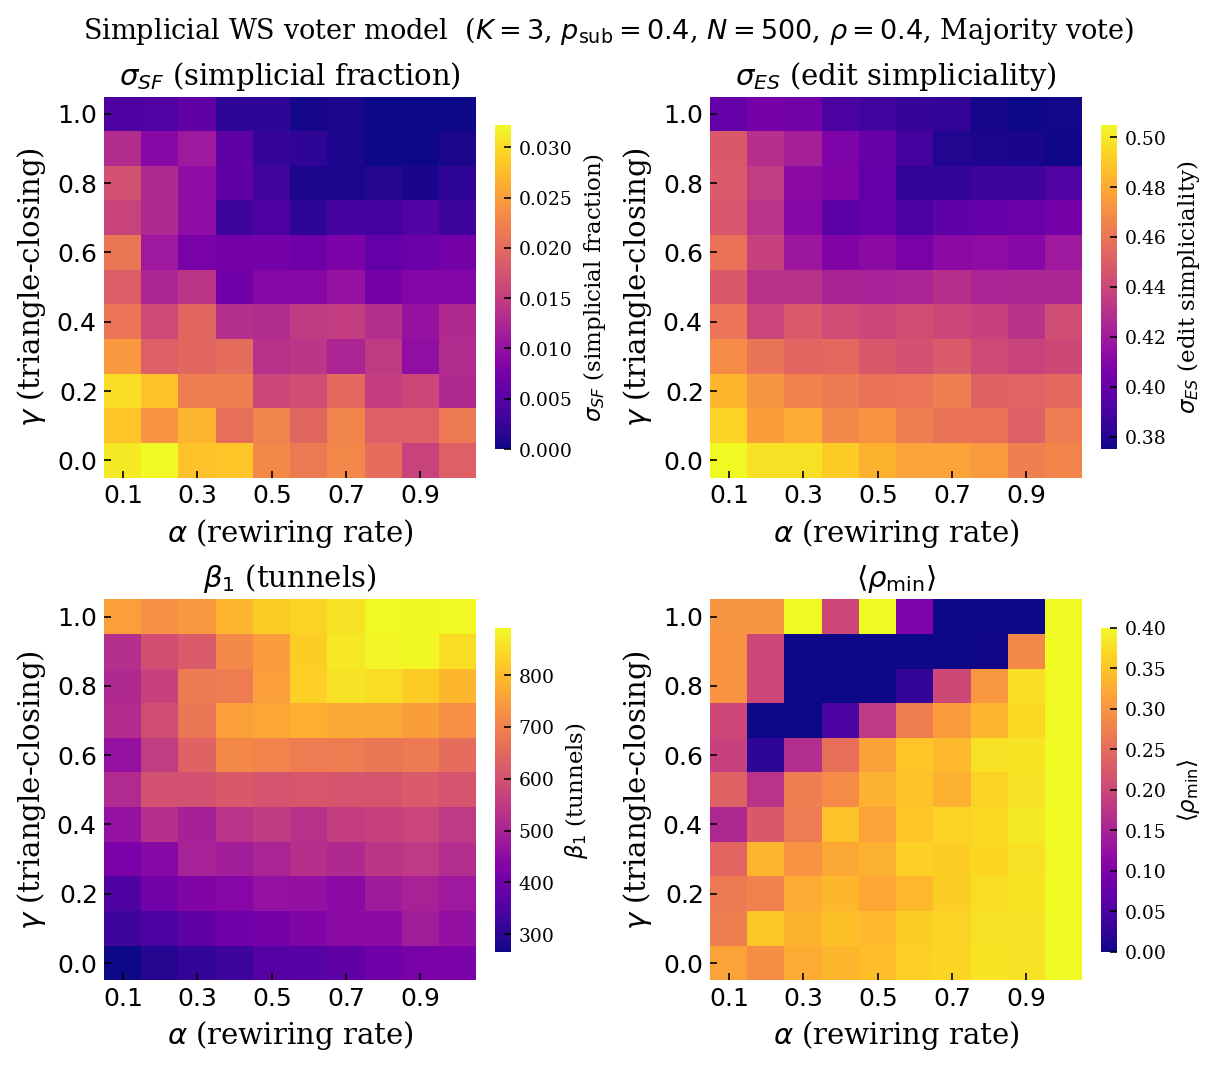

Saved: /content/drive/My Drive/Colab Notebooks/Voter/Simplicial/proc/heatmap_simp_WS_K3_psub0_5.png


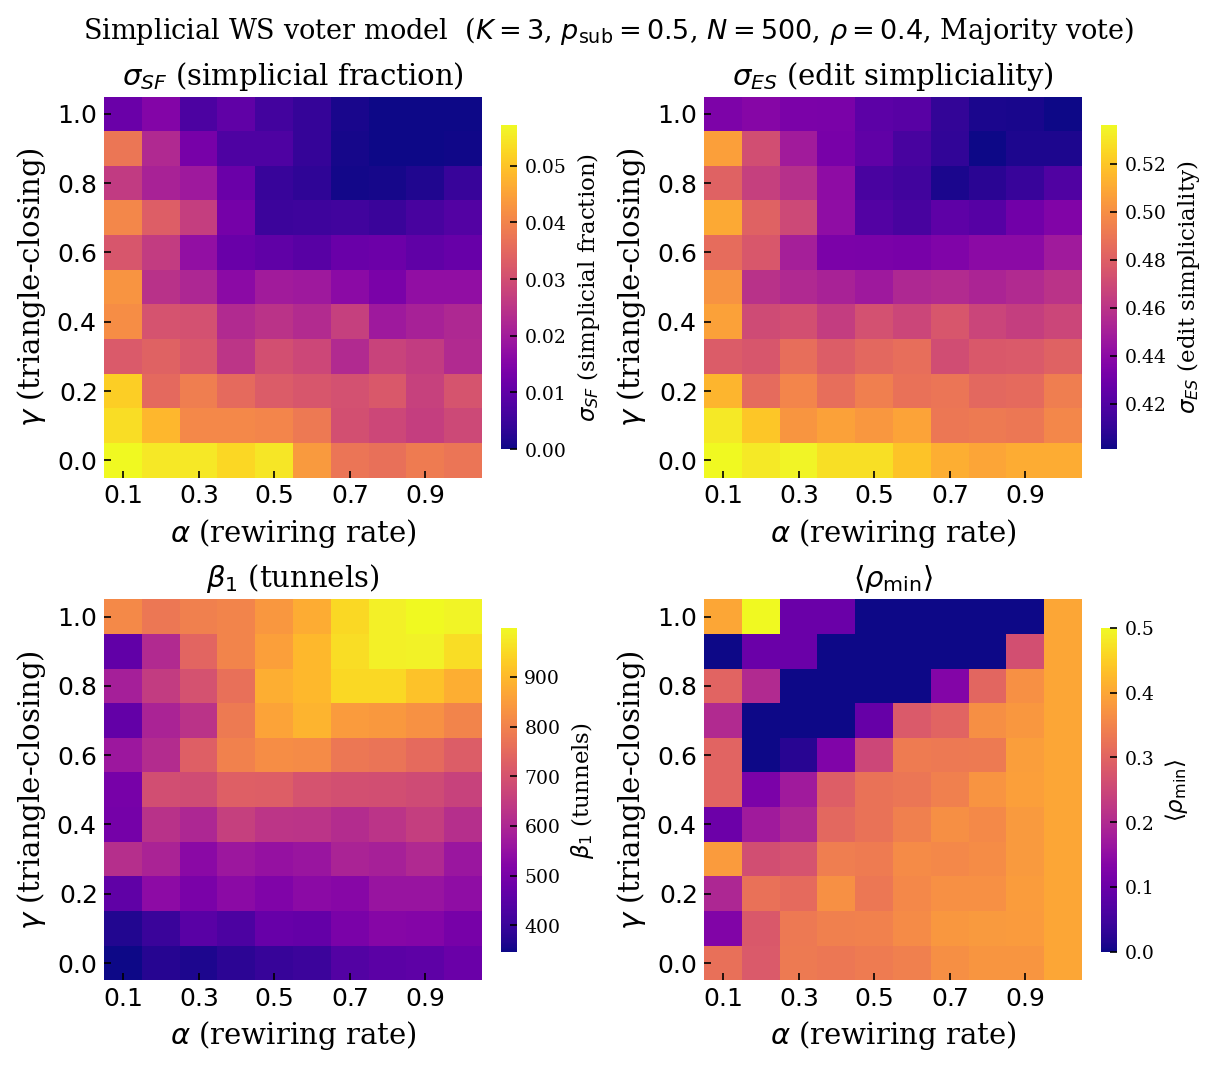

Saved: /content/drive/My Drive/Colab Notebooks/Voter/Simplicial/proc/heatmap_simp_WS_K3_psub0_6.png


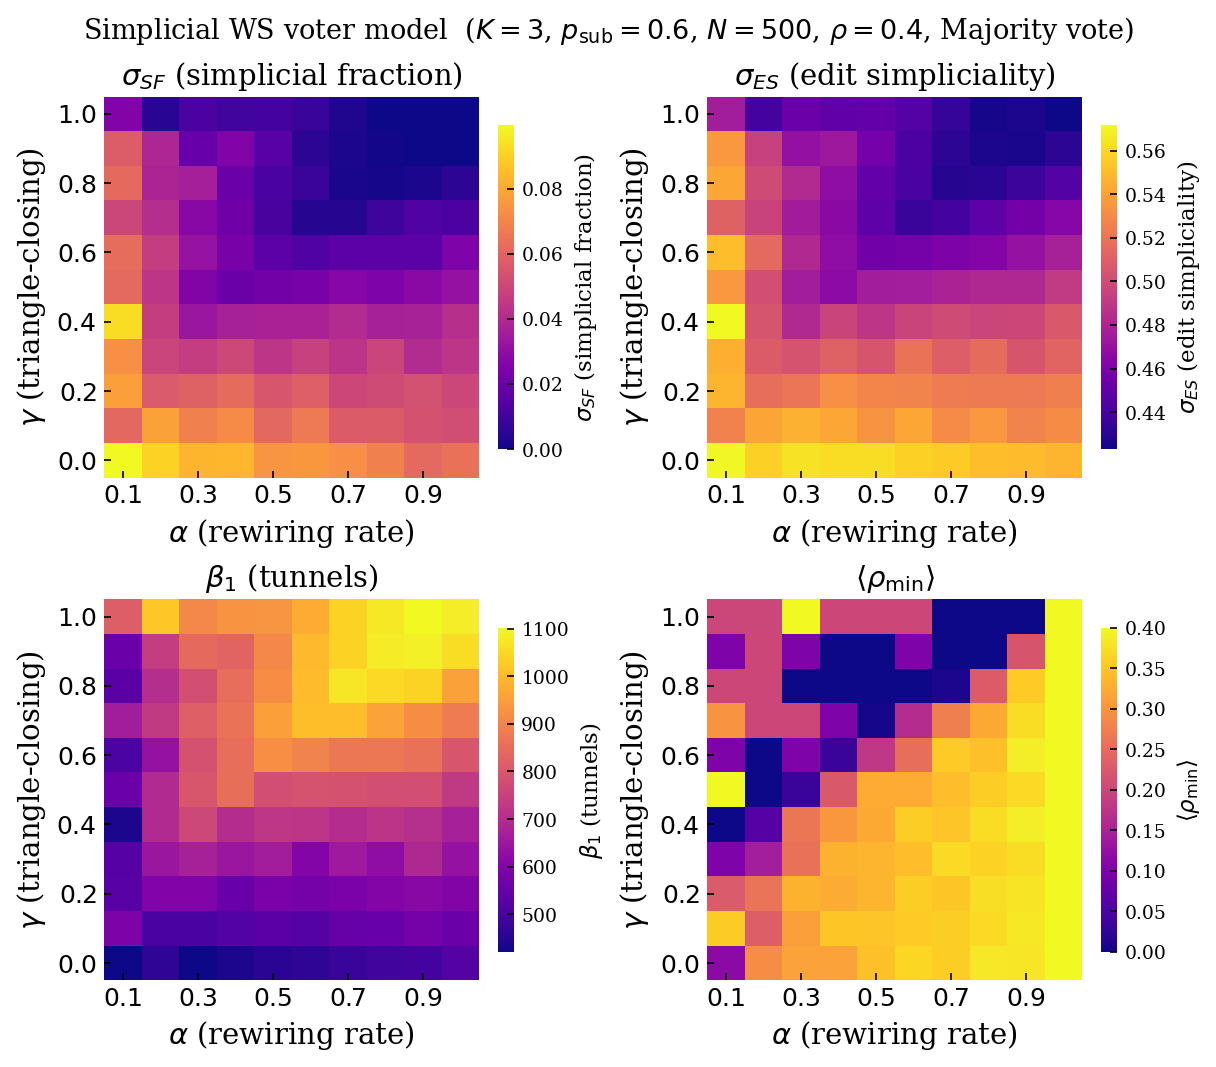

Saved: /content/drive/My Drive/Colab Notebooks/Voter/Simplicial/proc/heatmap_simp_WS_K4_psub0_4.png


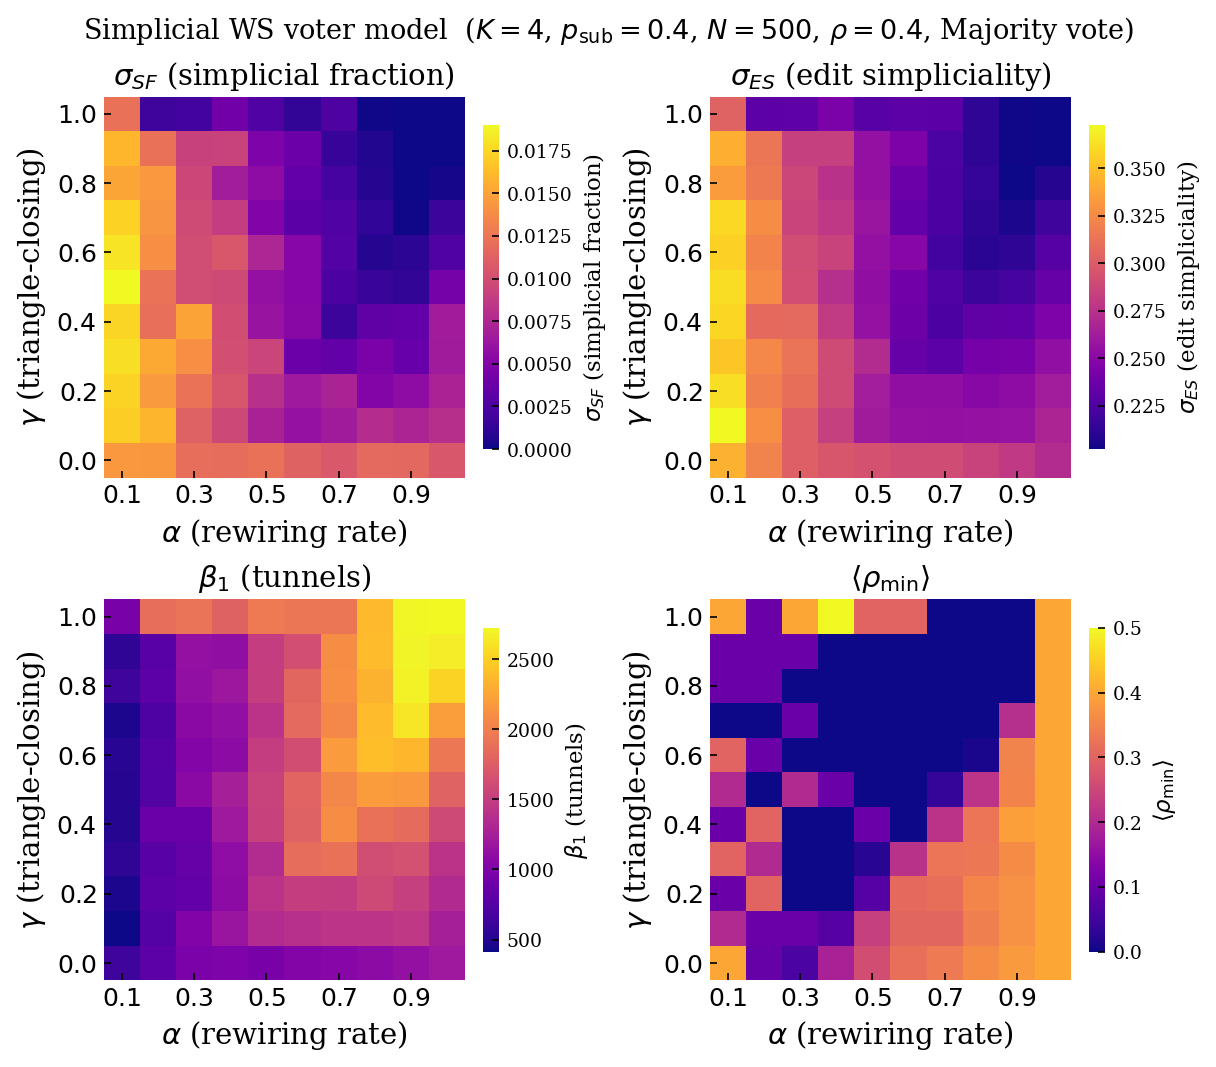

Saved: /content/drive/My Drive/Colab Notebooks/Voter/Simplicial/proc/heatmap_simp_WS_K4_psub0_5.png


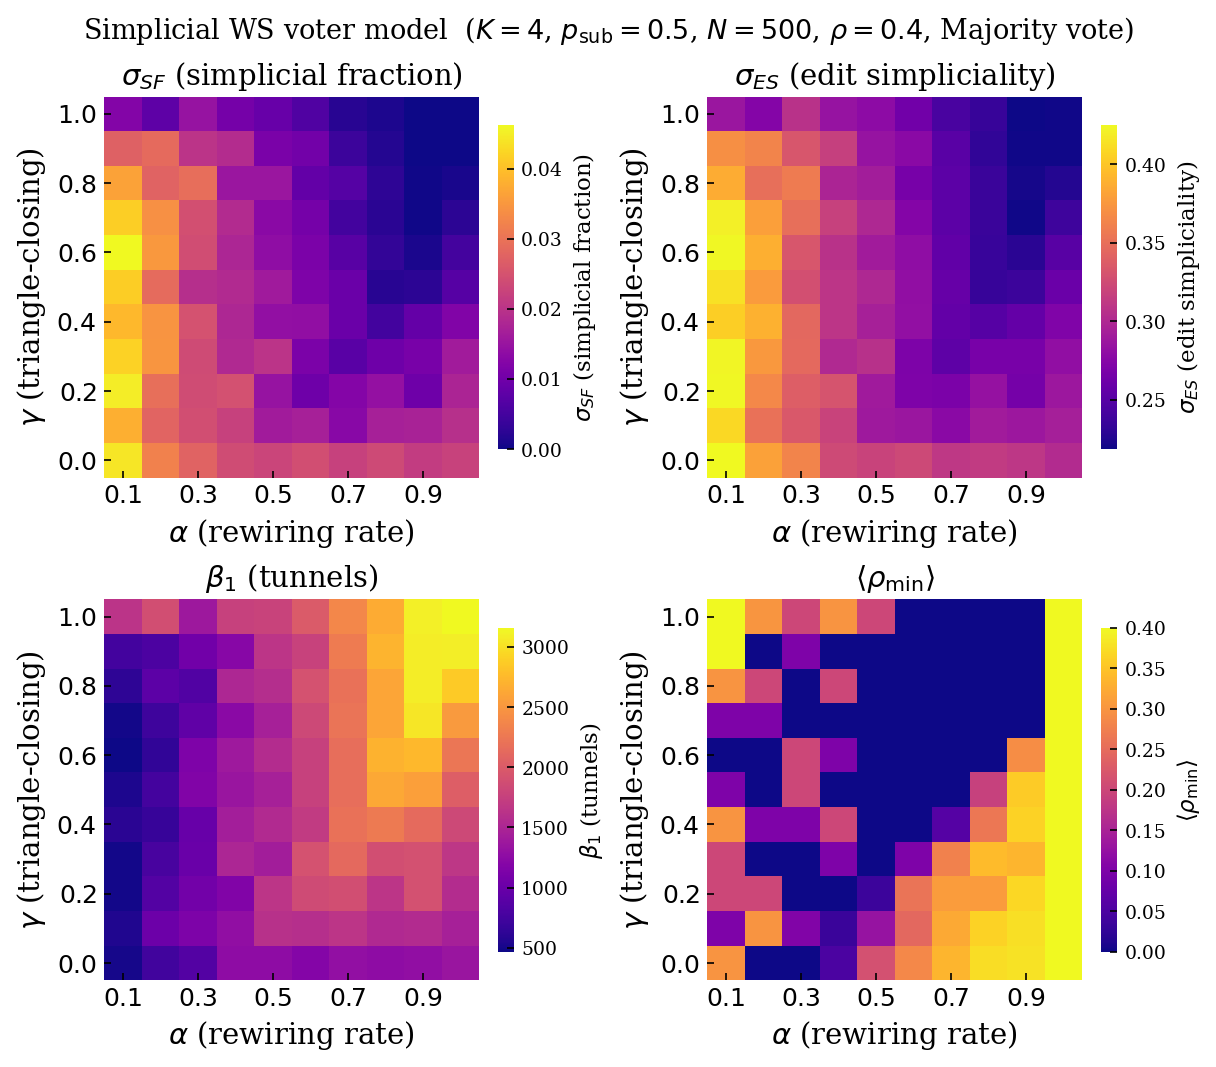

Saved: /content/drive/My Drive/Colab Notebooks/Voter/Simplicial/proc/heatmap_simp_WS_K4_psub0_6.png


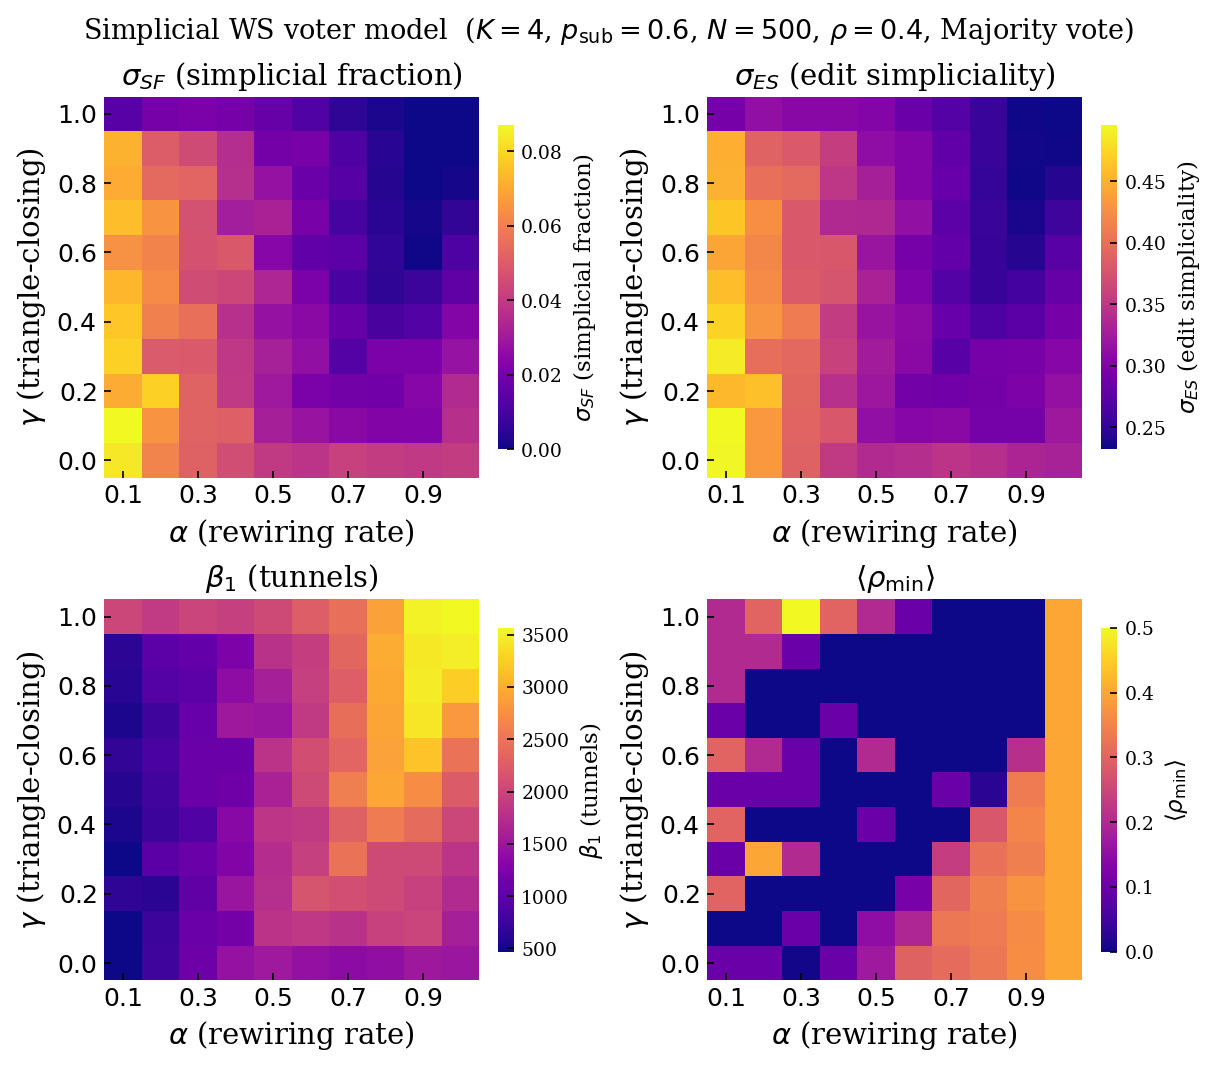

In [ ]:
# =============================================================================
# 1. CONFIGURATION
# =============================================================================

plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         13,
    'axes.labelsize':    14,
    'axes.titlesize':    14,
    'legend.fontsize':   13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
    'axes.grid':         False,
    'grid.linewidth':    0.4
})
CMAP = 'plasma'

BASE_S  = '/content/drive/My Drive/Colab Notebooks/Voter/Simplicial/'
PROC_S  = os.path.join(BASE_S, 'proc')
os.makedirs(PROC_S, exist_ok=True)

n        = 500
K_vals   = [3, 4]
rho      = 0.4
alphas   = np.linspace(0, 1, 11)[1:]   # 10 values: 0.1 … 1.0
gammas   = np.linspace(0, 1, 11)       # 11 values: 0.0 … 1.0
voting   = 'Majority'
iterations = range(1, 11)
P_SUBS = [0.4, 0.5, 0.6]
na, ng   = len(alphas), len(gammas)

TICK_A   = np.arange(0, na, 2)
TICK_G   = np.arange(0, ng, 2)
XLABELS  = [f'${alphas[i]:.1f}$' for i in TICK_A]
YLABELS  = [f'${gammas[i]:.1f}$' for i in TICK_G]

fields   = ['b0', 'b1', 'b2', 'euler', 'N0', 'N1', 'N2', 'N3', 'sf', 'es', 'proportion']

# =============================================================================
# 2. FILENAME HELPERS — psub added to both functions
# =============================================================================

def raw_fname(k, psub, alpha, gamma, it):
    return os.path.join(BASE_S,
        f'WS_Simplicial_{n}_{k}_'
        f'{str(rho).replace(".","_")}_'
        f'{str(alpha).replace(".","_")}_'
        f'{str(gamma).replace(".","_")}_'
        f'{str(psub).replace(".","_")}_'
        f'{voting}_{it}.pkl')

def proc_fname(k, psub, ai, gi, it):
    return os.path.join(PROC_S,
        f'proc_{n}_{k}_psub{str(psub).replace(".","_")}_'
        f'a{ai}_g{gi}_it{it}.pkl.gz')


# =============================================================================
# 3. ACCUMULATORS — keyed by (k, psub)
# =============================================================================

sums   = {(k, p): {fld: np.zeros((ng, na)) for fld in fields}
          for k in K_vals for p in P_SUBS}
counts = {(k, p): np.zeros((ng, na))
          for k in K_vals for p in P_SUBS}


# =============================================================================
# 4. JOB LIST — psub added as second element
# =============================================================================

all_jobs = [
    (k, p, ai, gi, it)
    for k  in K_vals
    for p  in P_SUBS
    for ai in range(na)
    for gi in range(ng)
    for it in iterations
]


# =============================================================================
# 5. COMPUTE — psub threaded through
# =============================================================================

def compute_and_save(k, psub, ai, gi, it):
    pfname = proc_fname(k, psub, ai, gi, it)
    if os.path.isfile(pfname):
        return 'exists'
    rpath = raw_fname(k, psub, alphas[ai], gammas[gi], it)
    if not os.path.isfile(rpath):
        return 'missing'
    try:
        with gzip.open(rpath, 'rb') as f:
            data = pickle.load(f)
        proportion = float(data[0])
        H          = data[3]
        tda        = ComputeHGResults(H)
        cnts       = tda[4] if tda[4] is not None else []
        sf         = float(Get_Simpliciality_SF(H, minDim=2, maxDim=np.inf)[0])
        es         = float(Get_Simpliciality_ES(H, minDim=2, maxDim=np.inf))
        out = {
            'proportion': proportion,
            'b0': tda[0], 'b1': tda[1], 'b2': tda[2], 'euler': tda[3],
            'N0': cnts[0] if len(cnts) > 0 else 0,
            'N1': cnts[1] if len(cnts) > 1 else 0,
            'N2': cnts[2] if len(cnts) > 2 else 0,
            'N3': cnts[3] if len(cnts) > 3 else 0,
            'sf': sf,
            'es': es
        }
        with gzip.open(pfname, 'wb') as f:
            pickle.dump(out, f)
        return 'done'
    except Exception as e:
        return f'error: {e}'

Parallel(n_jobs=-1, backend='loky')(
    delayed(compute_and_save)(k, p, ai, gi, it)
    for k, p, ai, gi, it in tqdm(all_jobs, desc='Computing')
)


# =============================================================================
# 6. LOAD — psub in signature and return tuple
# =============================================================================

def load_one(k, psub, ai, gi, it):
    pfname = proc_fname(k, psub, ai, gi, it)
    if not os.path.isfile(pfname):
        return None
    try:
        with gzip.open(pfname, 'rb') as f:
            res = pickle.load(f)
        return (k, psub, ai, gi, res)
    except Exception:
        return None

loaded = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_one)(k, p, ai, gi, it)
    for k, p, ai, gi, it in tqdm(all_jobs, desc='Loading')
)

for out in tqdm(loaded, desc='Accumulating'):
    if out is None:
        continue
    k, psub, ai, gi, res = out
    for fld in fields:
        sums[(k, psub)][fld][gi, ai] += res[fld]
    counts[(k, psub)][gi, ai] += 1


# =============================================================================
# 7. DERIVED QUANTITIES — keyed by (k, psub)
# =============================================================================

def smean(k, psub, fld):
    c = counts[(k, psub)]
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(c > 0, sums[(k, psub)][fld] / c, np.nan)

derived = {}
for k in K_vals:
    for psub in P_SUBS:
        b0  = smean(k, psub, 'b0');  b1  = smean(k, psub, 'b1')
        b2  = smean(k, psub, 'b2');  N0  = smean(k, psub, 'N0')
        N1  = smean(k, psub, 'N1');  N2  = smean(k, psub, 'N2')
        N3  = smean(k, psub, 'N3');  sf  = smean(k, psub, 'sf')
        prop = smean(k, psub, 'proportion'); es = smean(k, psub, 'es')
        with np.errstate(invalid='ignore', divide='ignore'):
            CR1   = N1 - N0 + b0
            CR1b1 = CR1 - b1
            g1    = np.where(N2 > 0, CR1b1 / N2, np.nan)
            minority = np.minimum(prop, 1.0 - prop)
        derived[(k, psub)] = {
            r'$\sigma_{SF}$ (simplicial fraction)':                  sf,
            r'$\sigma_{ES}$ (edit simpliciality)':                  es,
            r'$\beta_1$ (tunnels)':                      b1,
            #r'$\beta_2$':                      b2,
            #r'$N_2$':                          N2,
            #r'$\mathcal{CR}_1 - \beta_1$':    CR1b1,
            #r'$\gamma_1$':                     g1,
            r'$\langle\rho_{\min}\rangle$':   minority,
        }

# =============================================================================
# 8. PLOT — iterate over (k, psub) pairs
# =============================================================================

def plot_simp_heatmaps(k, psub, save_path=None):
    panels   = list(derived[(k, psub)].items())
    n_panels = len(panels)
    n_cols, n_rows = 2, (n_panels + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(8, 3.5 * n_rows),
                             constrained_layout=True)
    for ax, (label, data) in zip(axes.flatten(), panels):
        sns.heatmap(data, ax=ax, cmap=CMAP, mask=np.isnan(data),
                    cbar=True, cbar_kws={'label': label, 'shrink': 0.85},
                    xticklabels=False, yticklabels=False,
                    linewidths=0, rasterized=True)
        ax.invert_yaxis()
        ax.set_xticks(TICK_A + 0.5); ax.set_xticklabels(XLABELS, rotation=0)
        ax.set_yticks(TICK_G + 0.5); ax.set_yticklabels(YLABELS, rotation=0)
        ax.set_xlabel(r'$\alpha$ (rewiring rate)')
        ax.set_ylabel(r'$\gamma$ (triangle-closing)')
        ax.set_title(label)
        ax.collections[0].colorbar.ax.tick_params(labelsize=9)
        ax.collections[0].colorbar.set_label(label, size=11)
    for ax in axes.flatten()[n_panels:]:
        ax.set_visible(False)
    fig.suptitle(
        rf'Simplicial WS voter model  ($K={k}$, $p_{{\mathrm{{sub}}}}={psub}$,'
        rf' $N={n}$, $\rho={rho}$, Majority vote)',
        fontsize=13)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


for k in K_vals:
    for psub in P_SUBS:
        plot_simp_heatmaps(
            k=k, psub=psub,
            save_path=os.path.join(
                PROC_S,
                f'heatmap_simp_WS_K{k}_psub{str(psub).replace(".","_")}.png'
            )
        )

In [ ]:
def Get_Simpliciality_SF(filename, processed_filename = None, minDim = 2, maxDim = np.inf):
  """
  Input: filename = string file name to load hypergraph
         processed_filename = string file name to save data to
         minDim = minimum simplex size to consider. Simplices below this
                  dimension are disregarded. Simplices equal to this dimension
                  are automatically downward closed and now counted.
         maxDim = maximum simplex dimension to consider. Used to
                  reduce computational complexity for large hypergraphs
                  with high cardinality edges.
  Return: SimplicialFraction = ratio of downward-closed hyperedges to
                               the total number of hyperedges
          Lengths = dictionary keeping track of the number of simplices of
                    each dimension which are downward closed.
  Description: To compute the simplicial fraction we take a dynamic
  programming approach. We first sort the edges by ascending length.
  Then, to check if a simplex e is downward closed it is sufficient to
  check if its |e|-1 sized subsets belong to H and are downward closed.
  """
  if type(filename) == dict:
    H = filename
  else:
    # Load data from input filename
    with gzip.open(filename, 'rb') as f:
      try:
        with gzip.open(filename, 'rb') as f:
          H = pickle.load(f)
      except Exception as e:
        print(f"Error loading file: {filename}")
        return -1

  # Create a list of (key, set) tuples sorted by ascending set length
  sorted_items = sorted(H.items(), key=lambda item: len(item[1]), reverse=False)

  # Create a new dictionary with keys 0, 1, 2, ... corresponding to sorted sets
  H = {i: tuple(sorted(item[1])) for i, item in enumerate(sorted_items)}

  # Initialize dict that keeps track of edges in H, as well as whether
  # or not they are downward closed (True or False).
  IsSimplex = {e: True for e in H.values()}

  # Keep track of nodes which are downward closed and total number of
  # hyperedges with |e| > minDim (respectively)
  SimplexCount = 0
  CandidateCount = 0
  E = set()

  # Each timestep represents the addition of a single hyperedge
  for t in tqdm(range(len(H))):
    # To reduce memory overusage we cleanup every so often
    if t > 0 and t % 500000 == 0:
      gc.collect()

    # If the hyperedge is below the minimum size we discard it from consideration.
    # If hyperedge is at minimum size it is automatically a simplex, and so it is
    # disregarded from simpliciality computation
    e = H[t]

    if (len(e) <= minDim) or (len(e) > maxDim) or (e in E):
      continue

    # By default increase simplex and candidate counts by 1.
    SimplexCount += 1; CandidateCount += 1;
    E.add(e)

    # Iterate over the subsets of e of size |e|-1. e is downward closed
    # iff its |e|-1 subsets belong to the hypergraph, and are all downward
    # closed themselves.
    for face in combinations(e, len(e)-1):
      if (face not in IsSimplex) or (not IsSimplex[face]):
        # Since a subset is not a simplex, e is not a simplex
        IsSimplex[e] = False; SimplexCount -= 1
        break

  # Record simplicial fraction, as well as get a dictionary which
  # records the number of edges of each size which are downward closed.
  SimplicialFraction = SimplexCount / CandidateCount
  Lengths = [len(e) for e in IsSimplex if (IsSimplex[e] and len(e) > minDim and len(e) <= maxDim)]
  Lengths = collections.Counter(Lengths)

  # Pickle and save the output
  Data = [SimplicialFraction, Lengths]
  if processed_filename != None:
    with gzip.open(processed_filename, 'wb') as f:
      pickle.dump(Data, f)

    return Data

  else:
    return Data

!pip install rbloom
import math
from rbloom import Bloom
def Get_Simpliciality_ES(filename, processed_filename=None, maxMemory = 20, stoppingCriteria = None, minDim = 2, maxDim = np.inf):
  # Load data from input filename
  if type(filename) == dict:
    H = filename
  else:
    # Load data from input filename
    with gzip.open(filename, 'rb') as f:
      try:
        with gzip.open(filename, 'rb') as f:
          H = pickle.load(f)
      except Exception as e:
        print(f"Error loading file: {filename}")
        return -1

  # Get total number of time indices
  T = len(H)

  # Here we determine the largest number of elements we can store
  # in a bloom filter given maxMemory many GB of RAM available.
  error_rate = 0.0001 # Use a smaller error rate for larger datasets
  available_bits = maxMemory * 8 * 10**9

  # Calculate maximum number of elements
  ln2_squared = (math.log(2))**2
  max_elements = int(available_bits * ln2_squared / (-math.log(error_rate)))
  if max_elements > sys.maxsize:
    max_elements = sys.maxsize

  # We iterate over edges in H, counting the maximum number of possible
  # simplices we would need to include in MissingSimplces. Once
  # we hit the max size we set T to be the number of hyperedges we
  # could add before hitting the max size.
  maxFilterSize = 0
  for t in range(T):
    e_len = len(H[t])
    if e_len > maxDim or e_len < minDim:
      continue
    # Calculate the number of potential missing simplices using combinations
    num_potential_missing = 0
    # Iterate over sizes from minDim to e_len - 1
    for r in range(minDim, e_len):
        num_potential_missing += math.comb(e_len, r)

    maxFilterSize += num_potential_missing

    if maxFilterSize >= max_elements:
      maxFilterSize -= num_potential_missing
      T = t; break

  # Ensure maxFilterSize is at least 1 to avoid an error when creating the Bloom filter with size 0.
  # This can happen if T becomes 0 because the first edge is too large or has insufficient dimensions.
  maxFilterSize = max(1, maxFilterSize)
  MissingSimplices = Bloom(maxFilterSize,0.001)
  MissingSimplicesCount = 0
  Edges = set()

  # Initialize arrays for storing simplicialities
  EditSimpliciality = np.zeros(T)

  # Each timestep represents the addition of a single hyperedge
  for t in tqdm(range(T)):
    # To reduce memory overusage we cleanup every so often
    if t > 0 and t % 500000 == 0:
      gc.collect()
    e = tuple(sorted(H[t]))

    # If the edge is smaller than the min size or larger than maxDim we disregard it entirely
    if len(e) < minDim or len(e) > maxDim:
      if t > 0:
        EditSimpliciality[t] = EditSimpliciality[t-1]
      continue

    # Add e to the edges added so far, and check if it was previously labelled missing
    Edges.add(e)
    if e in MissingSimplices:
      MissingSimplicesCount -= 1

    # Having excluded simplices which are too small, we check if the candidate
    # simplices belong to the hypergraph or not.
    for r in range(len(e)-1, minDim-1, -1):
      # combinations(S,r) is from itertools and returns iterator corresponding
      # to all r-subsets of S.
      for face in combinations(e, r):
        # If the subface is not in the hypergraph yet, add it to the missing simplices
        if (face not in Edges) and (face not in MissingSimplices):
          MissingSimplices.add(face)
          MissingSimplicesCount += 1

    # Record number of hyperedges divided by the total number of possible simplices
    denominator = len(Edges) + MissingSimplicesCount
    if denominator > 0:
      EditSimpliciality[t] = len(Edges) / denominator
    else:
      # If denominator is 0, set simpliciality to 0
      EditSimpliciality[t] = 0


    # Here is a stopping criteria which looks at windows of size stoppingCriteria[0],
    # and checks if the maximum deviation from each simpliciality to the simpliciality
    # of the final timestep in the window is less than stoppingCriteria[1]. If so, terminate
    # the for loop.
    if (stoppingCriteria != None) and (t % stoppingCriteria[0] == 0) and (t > 0):
      recentResults = EditSimpliciality[t - stoppingCriteria[0]:t]
      max_diff = max(abs(recentResults[-1] - x) for x in recentResults[:-1])

      if max_diff < stoppingCriteria[1]:
        print(f"Convergence detected at index {t}. Stopping computation.")
        # Pickle and save the output
        with gzip.open(processed_filename, 'wb') as f:
          pickle.dump(EditSimpliciality[:t], f)

        return t

  # Pickle and save the output
  if processed_filename != None:
    with gzip.open(processed_filename, 'wb') as f:
      pickle.dump(EditSimpliciality, f)

  return EditSimpliciality[-1]

import dionysus as d
from itertools import combinations

def ComputeHGResults(H):
    """
    Compute TDA quantities on the downward closure complex of hypergraph H.
    H: dict of {edge_id: tuple/set of node ids}
    Returns [b0, b1, b2, euler, counts] in the same format as ComputeResults.
    """
    # ── build downward closure ────────────────────────────────────────────────
    simplices = set()
    for edge in H.values():
        nodes = tuple(sorted(edge))
        for size in range(1, len(nodes) + 1):
            for face in combinations(nodes, size):
                simplices.add(face)

    if not simplices:
        return [0, 0, 0, 0, [0, 0, 0, 0]]

    # ── Dionysus filtration: value = dimension ensures valid ordering ─────────
    f = d.Filtration()
    for s in simplices:
        f.append(d.Simplex(list(s), len(s) - 1))
    f.sort()

    # ── persistent homology ───────────────────────────────────────────────────
    m    = d.homology_persistence(f)
    dgms = d.init_diagrams(m, f)

    # Betti numbers: count essential (infinite) bars per dimension
    betti = [0, 0, 0]
    for i, dgm in enumerate(dgms):
        if i >= 3:
            break
        betti[i] = sum(1 for pt in dgm if pt.death == float('inf'))
    b0, b1, b2 = betti

    # ── simplex counts ────────────────────────────────────────────────────────
    counts = [0, 0, 0, 0]
    for s in simplices:
        dim = len(s) - 1
        if 0 <= dim < 4:
            counts[dim] += 1

    euler = counts[0] - counts[1] + counts[2] - counts[3]

    return [b0, b1, b2, euler, counts]


def compute_and_save(k, ai, gi, it):
    pfname = proc_fname(k, ai, gi, it)
    if os.path.isfile(pfname):
        return 'exists'
    rpath = raw_fname(k, alphas[ai], gammas[gi], it)
    if not os.path.isfile(rpath):
        return 'missing'
    try:
        with gzip.open(rpath, 'rb') as f:
            data = pickle.load(f)

        proportion = float(data[0])
        H          = data[3]

        tda  = ComputeHGResults(H)          # ← downward closure, not clique
        cnts = tda[4] if tda[4] is not None else []

        es_result = Get_Simpliciality_ES(H, minDim=2, maxDim=np.inf)
        es        = float(es_result[0])
        sf_result = Get_Simpliciality_SF(H, minDim=2, maxDim=np.inf)
        sf        = float(sf_result[0])

        out = {
            'proportion': proportion,
            'b0':         tda[0],
            'b1':         tda[1],
            'b2':         tda[2],
            'euler':      tda[3],
            'N0':         cnts[0] if len(cnts) > 0 else 0,
            'N1':         cnts[1] if len(cnts) > 1 else 0,
            'N2':         cnts[2] if len(cnts) > 2 else 0,
            'N3':         cnts[3] if len(cnts) > 3 else 0,
            'sf':         sf,
            'es':         es,
        }
        with gzip.open(pfname, 'wb') as f:
            pickle.dump(out, f)
        return 'done'
    except Exception as e:
        return f'error: {e}'